# 2L2Tau — Consolidated Signal vs Background Analysis Pipeline

This notebook is the **2 lepton + 2 tau** (2l2tau) counterpart to
`1L2Tau_Master_Pipeline.ipynb`, built with the exact same architecture: the
loading / training / pruning logic is written **once** as a small library of
helper functions (Section 2), and every track below just calls those
functions instead of copy-pasting the logic per run. This keeps the Run 2,
Run 3 and combined tracks consistent by construction instead of by
copy-paste discipline.

**Processes:** `signal_ggF` + `signal_VBF` (label = 1) vs. `Diboson`, `Zjets`,
`Wjets`, `ttbar`, `tops`, `SingleH`, `Vgamma`, `VVV` (label = 0).

**Preselection** (see repo `README.md`, "2 Lepton 2 Taus"): `n_b_jet == 0`,
opposite-sign leptons (`l1_charge * l2_charge < 0`) and `mZ_cut > 0`.

**Physical event weight:** `w_phys = weight * weights` (`weight` = per-DSID/
campaign normalization, `weights` = Sherpa NLO generator weight, which can be
negative). **Training policy (per supervisor guidance):** events with a
negative `w_phys` are **dropped from the training set** (not imputed via
absolute value) - this applies only to the model-fitting step, in every
track (baseline, Optuna CV folds, final tuned refit). **Validation/test
policy is unchanged:** `|w_phys|` is still used for early stopping and every
reported AUC (train/val/test), so scoring stays comparable across the whole
notebook; only what the model is *fit on* changed.

## Contents

1. Setup & global configuration (paths, preselection, leakage-free feature policy)
2. Shared helper function library (load/clean/yields/split/train/prune/tune/plot)
3. **Run 2 only** — load → yields → baseline → correlation pruning → Optuna tuning
4. **Run 3 only** — same steps as Run 2, independently
5. **Run 2 + Run 3 combined** — same steps on the chained sample, plus a
   comparison of the three tracks' feature rankings
6. **Run 2 vs Run 3 domain-shift check** — a separate classifier whose only job
   is telling Run 2 signal events apart from Run 3 signal events (AUC ≈ 0.5
   means the two campaigns are indistinguishable in the features that matter)
7. Summary — consolidated AUC comparison and saved artifacts

**Note:** this notebook is written to be run top-to-bottom, but has **not**
been executed yet — cell outputs (yields, AUCs, plots) will appear the first
time you run it against the ROOT files in `PPSSP_2026/2l2tau/`.

## 1. Setup & Global Configuration

Paths, tree name, preselection cut and the leakage-free feature-selection
policy. These are shared by every section below, so they're defined once,
here, instead of being re-declared (and risking drift) in each track.


In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

# GPU-resident arrays - lets XGBoost train/eval/predict entirely on the GPU
# instead of needing a CPU<->GPU fallback copy every time (see `to_device` in
# Section 2). Optional: falls back to plain numpy if cupy isn't installed -
# `pip install cupy-cuda12x` to match this machine's CUDA 12.9 toolkit. GPU
# training with device="cuda" still works without cupy, just with the
# occasional "mismatched devices" warning during eval/predict.

try:
    import cupy as cp
except ImportError:
    cp = None

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
BASE_DIR_R2 = Path("PPSSP_2026/2l2tau/run2")   # 2 leptons + 2 taus, Run 2
BASE_DIR_R3 = Path("PPSSP_2026/2l2tau/run3")   # 2 leptons + 2 taus, Run 3
TREE_NAME   = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "2 Lepton 2 Taus")
# ---------------------------------------------------------------------------
PRESELECTION = "(n_b_jet == 0) & (l1_charge * l2_charge < 0) & (mZ_cut > 0)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background). The SAME 10 files
# are used for every track (Run 2, Run 3, combined) so results stay comparable.
# ---------------------------------------------------------------------------
FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]   # raw branches; w_phys = their product
EVENT_ID_BRANCH = "eventNumber"        # bookkeeping only - NEVER a feature (see BLOCK_SUBSTR)

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy
# ---------------------------------------------------------------------------
# Load candidate branches generously and let XGBoost + correlation pruning
# narrow them down later, BUT never let these branches enter as *features* -
# they would poison training / leak the label:
#   - weights & scale/fake factors -> differ systematically signal vs bkg
#   - dsid / eventNumber           -> sample/event identifiers (label in disguise)
#   - *truth* / isTrue* / *fake*   -> generator info, absent in real data
#   - anti-tau bookkeeping         -> fake-region definition, process-dependent
#   - preselection constants       -> n_b_jet==0 / mZ_cut>0 / pass2l2tau==1 always
#   - xgb_score                    -> pre-computed BDT-score placeholder branch
#                                     (all-NaN in these ntuples) - would leak/be
#                                     circular if it were ever populated

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass2l2tau", "mZ_cut", "mZreq", "low_mass_cut", "xgb_score",
    "hhml_subchannelflavor", "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSlep1lep2", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong"
}
BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:
    """True if `branch` is safe to use as a training feature (see policy above)."""
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)


# ---------------------------------------------------------------------------
# Shared knobs - single named constants instead of literals scattered (and
# drifting) across cells, matching 1L2Tau_Master_Pipeline.ipynb so the two
# channels stay directly comparable.
# ---------------------------------------------------------------------------

TOP_N_IMPORTANCE = 30    # how many features to inspect after the baseline model
CORR_THRESH      = 0.75  # |corr| above this -> considered redundant
N_KEEP           = 20    # decorrelated features to keep after pruning
N_OPTUNA_TRIALS  = 15    # trials for every Optuna search in this notebook
N_FOLDS          = 5     # outer K-fold CV - fold = eventNumber % N_FOLDS, shared by
                         # every track/channel/run in this project (see assign_folds).
                         # Optuna's own internal CV reuses these SAME N_FOLDS folds
                         # (see run_optuna_search) rather than a fresh random split.
USE_GPU          = True  # device="cuda" - confirmed working on this machine (RTX 5090)

RANDOM_STATE = 42


## 2. Shared Helper Function Library

Every track below (Run 2, Run 3, combined, domain-shift) is built out of these
functions, so the logic exists exactly **once**:

- `to_device` — moves data onto the GPU so XGBoost never has to fall back to
  a CPU<->GPU copy during training/eval/predict
- `discover_common_features`, `load_run_data`, `clean_data` — I/O + cleaning
- `compute_yields` — per-process yield / S over B table
- `make_3way_split`, `persist_split_to_root`, `assert_same_test_partition`,
  `make_fit_weights` — 80/10/10 splitting, persistence & cross-notebook
  test-partition check, training weights
- `train_xgb_baseline`, `get_importance`, `plot_importance_bar` — baseline model
- `top_pairs`, `grouped_correlations`, `plot_group_correlations`,
  `prune_correlated` — correlation-based feature pruning
- `run_optuna_search`, `train_final_tuned_model`, `plot_optuna_diagnostics` —

  hyperparameter tuning (both now GPU-aware)

In [3]:
def to_device(values, use_gpu=USE_GPU):

    """
    Convert a pandas DataFrame/Series or numpy array into a GPU-resident
    cupy array when `use_gpu` is True and cupy is installed, otherwise return
    a plain numpy array. XGBoost trains fine on CPU-resident data even with
    device="cuda" (it copies internally), but if the eval_set / predict data
    doesn't match the booster's device, it emits a "Falling back to
    prediction using DMatrix due to mismatched devices" warning - converting
    with this function first avoids it entirely.

    NOTE: feature *names* are lost by this conversion (cupy/numpy arrays have
    no column labels) - callers must restore `model.get_booster().feature_names`
    after fit (already done inside train_xgb_baseline / train_xgb_fold /
    the Section 6 domain-shift cells).
    """

    array = values.to_numpy() if hasattr(values, "to_numpy") else np.asarray(values)
    
    if use_gpu and cp is not None:
        return cp.asarray(array)
    return array


def discover_common_features(base_dirs, files=FILES, tree_name=TREE_NAME):
    """Branches common to EVERY process file in EVERY base_dir given, filtered
    through `is_feature`. Using the intersection (not just one file's branches)
    protects against a feature silently vanishing once samples/runs are
    concatenated.
    """
    common = None
    for base_dir in base_dirs:
        for fname, _ in files.values():
            keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
            common = keys if common is None else common & keys
    features = sorted(b for b in common if is_feature(b))
    print(f"{len(features)} candidate features (common to all {len(files)} processes x "
          f"{len(base_dirs)} run(s) = {len(files) * len(base_dirs)} files, leakage-free)")
    return features


def load_run_data(base_dir, run_label, features, files=FILES,
                   weight_parts=WEIGHT_PARTS, preselection=PRESELECTION,
                   tree_name=TREE_NAME, event_id_branch=EVENT_ID_BRANCH, verbose=True):
    """Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
      - run     : `run_label` (2 or 3) - bookkeeping only, NEVER a feature
      - eventNumber (or whatever `event_id_branch` is) : bookkeeping only,
        NEVER a feature - used solely by `assign_folds` to build the
        deterministic fold = eventNumber % N_FOLDS split shared by every
        track/channel/run/notebook in this project.
    """
    base_dir = Path(base_dir)
    dfs = []
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts + [event_id_branch], cut=preselection, library="pd")
        df["w_phys"] = df["weight"] * df["weights"]
        df["label"] = label
        df["process"] = proc
        df["run"] = run_label
        dfs.append(df)
        if verbose:
            print(f"Run {run_label} {proc:12s}: {len(df):>8d} events after preselection")
    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):
    """Post-concat cleaning, identical policy everywhere in this notebook:
      1) drop constant/empty features (zero variance -> no separation power)
      2) mask sentinel values (< -100, e.g. -999) to NaN - XGBoost routes NaN
         natively during training, so this is safe and avoids treating a
         missing-value code as if it were a real physical value.
    Returns (cleaned_data, updated_features) - operates on a copy, does not
    mutate the input DataFrame.
    """
    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        # The signal/background yield summary only applies to data that has
        # been through load_run_data (label/w_phys columns) - the domain-shift
        # section (Section 6) reuses this function on Run2-vs-Run3 data that
        # doesn't have those columns, so this part is skipped there.
        if "label" in data.columns and "w_phys" in data.columns:
            print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
                  f"background = {(data.label==0).sum()}")
            print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
                  f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features


In [4]:
def compute_yields(data, base_dir, files=FILES, tree_name=TREE_NAME,
                    weight_parts=WEIGHT_PARTS):
    
    """Per-process yield table (adapted from Yields.ipynb): for each process,
    report the raw MC event count, the pre-preselection ("skim") yield, the
    post-preselection event count and yield, and S/B bookkeeping.

    `data` must already be preselected + cleaned (as produced by
    `load_run_data` / `clean_data`); the pre-preselection numbers are obtained
    here with one cheap extra read of just the two weight branches (not the
    full feature set) per file.
    """

    base_dir = Path(base_dir)
    rows = []
    
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})

        raw = tree.arrays(weight_parts, library="np")
        w_phys_skim = raw[weight_parts[0]] * raw[weight_parts[1]]

        sub = data.loc[data.process == proc]
        rows.append({
            "process":    proc,
            "is_signal":  label == 1,
            "N_mc":       tree.num_entries,
            "yield_skim": w_phys_skim.sum(),
            "N_presel":   len(sub),
            "yield":      sub["w_phys"].sum(),
            "sum_abs_w":  sub["w_phys"].abs().sum(),
            "frac_neg":   (sub["w_phys"] < 0).mean() if len(sub) else 0.0,
        })

    df = pd.DataFrame(rows)
    bkg_total = df.loc[~df.is_signal, "yield"].sum()
    sig_total = df.loc[df.is_signal, "yield"].sum()
    df["pct_of_bkg"] = np.where(~df.is_signal, 100 * df["yield"] / bkg_total, np.nan)
    df = df.sort_values(["is_signal", "yield"], ascending=[True, False])

    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
    cols = ["process", "N_mc", "yield_skim", "N_presel", "yield", "pct_of_bkg", "frac_neg"]

    print(df[cols].to_string(index=False))
    print(f"\nTotal background (presel): {bkg_total:,.3f}")
    print(f"Total signal     (presel): {sig_total:,.3f}")
    print(f"S/B       = {sig_total/bkg_total:.2e}")
    print(f"S/sqrt(B) = {sig_total/np.sqrt(bkg_total):.4f}")

    return df


In [5]:
def assign_folds(df, event_col=EVENT_ID_BRANCH, n_folds=N_FOLDS):

    """Deterministic fold assignment: fold = eventNumber % n_folds. The SAME
    rule is applied identically across every notebook/channel/run/track in
    this project, so OOF score arrays stay event-aligned everywhere (this is
    what makes the paired per-fold AUC-delta comparisons in
    ModelComparison.ipynb possible). Always call this exact function on the
    exact `event_col` - never re-derive fold assignment ad hoc per notebook.
    """

    df = df.copy()
    df["fold"] = (df[event_col].to_numpy() % n_folds).astype("int8")
    return df


def compute_process_yield_targets(df, weight_col="w_phys", process_col="process"):

    """Full-sample SIGNED yield per process, computed ONCE on the complete
    dataset (every fold, before any negative-weight drop). This is the
    target every fold's training-set rescale preserves (see
    rescale_weights_by_yield) - computing it once here and reusing the same
    dict for all N_FOLDS folds is what makes "every fold balances to the
    same target" true, which the single-fold weight-balance plot below
    relies on for being representative.
    """

    return df.groupby(process_col)[weight_col].sum().to_dict()


def rescale_weights_by_yield(df, target_yields, weight_col="w_phys",
                              process_col="process", min_target=1e-6):

    """Per-process: rescale the rows in `df` (already negative-weight
    filtered) so their weight-sum matches `target_yields[process]` - the
    process's TRUE full-sample signed yield, from `compute_process_yield_targets`
    called ONCE on the complete pre-split sample (NOT recomputed per fold).

    The guard is on the TARGET, not on `kept_sum`: a mostly-negative-weight
    process can have a full-sample SIGNED yield that is itself small or even
    negative. Dividing a positive `kept_sum` by a negative/near-zero target
    would flip the sign of every kept weight in that process, handing
    negative sample weights to the trainer - exactly the failure this guard
    exists to prevent. If a process's target yield is <= min_target, clamp
    it to min_target and warn (naming the process) instead of silently
    propagating a negative or degenerate ratio.
    """

    df = df.copy()
    for proc, sub in df.groupby(process_col):
        target = target_yields.get(proc, sub[weight_col].sum())
        if target <= min_target:
            warnings.warn(
                f"rescale_weights_by_yield: process '{proc}' has full-sample "
                f"signed yield {target:.6g} <= {min_target:g} (mostly-negative "
                f"weights?) - clamping target to {min_target:g} to avoid a "
                f"negative/degenerate rescale factor."
            )
            target = min_target
        kept_sum = sub[weight_col].sum()
        if kept_sum != 0:
            df.loc[sub.index, weight_col] = sub[weight_col] * (target / kept_sum)
    return df


def make_fit_weights(labels, abs_weights, cell_ids=None):

    """Balance signal/background total weight (so the much larger background
    yield doesn't dominate the loss) and normalize the OVERALL mean weight to
    1. If `cell_ids` is given (e.g. a joint channel/run key), the
    signal/background balance is computed WITHIN each distinct cell_ids value
    FIRST, before the global mean-normalization - this stops whichever cell
    has the most MC events from dominating the pooled loss, and keeps each
    cell's own signal/background ratio meaningful. If `cell_ids` is None,
    balances signal/background globally only (single-cell behavior).
    `abs_weights` must already be non-negative.

    CANONICAL SOURCE: Final_Notebooks/PNN.ipynb. This function is
    copy-pasted BYTE-FOR-BYTE into every in-scope notebook (deliberately NOT
    a shared importable module in this pass - self-contained notebooks are
    wanted). Do not adapt/rename/"improve" a single copy without updating
    every other copy identically - see assert_fit_weights_balanced below.
    """

    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()

    if cell_ids is None:
        sum_signal = fit_weights[labels == 1].sum()
        sum_background = fit_weights[labels == 0].sum()
        fit_weights[labels == 1] *= sum_background / sum_signal
    else:
        cell_ids = np.asarray(cell_ids)
        for cell in np.unique(cell_ids):
            m = cell_ids == cell
            sum_signal = fit_weights[m & (labels == 1)].sum()
            sum_background = fit_weights[m & (labels == 0)].sum()
            if sum_signal > 0:
                fit_weights[m & (labels == 1)] *= sum_background / sum_signal

    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def assert_fit_weights_balanced(fit_weights, labels, cell_ids):

    """Per-cell balance sanity check for make_fit_weights - fails loudly if
    THIS notebook's copy has drifted from the canonical PNN.ipynb version."""

    labels = np.asarray(labels)
    cell_ids = np.asarray(cell_ids)
    cells = np.unique(cell_ids)
    sig_sums = [fit_weights[(labels == 1) & (cell_ids == c)].sum() for c in cells]
    bkg_sums = [fit_weights[(labels == 0) & (cell_ids == c)].sum() for c in cells]
    assert np.allclose(sig_sums, bkg_sums), (
        "make_fit_weights: per-cell balance broken - this copy has drifted "
        "from the canonical PNN.ipynb version"
    )


def n_eff_table(df, group_cols, weight_col="w_phys"):

    """Effective event count N_eff = (sum w)^2 / sum(w^2) per group - a
    sanity check that no small process (e.g. Run2 ttbar) is starved in any
    fold. Returns NaN (never raises/produces a silent inf) for a group with
    sum(w^2) == 0 (an empty group, or all-zero weights in that fold).
    """

    def _n_eff(w):
        w = np.asarray(w, dtype=float)
        denom = (w ** 2).sum()
        if denom == 0:
            return np.nan
        return (w.sum()) ** 2 / denom

    return df.groupby(list(group_cols))[weight_col].apply(_n_eff).rename("n_eff")


def plot_weight_balance(y, w_before, w_after, title="", save_path=None):

    """Panel A: overlaid per-event weight histograms (signal vs background),
    before vs after `make_fit_weights` balancing, log-y. Panel B: grouped bar
    chart of summed weight (signal total vs background total), before vs
    after. `w_before`/`w_after` must correspond to the SAME rows for a fair
    comparison. Called ONCE per track on a single representative fold's
    training split - valid as representative of every fold ONLY because
    `rescale_weights_by_yield` uses one full-sample target shared by all
    folds (see its docstring).
    """

    y = np.asarray(y)
    w_before = np.asarray(w_before, dtype=float)
    w_after = np.asarray(w_after, dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    lo = min(w_before.min(), w_after.min())
    hi = max(w_before.max(), w_after.max())
    bins = np.linspace(lo, hi, 60)
    ax.hist(w_before[y == 1], bins=bins, histtype="step", linestyle="--",
            color="crimson", linewidth=1.6, alpha=0.7, label="signal (before)")
    ax.hist(w_before[y == 0], bins=bins, histtype="step", linestyle="--",
            color="steelblue", linewidth=1.6, alpha=0.7, label="background (before)")
    ax.hist(w_after[y == 1], bins=bins, histtype="step", linestyle="-",
            color="crimson", linewidth=1.8, label="signal (after)")
    ax.hist(w_after[y == 0], bins=bins, histtype="step", linestyle="-",
            color="steelblue", linewidth=1.8, label="background (after)")
    ax.set_yscale("log")
    ax.set_xlabel("per-event weight")
    ax.set_ylabel("events (log scale)")
    ax.set_title("Per-event weight distribution")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1]
    sums_before = [w_before[y == 1].sum(), w_before[y == 0].sum()]
    sums_after = [w_after[y == 1].sum(), w_after[y == 0].sum()]
    x = np.arange(2)
    width = 0.35
    b1 = ax.bar(x - width / 2, sums_before, width, label="before", color="lightgray", edgecolor="black")
    b2 = ax.bar(x + width / 2, sums_after, width, label="after", color="steelblue")
    ax.bar_label(b1, fmt="%.3g", fontsize=8)
    ax.bar_label(b2, fmt="%.3g", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(["signal", "background"])
    ax.set_ylabel("summed weight")
    ax.set_title("Total weight: signal vs background")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
    plt.show()


def prepare_fold_data(data, features, target_yields, cell_cols=(), n_folds=N_FOLDS, k=0):

    """Build the train/val/test row partitions and per-row training weights
    for outer-fold rotation `k`: test=(fold==k), val=(fold==(k+1)%n_folds),
    train=the remaining n_folds-2 folds.

    TRAIN and VAL (early-stopping): negative-w_phys rows dropped, the kept
    rows rescaled per-process to the FULL-SAMPLE signed yield
    (`target_yields`, from compute_process_yield_targets called ONCE on the
    complete pre-split sample), then `make_fit_weights` balances per
    `cell_cols` x class cell and mean-normalizes globally.

    EVAL/TEST (`test_df`): ALL rows of that fold, nothing dropped. Callers
    must use |w_phys| for AUC/ROC and signed w_phys for yields/significance/
    histograms.
    """

    val_fold = (k + 1) % n_folds
    test_mask = data["fold"] == k
    val_mask = data["fold"] == val_fold
    train_mask = ~(test_mask | val_mask)

    train_full = data.loc[train_mask]
    val_full = data.loc[val_mask]

    train_keep = train_full.loc[train_full["w_phys"] >= 0].copy()
    val_keep = val_full.loc[val_full["w_phys"] >= 0].copy()

    train_keep = rescale_weights_by_yield(train_keep, target_yields)
    val_keep = rescale_weights_by_yield(val_keep, target_yields)

    def _cell_ids(df):
        if not cell_cols:
            return None
        return df[list(cell_cols)].astype(str).agg("_".join, axis=1).to_numpy()

    cell_train = _cell_ids(train_keep)
    w_train_fit = make_fit_weights(train_keep["label"].to_numpy(), train_keep["w_phys"].to_numpy(), cell_ids=cell_train)
    if cell_train is not None:
        assert_fit_weights_balanced(w_train_fit, train_keep["label"].to_numpy(), cell_train)

    cell_val = _cell_ids(val_keep)
    w_val_fit = make_fit_weights(val_keep["label"].to_numpy(), val_keep["w_phys"].to_numpy(), cell_ids=cell_val)

    return {
        "k": k, "val_fold": val_fold,
        "train_df": train_keep, "val_df": val_keep, "test_df": data.loc[test_mask].copy(),
        "w_train_fit": w_train_fit, "w_val_fit": w_val_fit,
        "n_dropped_train": len(train_full) - len(train_keep),
        "n_dropped_val": len(val_full) - len(val_keep),
    }


In [6]:
def train_xgb_baseline(X_train, y_train, w_train, X_val, y_val, w_val,
                        label="", use_gpu=USE_GPU, random_state=RANDOM_STATE):
    """Fit the standard baseline XGBoost classifier (500 trees, depth 6, early
    stopping on weighted AUC) used throughout this notebook.

    Training weights: per the supervisor's instruction, events with negative
    w_phys (negative Sherpa weights would corrupt the boosting gradients) are
    DROPPED from the training set entirely - NOT abs'd/imputed - before
    class-balancing and mean-normalizing the rest via `make_fit_weights`.
    This only affects the TRAINING partition; X_val/w_val are untouched and
    still use |w_phys| for early stopping / AUC, matching validation/test
    everywhere else in this notebook. Returns (model, auc_train, auc_val),
    where auc_train is computed on the filtered (negative-weight-dropped)
    training set.
    """
    features = list(X_train.columns)

    w_train_raw = w_train.to_numpy()
    train_mask = w_train_raw >= 0
    n_dropped = int((~train_mask).sum())

    X_train_f = X_train[train_mask]
    y_train_f = y_train[train_mask]
    w_abs_train = w_train_raw[train_mask]  # already non-negative post-filter

    print(f"[{label}] dropped {n_dropped}/{len(w_train_raw)} negative-w_phys training "
          f"events ({n_dropped / len(w_train_raw):.1%}) - kept, not abs'd")

    sum_sig, sum_bkg = w_abs_train[y_train_f == 1].sum(), w_abs_train[y_train_f == 0].sum()
    w_fit = make_fit_weights(y_train_f.to_numpy(), w_abs_train)
    w_val_fit = np.abs(w_val.to_numpy())

    print(f"[{label}] signal weight scale factor: {sum_bkg/sum_sig:.1f}")

    params = dict(
        n_estimators=500, learning_rate=0.10, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", eval_metric=["logloss", "auc"],
        early_stopping_rounds=30, n_jobs=-1, random_state=random_state,
    )
    if use_gpu:
        params["device"] = "cuda"

    model = xgb.XGBClassifier(**params)

    # Move everything onto the same device as the booster BEFORE fit/eval, so
    # XGBoost never has to fall back to a slower CPU<->GPU DMatrix path for
    # the eval_set (used every round for early stopping) - see `to_device`.

    
    Xd_train, Xd_val = to_device(X_train_f, use_gpu), to_device(X_val, use_gpu)
    yd_train, yd_val = to_device(y_train_f, use_gpu), to_device(y_val, use_gpu)
    wd_fit, wd_val_fit = to_device(w_fit, use_gpu), to_device(w_val_fit, use_gpu)

    model.fit(
        Xd_train, yd_train, sample_weight=wd_fit,
        eval_set=[(Xd_val, yd_val)], sample_weight_eval_set=[wd_val_fit],
        verbose=50,
    )
    model.get_booster().feature_names = features  # restore names lost by fitting on raw arrays

    auc_train = roc_auc_score(y_train_f, model.predict_proba(Xd_train)[:, 1], sample_weight=w_abs_train)
    auc_val   = roc_auc_score(y_val,   model.predict_proba(Xd_val)[:, 1],   sample_weight=w_val_fit)
    print(f"[{label}] best_iteration={model.best_iteration} | "
          f"weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")
    return model, auc_train, auc_val


def train_xgb_fold(X_train, y_train, w_train_fit, X_val, y_val, w_val_abs,
                    params=None, label="", use_gpu=USE_GPU):

    """K-fold counterpart of train_xgb_baseline: fits one XGBClassifier fold
    model given ALREADY-PREPARED weights (`w_train_fit` from
    `prepare_fold_data`/`make_fit_weights`, `w_val_abs` = plain |w_phys| for
    early stopping) - does NOT recompute/drop weights itself, unlike
    train_xgb_baseline. `params` (if given) overrides the default
    hyperparameters below (e.g. with an Optuna-tuned dict from
    `params_from_study`). GPU-aware via `to_device`, same convention as
    train_xgb_baseline.
    """

    features = list(X_train.columns)
    p = dict(n_estimators=500, learning_rate=0.10, max_depth=6, subsample=0.8,
              colsample_bytree=0.8, tree_method="hist", eval_metric=["logloss", "auc"],
              early_stopping_rounds=30, n_jobs=-1, random_state=RANDOM_STATE)
    if params:
        p.update(params)
    if use_gpu:
        p["device"] = "cuda"

    model = xgb.XGBClassifier(**p)

    Xd_train, Xd_val = to_device(X_train, use_gpu), to_device(X_val, use_gpu)
    yd_train, yd_val = to_device(y_train, use_gpu), to_device(y_val, use_gpu)
    wd_fit, wd_val = to_device(w_train_fit, use_gpu), to_device(w_val_abs, use_gpu)

    model.fit(Xd_train, yd_train, sample_weight=wd_fit,
              eval_set=[(Xd_val, yd_val)], sample_weight_eval_set=[wd_val], verbose=False)
    model.get_booster().feature_names = features

    auc_train = roc_auc_score(y_train, model.predict_proba(Xd_train)[:, 1], sample_weight=w_train_fit)
    auc_val = roc_auc_score(y_val, model.predict_proba(Xd_val)[:, 1], sample_weight=w_val_abs)
    print(f"[{label}] best_iteration={model.best_iteration} | weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")
    return model, auc_train, auc_val


def get_importance(model, features):
    """total_gain / gain / weight importance table for `features`, sorted by
    total_gain (best metric for ranking - unlike plain `weight`, it isn't
    inflated just because a feature was split on many times)."""
    booster = model.get_booster()
    imp = pd.DataFrame({
        t: booster.get_score(importance_type=t) for t in ["total_gain", "gain", "weight"]
    }).reindex(features).fillna(0.0)
    imp = imp.sort_values("total_gain", ascending=False)
    imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()
    return imp


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by gain_frac.

    If `save_path` is given, the figure is written to disk (parent
    directories created as needed, dpi=150) before being displayed - this is
    how every plot in this notebook is persisted, instead of relying on
    manually saving each one from the cell output.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp["gain_frac"].head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
        
    plt.show()


In [7]:
def top_pairs(corr, thr=0.50):
    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):

    """Pearson correlation of `feats`, computed separately for each value of
    `group_col` (e.g. label 0/1 for background/signal, or run_label 0/1 for
    Run2/Run3) - correlations genuinely differ between groups, so pruning
    must look at both, not just the pooled correlation.
    """

    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):

    """
    Side-by-side correlation heatmaps, one per entry in `corrs`/`names`.

    If `save_path` is given, the figure is written to disk (parent
    directories created as needed, dpi=150) before being displayed.
    """
    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="PuOr")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)
    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
        
    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """
    
    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


In [8]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """
    Max Asimov significance over score cuts. Uses SIGNED w_phys (expected
    yields, not |w_phys|). `min_bkg` guards the sparse high-score tail where
    Z is unstable when B is tiny or negative. Treat Z as a RELATIVE metric
    for ranking models/hyperparameters on identical rows, not an absolute
    discovery number (it depends on sample normalization/luminosity).

    This is the OPTUNA OBJECTIVE for every model in this project (XGBoost
    and the neural nets) - chosen for consistency so the headline BDT-vs-NN
    comparison isn't partly an artifact of the two being tuned for different
    metrics. AUC is still reported/plotted as a post-hoc diagnostic
    (run_kfold_xgb, plot_oof_roc) but does NOT drive hyperparameter selection.
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None
    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t
    return best_z, best_t


def run_optuna_search(data, features, target_yields, cell_cols=(), n_trials=N_OPTUNA_TRIALS,
                      n_folds=N_FOLDS, base_n_estimators=800, study_name="xgb_opt",
                      seed=RANDOM_STATE, use_gpu=USE_GPU):

    """
    Bayesian hyperparameter search (TPE sampler + median pruning), scored by
    mean expected significance (Asimov Z, in the high-score tail - see
    `significance_scan`) over the SAME eventNumber-based `fold` column used
    for the final OOF rotation (`assign_folds`) - NOT AUC, and NOT a fresh
    random StratifiedKFold like the old (pre-k-fold-refactor) version of
    this function used. Significance (not AUC) is the objective for EVERY
    model in this project so the final BDT-vs-NN comparison is tuned
    consistently - see significance_scan's docstring.

    KNOWN, ACCEPTED LEAK - NOT NESTED CV: hyperparameters are chosen using
    all `n_folds` folds' mean Z, and those SAME `n_folds` folds later
    produce the final OOF scores (via run_kfold_xgb) - so each fold's model
    inherits a hyperparameter choice that was informed by (among others) its
    own held-out fold. This is deliberately accepted as the standard
    practical compromise (mild, since hyperparameter selection is
    low-information relative to a full model fit) - do NOT mistake this for
    a clean nested-CV setup; it is intentionally not one.

    Per-fold training weights use the SAME recipe as the final OOF loop
    (`prepare_fold_data`: drop negative w_phys, rescale to the full-sample
    per-process yield, `make_fit_weights` per-cell), moved to GPU via
    `to_device` right before each fold's fit, same convention as
    train_xgb_fold.
    """

    def objective(trial):
        params = {
            "n_estimators": base_n_estimators,
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
            "tree_method": "hist",
            "eval_metric": "auc",  # early-stopping metric for tree count only, NOT the Optuna objective
            "early_stopping_rounds": 50,
            "n_jobs": -1,
            "random_state": seed,
        }
        if use_gpu:
            params["device"] = "cuda"

        fold_zs, best_iterations = [], []
        for k in range(n_folds):
            fd = prepare_fold_data(data, features, target_yields, cell_cols=cell_cols, n_folds=n_folds, k=k)
            fold_model = xgb.XGBClassifier(**params)

            Xd_train = to_device(fd["train_df"][features], use_gpu)
            yd_train = to_device(fd["train_df"]["label"], use_gpu)
            Xd_val = to_device(fd["val_df"][features], use_gpu)
            yd_val = to_device(fd["val_df"]["label"], use_gpu)
            wd_fit = to_device(fd["w_train_fit"], use_gpu)
            wd_val = to_device(fd["w_val_fit"], use_gpu)

            fold_model.fit(
                Xd_train, yd_train, sample_weight=wd_fit,
                eval_set=[(Xd_val, yd_val)], sample_weight_eval_set=[wd_val], verbose=False,
            )
            test_df = fd["test_df"]
            Xd_test = to_device(test_df[features], use_gpu)
            pred = fold_model.predict_proba(Xd_test)[:, 1]
            z, _ = significance_scan(test_df["label"].to_numpy(), pred, test_df["w_phys"].to_numpy())
            fold_zs.append(z)
            best_iterations.append(fold_model.best_iteration + 1)

            trial.report(float(np.mean(fold_zs)), step=k)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("mean_best_iteration", int(round(np.mean(best_iterations))))
        trial.set_user_attr("fold_zs", [float(v) for v in fold_zs])
        return float(np.mean(fold_zs))

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name=study_name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, gc_after_trial=True)

    print(f"\n[{study_name}] completed trials: {len(study.trials)}")
    print(f"[{study_name}] best mean CV significance Z ({n_folds} eventNumber-folds): {study.best_value:.5f}")
    print(f"[{study_name}] mean best iteration: {study.best_trial.user_attrs['mean_best_iteration']}")
    print(f"[{study_name}] fold Z's: {study.best_trial.user_attrs['fold_zs']}")
    print(f"[{study_name}] best parameters:")
    for name, value in study.best_params.items():
        print(f"    {name}: {value}")
    return study


def params_from_study(study, seed=RANDOM_STATE):
    """Extract the frozen hyperparameter dict from a completed Optuna study
    (best_params + the CV-selected tree count), ready to pass as
    `run_kfold_xgb`'s `best_params` argument. Hyperparameters are frozen
    across all outer folds - never re-tuned per fold (see run_optuna_search)."""
    return {
        **study.best_params,
        "n_estimators": study.best_trial.user_attrs["mean_best_iteration"],
        "random_state": seed,
    }


def plot_optuna_diagnostics(study, title_suffix=""):

    """2-panel diagnostic: Optuna trial history + hyperparameter importance.
    (The old 3rd "holdout ROC" panel doesn't apply under the k-fold refactor
    - there is no single holdout anymore; use plot_oof_roc on the OOF
    DataFrame from run_kfold_xgb instead.)
    """

    trials = study.trials_dataframe()
    complete = trials.loc[trials["state"] == "COMPLETE"].copy()
    param_importance = optuna.importance.get_param_importances(study)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
    axes[0].plot(complete["number"], complete["value"].cummax(), color="black", linewidth=2, label="best so far")
    axes[0].set(xlabel="Trial", ylabel="Mean CV significance Z (eventNumber-folds)", title=f"Optuna history {title_suffix}")
    axes[0].legend()

    names = list(param_importance)
    values = [param_importance[name] for name in names]
    axes[1].barh(names[::-1], values[::-1], color="steelblue")
    axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

    plt.show()


def run_kfold_xgb(data, features, best_params, target_yields, cell_cols=(), n_folds=N_FOLDS,
                   label="", use_gpu=USE_GPU):

    """5-fold rotation: for k in range(n_folds), test=fold k,
    val=fold (k+1)%n_folds, train=the remaining folds. Hyperparameters
    (`best_params`, from a single prior Optuna run - see run_optuna_search /
    params_from_study) stay FROZEN across all folds - never re-tuned per
    fold. Returns (oof_df, models): `oof_df` covers 100% of `data`'s rows
    (every event scored by a model that never trained on it) with columns
    [score, eventNumber, fold, label, process, run, w_phys]; `models` is the
    list of n_folds fitted XGBClassifiers (one per fold, in fold order).
    """

    oof_scores = np.full(len(data), np.nan)
    models = []

    for k in range(n_folds):
        fd = prepare_fold_data(data, features, target_yields, cell_cols=cell_cols, n_folds=n_folds, k=k)

        w_val_abs = np.abs(fd["val_df"]["w_phys"].to_numpy())
        model, auc_train, auc_val = train_xgb_fold(
            fd["train_df"][features], fd["train_df"]["label"], fd["w_train_fit"],
            fd["val_df"][features], fd["val_df"]["label"], w_val_abs,
            params=best_params, label=f"{label} fold{k}", use_gpu=use_gpu,
        )
        models.append(model)

        test_df = fd["test_df"]
        Xd_test = to_device(test_df[features], use_gpu)
        pred = model.predict_proba(Xd_test)[:, 1]
        oof_scores[np.flatnonzero((data["fold"] == k).to_numpy())] = pred

        auc_test = roc_auc_score(test_df["label"], pred, sample_weight=test_df["w_phys"].abs())
        z_test, _ = significance_scan(test_df["label"].to_numpy(), pred, test_df["w_phys"].to_numpy())
        print(f"[{label}] fold {k}: test_fold={k} val_fold={fd['val_fold']} | "
              f"train n={len(fd['train_df'])} (dropped {fd['n_dropped_train']} neg) | "
              f"test weighted AUC = {auc_test:.4f} | test significance Z = {z_test:.3f}")

    oof_df = data[["process", "run", "label", "fold", EVENT_ID_BRANCH, "w_phys"]].copy()
    oof_df["score"] = oof_scores

    oof_auc = roc_auc_score(oof_df["label"], oof_df["score"], sample_weight=oof_df["w_phys"].abs())
    oof_z, oof_thr = significance_scan(oof_df["label"].to_numpy(), oof_df["score"].to_numpy(), oof_df["w_phys"].to_numpy())
    print(f"[{label}] OOF weighted AUC (pooled, every event scored by a model that never saw it) = {oof_auc:.4f}")
    print(f"[{label}] OOF max Asimov Z (pooled) = {oof_z:.3f} at score cut = {oof_thr:.4f}")

    return oof_df, models


def plot_oof_roc(oof_df, title=""):

    """OOF ROC over the full sample (every event scored by a model that
    never trained on it), plus a fold-spread band (per-fold ROC curves
    interpolated onto a common FPR grid, shaded min-max across folds)."""

    y = oof_df["label"].to_numpy()
    s = oof_df["score"].to_numpy()
    w = oof_df["w_phys"].abs().to_numpy()
    fpr, tpr, _ = roc_curve(y, s, sample_weight=w)
    auc = roc_auc_score(y, s, sample_weight=w)

    grid = np.linspace(0, 1, 200)
    fold_tprs = []
    for k in sorted(oof_df["fold"].unique()):
        sub = oof_df[oof_df["fold"] == k]
        if sub["label"].nunique() < 2:
            continue
        f_k, t_k, _ = roc_curve(sub["label"], sub["score"], sample_weight=sub["w_phys"].abs())
        fold_tprs.append(np.interp(grid, f_k, t_k))
    fold_tprs = np.array(fold_tprs)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"OOF ROC (AUC={auc:.4f})")
    if len(fold_tprs):
        ax.fill_between(grid, fold_tprs.min(axis=0), fold_tprs.max(axis=0), color="steelblue",
                         alpha=0.2, label="fold spread (min-max)")
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set(xlabel="False-positive rate", ylabel="True-positive rate", title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(loc="lower right")
    plt.show()
    return auc


def save_track_artifacts(models, features, best_params, oof_df, base_dir, track_name):

    """Persist the 5 (model) fold artifacts + the exact feature list + the
    frozen hyperparameters + the OOF score array - "which features did the
    tuned Run 3 model use" must be answerable from disk, not from notebook
    state. Replaces the old single final_model_*.json / splits/{train,val,test}.root."""

    base_dir = Path(base_dir)
    base_dir.mkdir(parents=True, exist_ok=True)
    for k, model in enumerate(models):
        model.save_model(base_dir / f"model_{track_name}_fold{k}.json")
    with open(base_dir / f"features_{track_name}.json", "w") as f:
        json.dump(features, f)
    with open(base_dir / f"hyperparams_{track_name}.json", "w") as f:
        json.dump(best_params, f)
    oof_path = base_dir / f"oof_scores_{track_name}.csv"
    oof_df.to_csv(oof_path, index=False)
    print(f"Saved {len(models)} fold models + feature list + hyperparams + OOF scores -> {base_dir}/ (track={track_name})")


## 3. Run 2 — Solo Track

Load, explore and train on **Run 2 only**. Every step below is a call into
the Section 2 helper library, so this whole track is intentionally short.


In [9]:
# ---- Load & clean (Run 2) ---------------------------------------------------
features_r2 = discover_common_features([BASE_DIR_R2])
data_r2 = load_run_data(BASE_DIR_R2, run_label=2, features=features_r2)
data_r2, features_r2 = clean_data(data_r2, features_r2)
data_r2 = assign_folds(data_r2, n_folds=N_FOLDS)
print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data_r2["fold"].value_counts().sort_index())
data_r2.head()


85 candidate features (common to all 10 processes x 1 run(s) = 10 files, leakage-free)
Run 2 signal_ggF  :    31959 events after preselection
Run 2 signal_VBF  :     5598 events after preselection
Run 2 Diboson     :    36877 events after preselection
Run 2 Zjets       :     7746 events after preselection
Run 2 Wjets       :       67 events after preselection
Run 2 ttbar       :      331 events after preselection
Run 2 tops        :     3832 events after preselection
Run 2 SingleH     :     2946 events after preselection
Run 2 Vgamma      :     2019 events after preselection
Run 2 VVV         :     3593 events after preselection
Dropped 6 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'n_lep', 'tau1_base_id', 'tau2_base_id']

79 final features
Total: 94968 events | signal = 37557 | background = 57411
Yield (w_phys): signal = 0.42 | background = 1034.16

Fold sizes (fold = eventNumber % 5):
fold
0    19219
1    18936
2    19161
3    18889
4    18763
Name: count, d

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_phi,tau2_pt,weight,weights,eventNumber,w_phys,label,process,run,fold
0,401766.93750,346109.406250,157169.562500,129136.632812,184794.171875,59803.218750,85656.890625,8843.505859,58770.015625,1.213101,...,2.545406,27495.462891,0.00125,0.024627,428877,0.000031,1,signal_ggF,2,2
1,428977.18750,338147.562500,248458.515625,35289.281250,126118.906250,54399.757812,63083.980469,131433.453125,52344.710938,2.627534,...,0.895913,25522.369141,0.00125,0.033319,3829318,0.000042,1,signal_ggF,2,3
2,315016.28125,205395.171875,104338.835938,60435.343750,170056.468750,40620.992188,51673.378906,96008.062500,13889.352539,1.668188,...,-0.812945,20106.373047,0.00125,0.029449,28478587,0.000037,1,signal_ggF,2,2
3,213809.87500,194648.031250,103448.945312,39590.828125,58752.671875,51608.261719,73043.195312,73043.195312,10999.921875,3.288422,...,2.107291,20386.757812,0.00125,0.031787,1277001,0.000040,1,signal_ggF,2,1
4,266139.65625,176593.468750,0.000000,119507.734375,209053.921875,57085.726562,99571.945312,99571.945312,28874.679688,NaN,...,-1.372873,22728.210938,0.00125,0.030597,13178478,0.000038,1,signal_ggF,2,3


In [10]:
# ---- Yields / S over B (Run 2) ----------------------------------------------
yields_r2 = compute_yields(data_r2, BASE_DIR_R2)


   process   N_mc  yield_skim  N_presel   yield  pct_of_bkg  frac_neg
     Zjets  51114   4,134.089      7746 798.985      77.260     0.158
    Vgamma   3927     158.349      2019 103.859      10.043     0.078
   Diboson 207321     296.779     36877  57.940       5.603     0.089
     ttbar    955     130.079       331  45.540       4.404     0.003
     Wjets    133      45.744        67  15.070       1.457     0.104
      tops  42157      31.907      3832   6.080       0.588     0.311
   SingleH  35584      39.719      2946   4.648       0.449     0.004
       VVV  11306       3.536      3593   2.033       0.197     0.003
signal_ggF  45210       0.574     31959   0.399         NaN     0.061
signal_VBF   7895       0.025      5598   0.017         NaN     0.001

Total background (presel): 1,034.156
Total signal     (presel): 0.417
S/B       = 4.03e-04
S/sqrt(B) = 0.0130


Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2WeightBalance.png


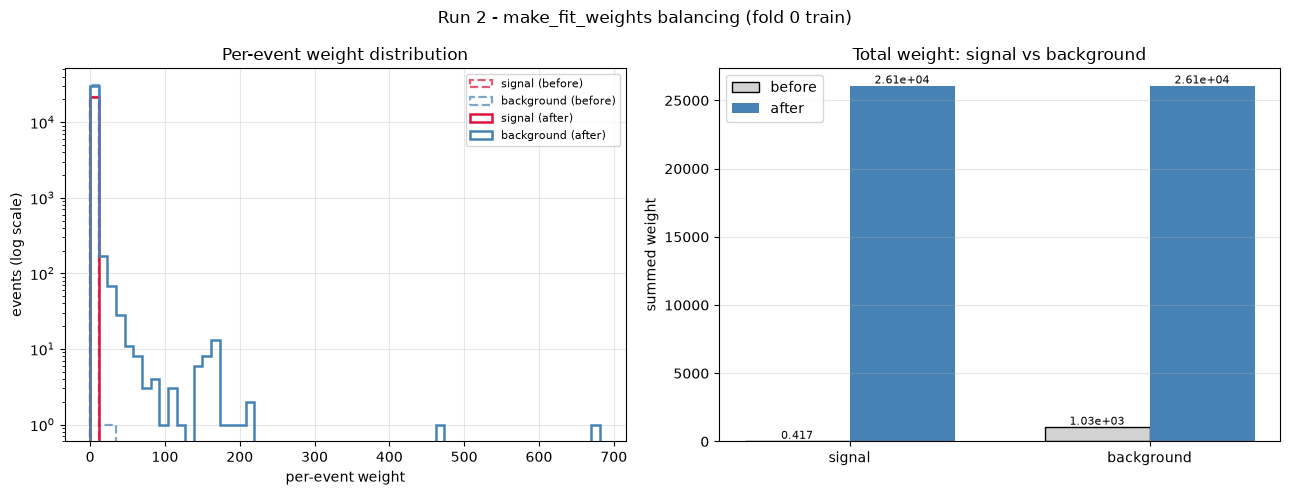

N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:
label
0      348.997
1   17,022.767
Name: n_eff, dtype: float64

N_eff (eval sample, signed, FULL fold-0 test partition) by label:
label
0     110.957
1   4,664.959
Name: n_eff, dtype: float64

Dropped 4712 negative-w_phys training rows in this preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).


In [11]:
# ---- Weight-balance diagnostics (Run 2, representative fold 0) --------------
# Replaces the old 80/10/10 make_3way_split + persisted splits/{train,val,test}.root -
# there is no single train/val/test split anymore, only the 5-fold rotation
# used below (run_kfold_xgb). This cell previews fold 0 (test=fold 0, val=fold
# 1, train=folds 2/3/4) purely to (a) show what make_fit_weights does to the
# training weights and (b) sanity-check N_eff per process/label is not
# starved in any fold - it does NOT produce a model used anywhere downstream.
PLOTS_DIR_R2 = BASE_DIR_R2 / "plots"
PLOTS_DIR_R2.mkdir(parents=True, exist_ok=True)

target_yields_r2 = compute_process_yield_targets(data_r2)
fd0_r2 = prepare_fold_data(data_r2, features_r2, target_yields_r2, cell_cols=(), n_folds=N_FOLDS, k=0)

w_before_r2 = fd0_r2["train_df"]["w_phys"].to_numpy()   # post neg-drop + yield-rescale, PRE class-balance
w_after_r2 = fd0_r2["w_train_fit"]                        # POST make_fit_weights balance + normalize
y_preview_r2 = fd0_r2["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_r2, w_before_r2, w_after_r2,
    title="Run 2 - make_fit_weights balancing (fold 0 train)",
    save_path=PLOTS_DIR_R2 / "Run2WeightBalance.png",
)

print("N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:")
print(n_eff_table(fd0_r2["train_df"], ["label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by label:")
print(n_eff_table(fd0_r2["test_df"], ["label"]))
print(f"\nDropped {fd0_r2['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


[Run2 baseline (fold-0 preview)] best_iteration=132 | weighted AUC: train=0.9940 val=0.9709

Top 30 features by total gain (Run 2, fold-0 preview):
               total_gain  gain_frac  weight
HT_tau         58,071.445      0.206 199.000
SumPt_t1t2     49,556.391      0.176 231.000
tau1_pt        33,333.230      0.118 139.000
met_met        29,452.982      0.105 316.000
m_l1l2         15,439.157      0.055 400.000
dR_t1t2        12,297.435      0.044 242.000
HT              8,303.459      0.030 120.000
m_t1t2          6,743.636      0.024 268.000
tau2_pt         5,879.840      0.021 199.000
dR_l1t          2,638.174      0.009 131.000
m_l2t1          2,596.538      0.009 192.000
m_l1t           2,539.298      0.009 134.000
l2_pdg          2,532.936      0.009  43.000
HT_lepMET       2,026.181      0.007 122.000
l1_z0sintheta   1,932.683      0.007 189.000
tau1_eta        1,744.000      0.006 146.000
l2_z0sintheta   1,742.331      0.006 161.000
m_ttl           1,731.910      0.006 107.0

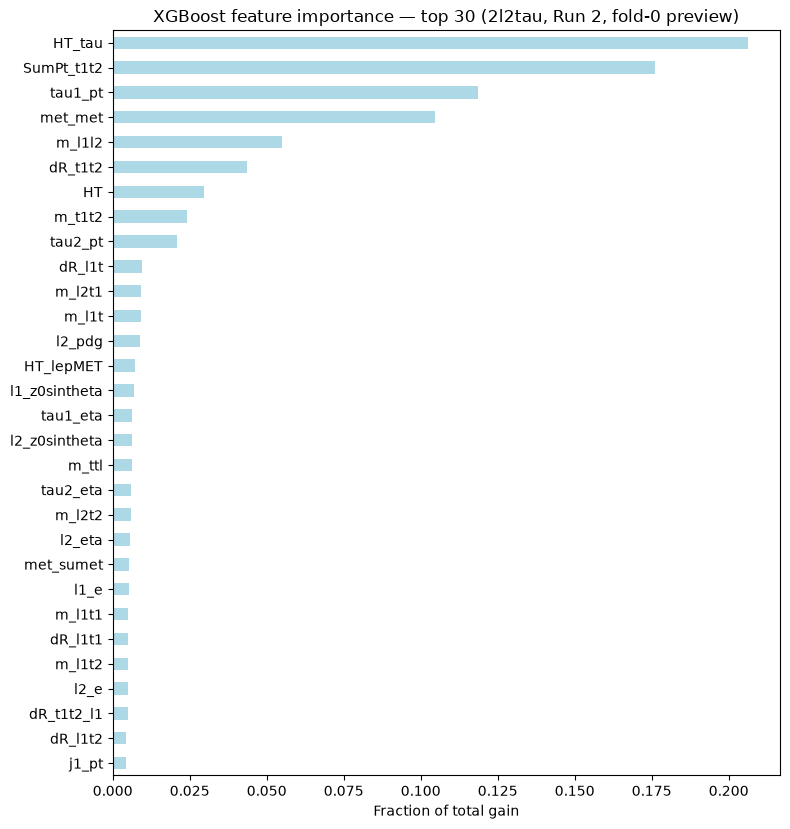

In [12]:
# ---- Baseline XGBoost + feature importance (Run 2, fold-0 preview) ---------
# Only used to RANK features for the correlation-pruning stage below - the
# actual 5 fold models (frozen hyperparameters) are trained later by run_kfold_xgb.
model_r2, auc_train_r2, auc_val_r2 = train_xgb_fold(
    fd0_r2["train_df"][features_r2], fd0_r2["train_df"]["label"], fd0_r2["w_train_fit"],
    fd0_r2["val_df"][features_r2], fd0_r2["val_df"]["label"], np.abs(fd0_r2["val_df"]["w_phys"].to_numpy()),
    label="Run2 baseline (fold-0 preview)",
)

imp_r2 = get_importance(model_r2, features_r2)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Run 2, fold-0 preview):")
print(imp_r2[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_r2['total_gain'] == 0).sum()} / {len(features_r2)}")

plot_importance_bar(imp_r2, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (2l2tau, Run 2, fold-0 preview)",
                     save_path=PLOTS_DIR_R2 / "Run2BeforeCorrelation.png")


Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2CorrelationTop30.png


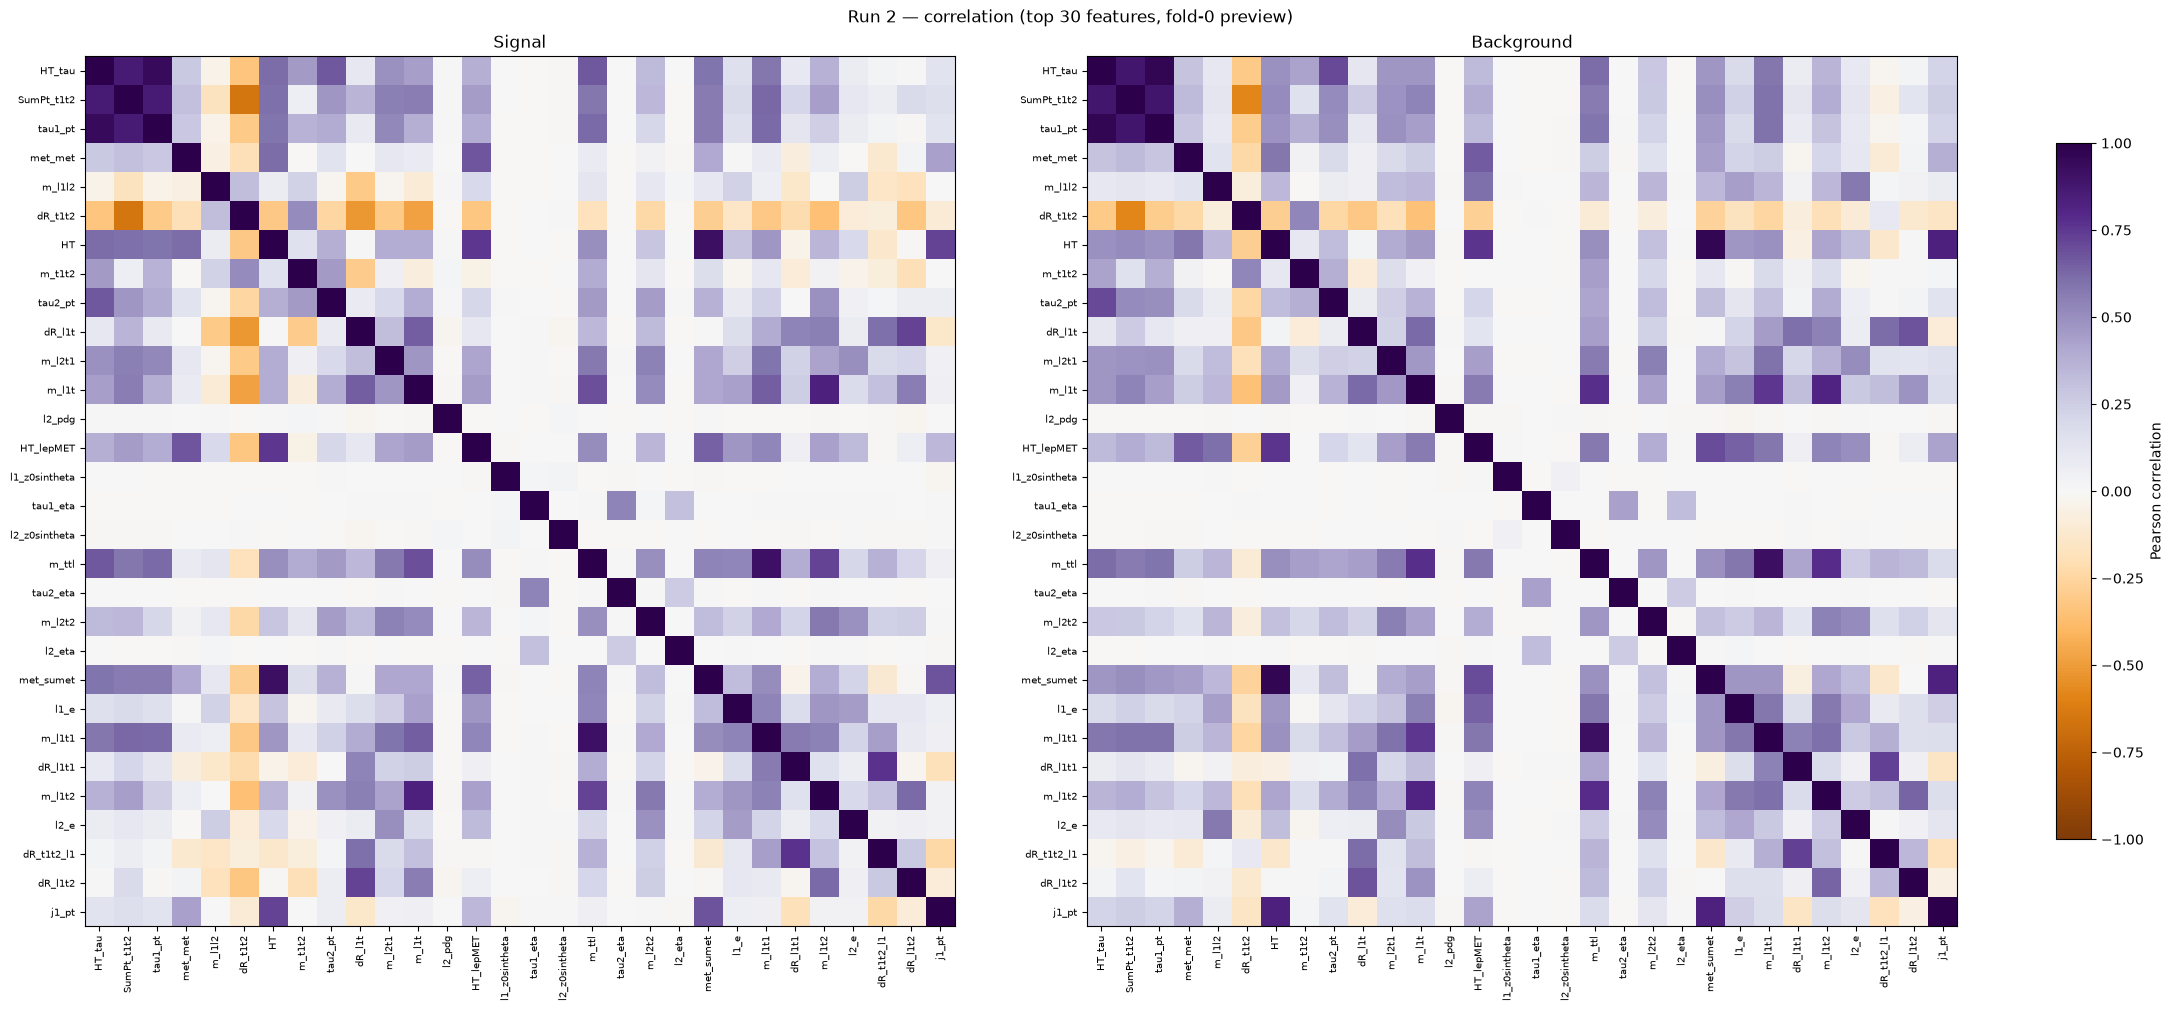

Pairs with |corr| > 0.50 (signal):
HT_tau      tau1_pt      0.944
HT          met_sumet    0.920
m_ttl       m_l1t1       0.907
HT_tau      SumPt_t1t2   0.861
SumPt_t1t2  tau1_pt      0.860
m_l1t       m_l1t2       0.836
dR_l1t1     dR_t1t2_l1   0.772
HT          HT_lepMET    0.756
            j1_pt        0.723
dR_l1t      dR_l1t2      0.720
m_ttl       m_l1t2       0.720
m_l1t       m_ttl        0.692
met_sumet   j1_pt        0.681
met_met     HT_lepMET    0.678
HT_tau      tau2_pt      0.672
            m_ttl        0.665
SumPt_t1t2  dR_t1t2      0.656
m_l1t       m_l1t1       0.652
dR_l1t      m_l1t        0.649
HT_lepMET   met_sumet    0.646
SumPt_t1t2  m_l1t1       0.627
tau1_pt     m_ttl        0.624
m_l1t2      dR_l1t2      0.623
tau1_pt     m_l1t1       0.618
met_met     HT           0.613
HT_tau      HT           0.612
dR_l1t      dR_t1t2_l1   0.606
SumPt_t1t2  HT           0.602
tau1_pt     HT           0.593
m_l2t1      m_l1t1       0.592
HT_tau      met_sumet    0.587
SumP

In [13]:
# ---- Correlation of the top features (Run 2, fold-0 preview train set) -----
top_feats_r2 = imp_r2.index[:TOP_N_IMPORTANCE].tolist()
corrs_r2 = grouped_correlations(fd0_r2["train_df"], top_feats_r2, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_r2[1], corrs_r2[0]], ["Signal", "Background"], top_feats_r2,
    suptitle=f"Run 2 — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_r2[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_r2[0]).to_string())


In [14]:
# ---- Correlation-based pruning to a decorrelated top-20 (Run 2) ------------
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.
corr_max_r2 = corrs_r2[1].abs().combine(corrs_r2[0].abs(), np.maximum)
PRUNED_FEATURES_R2, dropped_r2 = prune_correlated(top_feats_r2, corr_max_r2, CORR_THRESH, N_KEEP)


Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. met_met
   3. m_l1l2
   4. dR_t1t2
   5. HT
   6. m_t1t2
   7. tau2_pt
   8. dR_l1t
   9. m_l2t1
  10. m_l1t
  11. l2_pdg
  12. l1_z0sintheta
  13. tau1_eta
  14. l2_z0sintheta
  15. tau2_eta
  16. m_l2t2
  17. l2_eta
  18. l1_e
  19. dR_l1t1
  20. l2_e

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.879)
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.966)
  HT_lepMET       -> redundant with HT              (|corr| = 0.765)
  m_ttl           -> redundant with m_l1t           (|corr| = 0.779)
  met_sumet       -> redundant with HT              (|corr| = 0.968)
  m_l1t1          -> redundant with m_l1t           (|corr| = 0.751)
  m_l1t2          -> redundant with m_l1t           (|corr| = 0.836)


[Run2 pruned (fold-0 preview)] best_iteration=148 | weighted AUC: train=0.9928 val=0.9675

Comparison (fold-0 preview) — full 79 features: val AUC = 0.9709 | pruned 20 features: val AUC = 0.9675
Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2AfterCorrelation.png


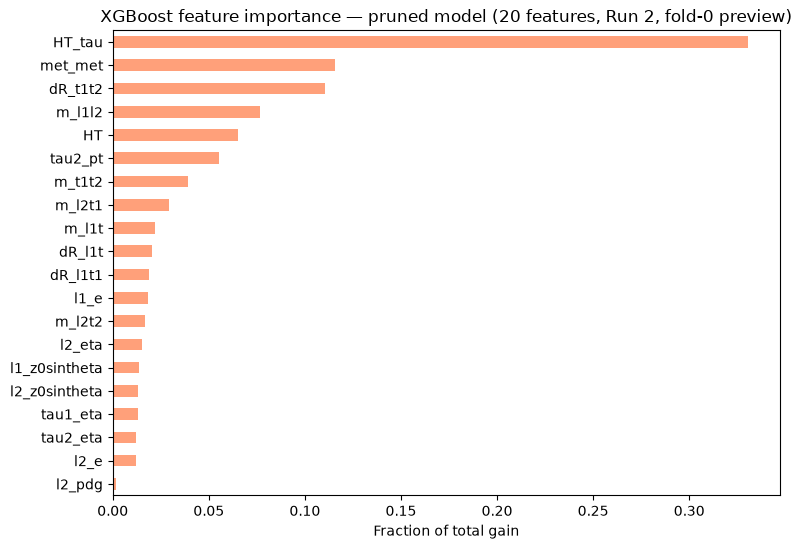

Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2CorrelationPruned.png


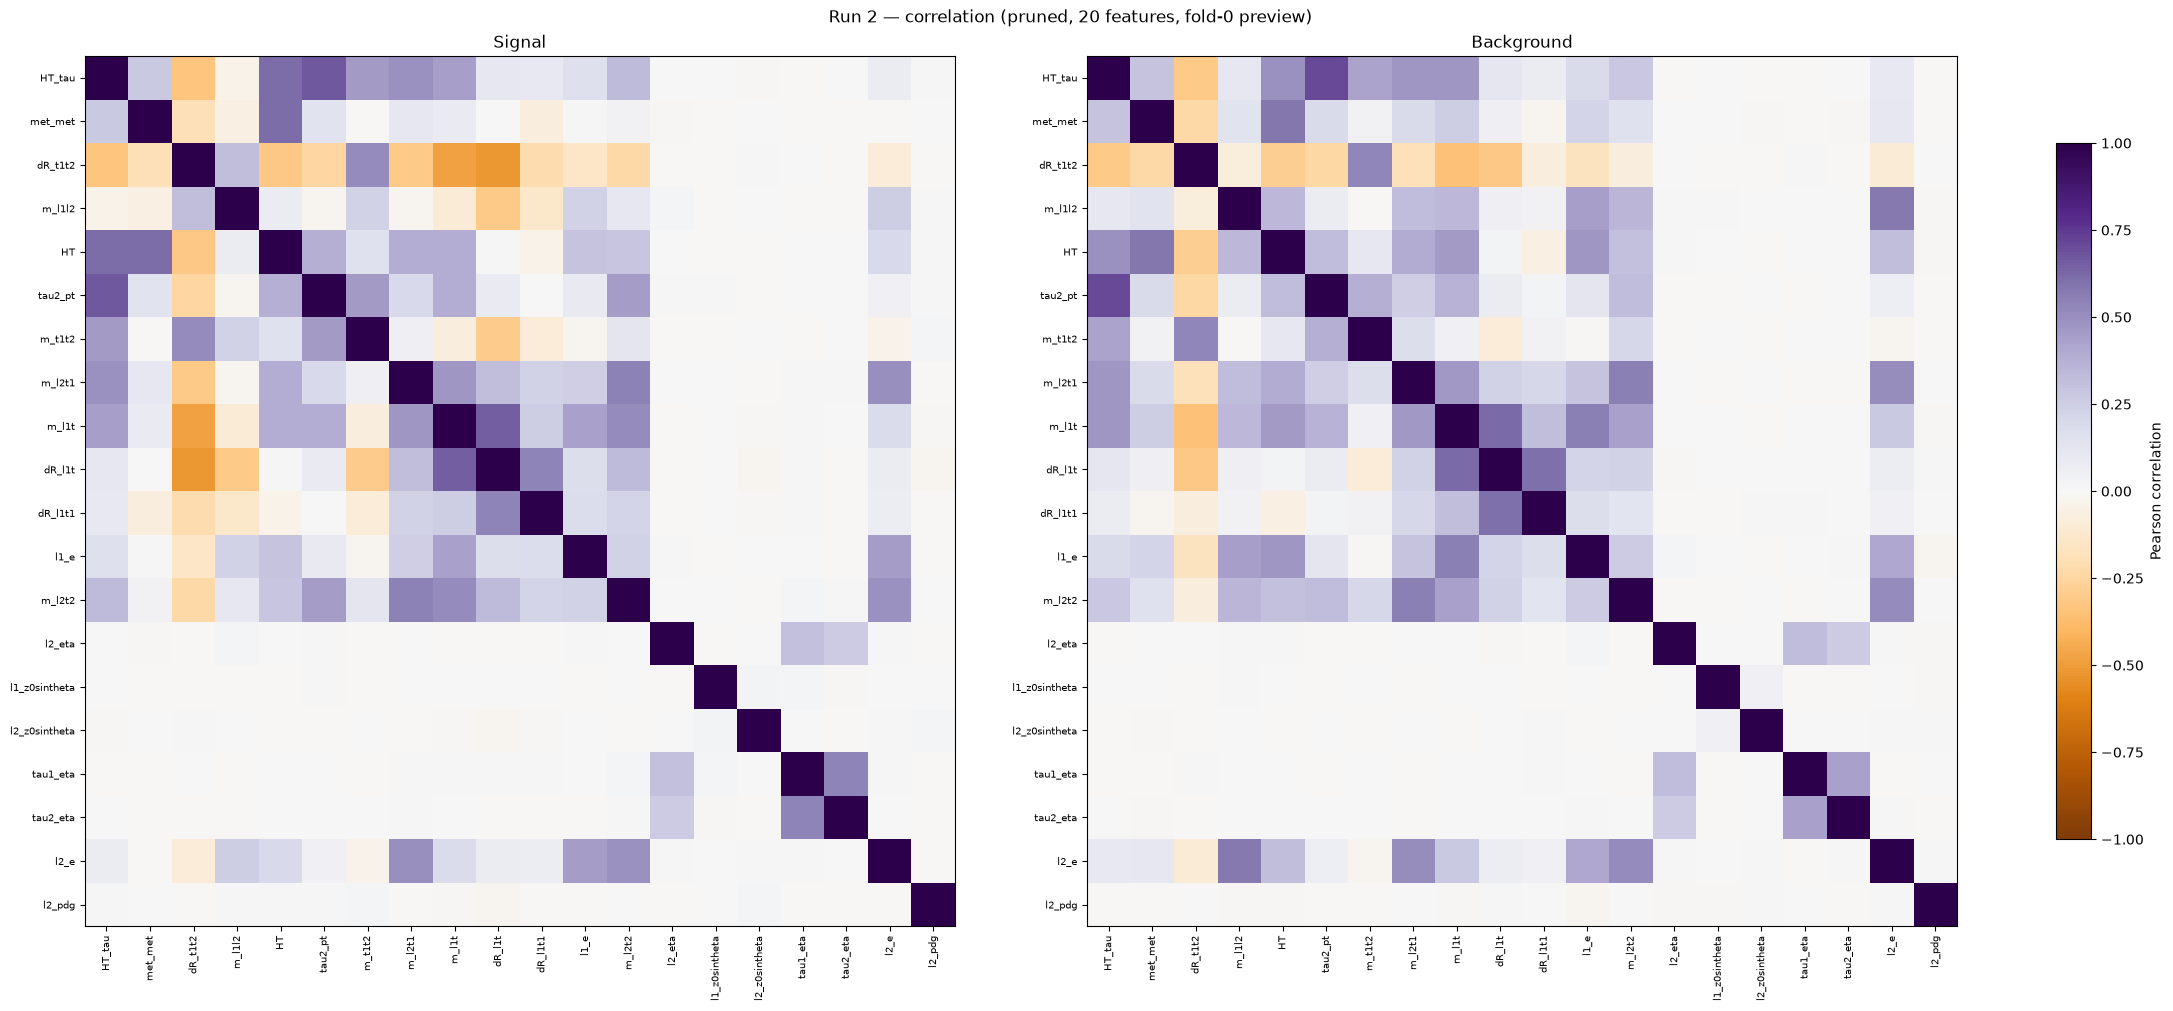

In [15]:
# ---- Retrain on the pruned feature set + re-check correlation (Run 2, fold-0 preview) ------
model_r2_pruned, auc_train_r2_pruned, auc_val_r2_pruned = train_xgb_fold(
    fd0_r2["train_df"][PRUNED_FEATURES_R2], fd0_r2["train_df"]["label"], fd0_r2["w_train_fit"],
    fd0_r2["val_df"][PRUNED_FEATURES_R2], fd0_r2["val_df"]["label"], np.abs(fd0_r2["val_df"]["w_phys"].to_numpy()),
    label="Run2 pruned (fold-0 preview)",
)

imp_r2_pruned = get_importance(model_r2_pruned, PRUNED_FEATURES_R2)
print(f"\nComparison (fold-0 preview) — full {len(features_r2)} features: val AUC = {auc_val_r2:.4f} | "
      f"pruned {len(PRUNED_FEATURES_R2)} features: val AUC = {auc_val_r2_pruned:.4f}")

plot_importance_bar(
    imp_r2_pruned, top_n=len(PRUNED_FEATURES_R2),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_R2)} features, Run 2, fold-0 preview)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R2 / "Run2AfterCorrelation.png",
)

pruned_top_feats_r2 = imp_r2_pruned.index.tolist()
pruned_corrs_r2 = grouped_correlations(fd0_r2["train_df"], pruned_top_feats_r2, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_r2[1], pruned_corrs_r2[0]], ["Signal", "Background"], pruned_top_feats_r2,
    suptitle=f"Run 2 — correlation (pruned, {len(pruned_top_feats_r2)} features, fold-0 preview)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationPruned.png",
)


In [16]:
# ---- Optuna hyperparameter search (Run 2) -----------------------------------
# Tuned on the decorrelated pruned feature set, using the SAME N_FOLDS
# eventNumber-folds as the final OOF rotation below (see run_optuna_search's
# docstring for the accepted-leak caveat).
OPTUNA_FEATURES_R2 = PRUNED_FEATURES_R2.copy()

study_r2 = run_optuna_search(
    data_r2, OPTUNA_FEATURES_R2, target_yields_r2, cell_cols=(),
    n_trials=N_OPTUNA_TRIALS, n_folds=N_FOLDS,
    base_n_estimators=800, study_name="xgb_2l2tau_run2",
)


/tmp/ipykernel_161419/4148764037.py:115: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[xgb_2l2tau_run2] completed trials: 15
[xgb_2l2tau_run2] best mean CV significance Z (5 eventNumber-folds): 0.04508
[xgb_2l2tau_run2] mean best iteration: 284
[xgb_2l2tau_run2] fold Z's: [0.04837695306520439, 0.04561368602916075, 0.049647555963469175, 0.04435007374176349, 0.03739004890970814]
[xgb_2l2tau_run2] best parameters:
    learning_rate: 0.05166498110776256
    max_depth: 7
    min_child_weight: 7.1918527420611005
    subsample: 0.744336436318052
    colsample_bytree: 0.7212965529486296
    gamma: 0.5870261902563104
    reg_alpha: 0.00027755270806633747
    reg_lambda: 34.692292750192806


[Run2 fold0] best_iteration=241 | weighted AUC: train=0.9885 val=0.9679
[Run2] fold 0: test_fold=0 val_fold=1 | train n=52101 (dropped 4712 neg) | test weighted AUC = 0.9693 | test significance Z = 0.047
[Run2 fold1] best_iteration=282 | weighted AUC: train=0.9898 val=0.9675
[Run2] fold 1: test_fold=1 val_fold=2 | train n=52224 (dropped 4647 neg) | test weighted AUC = 0.9702 | test significance Z = 0.045
[Run2 fold2] best_iteration=283 | weighted AUC: train=0.9896 val=0.9600
[Run2] fold 2: test_fold=2 val_fold=3 | train n=52221 (dropped 4697 neg) | test weighted AUC = 0.9703 | test significance Z = 0.050
[Run2 fold3] best_iteration=168 | weighted AUC: train=0.9859 val=0.9661
[Run2] fold 3: test_fold=3 val_fold=4 | train n=52571 (dropped 4745 neg) | test weighted AUC = 0.9556 | test significance Z = 0.044
[Run2 fold4] best_iteration=175 | weighted AUC: train=0.9863 val=0.9667
[Run2] fold 4: test_fold=4 val_fold=0 | train n=52231 (dropped 4755 neg) | test weighted AUC = 0.9670 | test sig

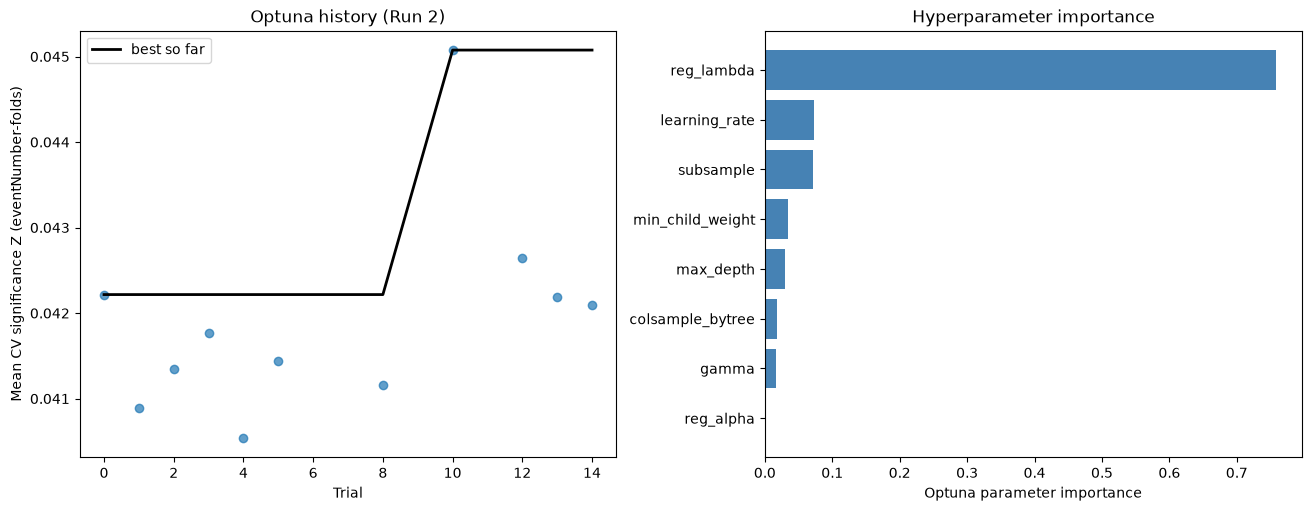

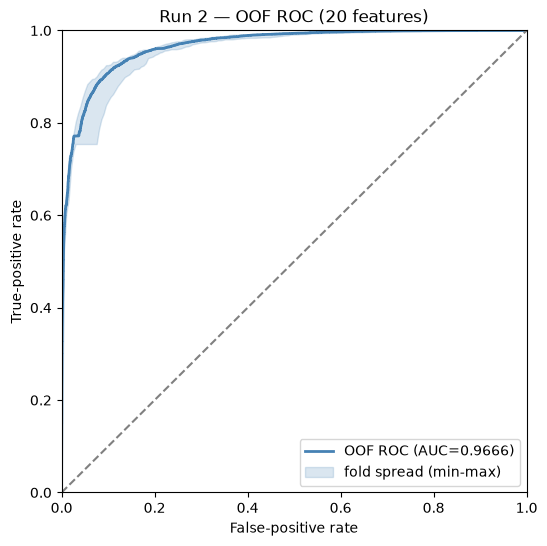

Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2AfterOptuna.png


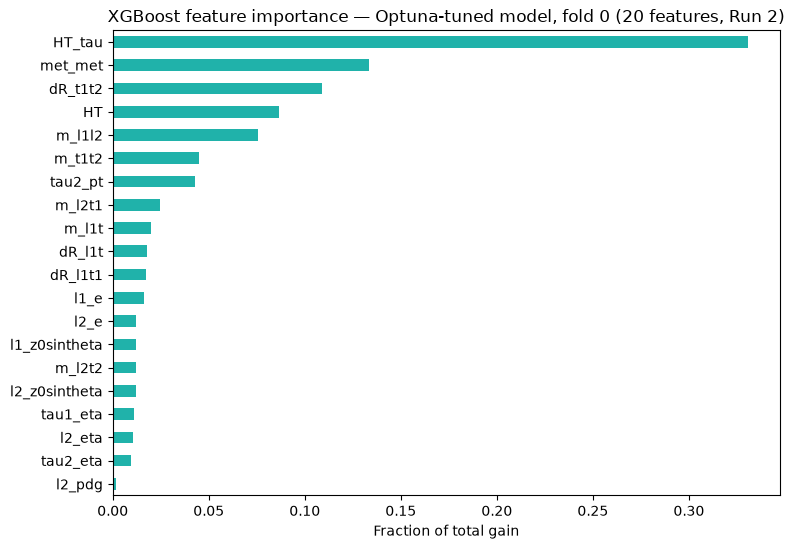

In [17]:
# ---- Final 5-fold OOF models + diagnostics (Run 2) --------------------------
best_params_r2 = params_from_study(study_r2)
oof_df_r2, models_r2 = run_kfold_xgb(
    data_r2, OPTUNA_FEATURES_R2, best_params_r2, target_yields_r2,
    cell_cols=(), n_folds=N_FOLDS, label="Run2",
)

plot_optuna_diagnostics(study_r2, title_suffix="(Run 2)")
oof_auc_r2 = plot_oof_roc(oof_df_r2, title=f"Run 2 — OOF ROC ({len(OPTUNA_FEATURES_R2)} features)")

final_imp_r2 = get_importance(models_r2[0], OPTUNA_FEATURES_R2)
plot_importance_bar(
    final_imp_r2, top_n=len(OPTUNA_FEATURES_R2),
    title=f"XGBoost feature importance — Optuna-tuned model, fold 0 ({len(OPTUNA_FEATURES_R2)} features, Run 2)",
    color="lightseagreen",
    save_path=PLOTS_DIR_R2 / "Run2AfterOptuna.png",
)


In [18]:
# ---- Persist the Run-2 fold models + feature list + hyperparams + OOF -------
# Replaces the old single final_model_run2.json / splits/{train,val,test}.root.
save_track_artifacts(models_r2, OPTUNA_FEATURES_R2, best_params_r2, oof_df_r2, BASE_DIR_R2, "run2")


Saved 5 fold models + feature list + hyperparams + OOF scores -> PPSSP_2026/2l2tau/run2/ (track=run2)


### Held-Out Test Evaluation (Run 2)

`X_test_r2`/`y_test_r2`/`w_test_r2` have not participated in anything above -
not correlation pruning, not Optuna tuning, not early stopping. This is the
one place they are read, scoring the final Optuna-tuned model exactly once.


In [19]:
# ---- "Held-Out Test" under the k-fold refactor -----------------------------
# There is no separate held-out test set anymore - the OOF score array
# (oof_df_r2, computed by run_kfold_xgb above) already covers 100% of Run 2's
# events, each scored by a fold model that never trained on it. This IS the
# held-out-test-equivalent evaluation; oof_auc_r2 is its weighted AUC.
print(f"[Run2] OOF weighted AUC (every event scored by a model that never saw it) = {oof_auc_r2:.5f}")


[Run2] OOF weighted AUC (every event scored by a model that never saw it) = 0.96664


## 4. Run 3 — Solo Track

Identical procedure to Section 3, independently on **Run 3 only** (separate
feature-discovery pass too, in case branches differ slightly between
campaigns).


In [20]:
# ---- Load & clean (Run 3) ---------------------------------------------------
features_r3 = discover_common_features([BASE_DIR_R3])
data_r3 = load_run_data(BASE_DIR_R3, run_label=3, features=features_r3)
data_r3, features_r3 = clean_data(data_r3, features_r3)
data_r3 = assign_folds(data_r3, n_folds=N_FOLDS)
print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data_r3["fold"].value_counts().sort_index())
data_r3.head()


85 candidate features (common to all 10 processes x 1 run(s) = 10 files, leakage-free)
Run 3 signal_ggF  :    96909 events after preselection
Run 3 signal_VBF  :     3439 events after preselection


Run 3 Diboson     :    82336 events after preselection
Run 3 Zjets       :    12919 events after preselection
Run 3 Wjets       :       51 events after preselection
Run 3 ttbar       :     3276 events after preselection
Run 3 tops        :    11065 events after preselection
Run 3 SingleH     :     3240 events after preselection
Run 3 Vgamma      :     2366 events after preselection
Run 3 VVV         :    13941 events after preselection
Dropped 6 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'n_lep', 'tau1_base_id', 'tau2_base_id']

79 final features
Total: 229542 events | signal = 100348 | background = 129194
Yield (w_phys): signal = 0.49 | background = 2126.09

Fold sizes (fold = eventNumber % 5):
fold
0    46346
1    46001
2    45539
3    46090
4    45566
Name: count, dtype: int64


,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_phi,tau2_pt,weight,weights,eventNumber,w_phys,label,process,run,fold
0,"369,540.469","341,893.219","199,470.562","80,148.562","107,795.812","62,274.102","109,618.320","21,708.609","32,057.354",1.326,...,-2.642,"24,704.539",0.001,0.028,48927,0.000,1,signal_ggF,3,2
1,"185,936.312","146,177.109",0.000,"102,864.719","142,623.922","43,312.387","61,778.746","61,778.746","10,123.177",NaN,...,1.548,"21,155.355",0.001,-0.039,114047,-0.000,1,signal_ggF,3,2
2,"193,755.312","121,575.641",0.000,"33,224.691","105,404.359","88,350.953","22,594.273","22,594.273","20,340.336",NaN,...,0.342,"36,801.430",0.001,0.021,294599,0.000,1,signal_ggF,3,4
3,"487,495.656","472,277.188","318,791.438","106,009.797","121,228.250","47,475.973","159,514.734","102,968.805","41,378.273",2.810,...,-2.835,"21,792.055",0.001,0.041,296864,0.000,1,signal_ggF,3,4
4,"182,144.703","142,537.812","26,865.521","58,703.934","98,310.812","56,968.367","16,995.748","16,995.748","40,460.621",NaN,...,1.209,"21,709.438",0.001,0.040,183704,0.000,1,signal_ggF,3,4


In [21]:
# ---- Yields / S over B (Run 3) ----------------------------------------------
yields_r3 = compute_yields(data_r3, BASE_DIR_R3)


   process   N_mc  yield_skim  N_presel     yield  pct_of_bkg  frac_neg
     Zjets  73738   8,229.803     12919 1,658.799      78.021     0.155
    Vgamma   4583     351.179      2366   233.058      10.962     0.081
     ttbar  10094     312.479      3276    99.227       4.667     0.003
   Diboson 453418     390.878     82336    81.396       3.828     0.091
   SingleH  20918      96.632      3240    56.860       2.674     0.005
      tops 133506      49.968     11065     9.522       0.448     0.287
       VVV  43855       4.241     13941     2.340       0.110     0.010
     Wjets     96      -1.639        51   -15.108      -0.711     0.157
signal_ggF 137429       0.684     96909     0.472         NaN     0.061
signal_VBF   4861       0.028      3439     0.020         NaN     0.002

Total background (presel): 2,126.095
Total signal     (presel): 0.491
S/B       = 2.31e-04
S/sqrt(B) = 0.0107


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3WeightBalance.png


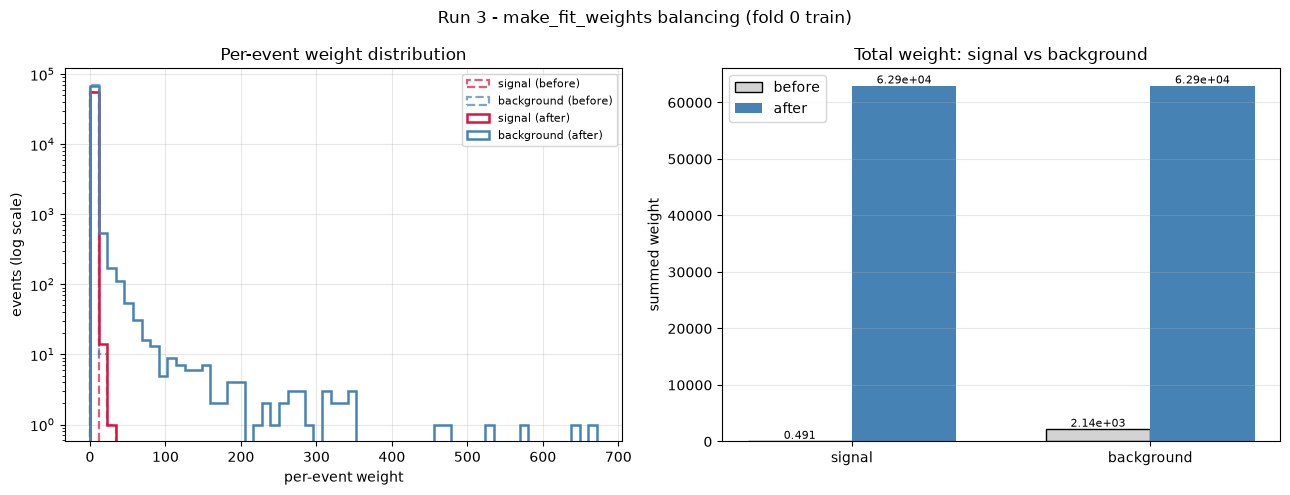

N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:
label
0      665.977
1   32,027.803
Name: n_eff, dtype: float64

N_eff (eval sample, signed, FULL fold-0 test partition) by label:
label
0      69.673
1   8,675.249
Name: n_eff, dtype: float64

Dropped 11394 negative-w_phys training rows in this preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).


In [22]:
# ---- Weight-balance diagnostics (Run 3, representative fold 0) --------------
PLOTS_DIR_R3 = BASE_DIR_R3 / "plots"
PLOTS_DIR_R3.mkdir(parents=True, exist_ok=True)

target_yields_r3 = compute_process_yield_targets(data_r3)
fd0_r3 = prepare_fold_data(data_r3, features_r3, target_yields_r3, cell_cols=(), n_folds=N_FOLDS, k=0)

w_before_r3 = fd0_r3["train_df"]["w_phys"].to_numpy()
w_after_r3 = fd0_r3["w_train_fit"]
y_preview_r3 = fd0_r3["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_r3, w_before_r3, w_after_r3,
    title="Run 3 - make_fit_weights balancing (fold 0 train)",
    save_path=PLOTS_DIR_R3 / "Run3WeightBalance.png",
)

print("N_eff (training sample, positive-only, post yield-rescale) by label - fold 0:")
print(n_eff_table(fd0_r3["train_df"], ["label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by label:")
print(n_eff_table(fd0_r3["test_df"], ["label"]))
print(f"\nDropped {fd0_r3['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


[Run3 baseline (fold-0 preview)] best_iteration=210 | weighted AUC: train=0.9953 val=0.9705

Top 30 features by total gain (Run 3, fold-0 preview):
               total_gain  gain_frac  weight
HT_tau        237,339.109      0.347 290.000
tau1_pt        92,162.617      0.135 232.000
SumPt_t1t2     54,244.500      0.079 309.000
met_met        41,813.590      0.061 451.000
m_l1l2         28,813.486      0.042 569.000
HT             25,278.303      0.037 188.000
dR_t1t2        18,668.027      0.027 356.000
m_t1t2         12,969.375      0.019 364.000
tau2_pt        11,637.153      0.017 311.000
l2_pdg         10,492.287      0.015  79.000
HT_lepMET       6,976.187      0.010 225.000
met_sumet       6,737.027      0.010 251.000
m_l2t1          6,374.220      0.009 268.000
dR_l1t          6,030.758      0.009 213.000
m_l1t           5,924.369      0.009 204.000
l2_z0sintheta   5,811.877      0.009 311.000
l1_z0sintheta   4,182.756      0.006 270.000
dR_t1t2_l1      3,986.899      0.006 231.0

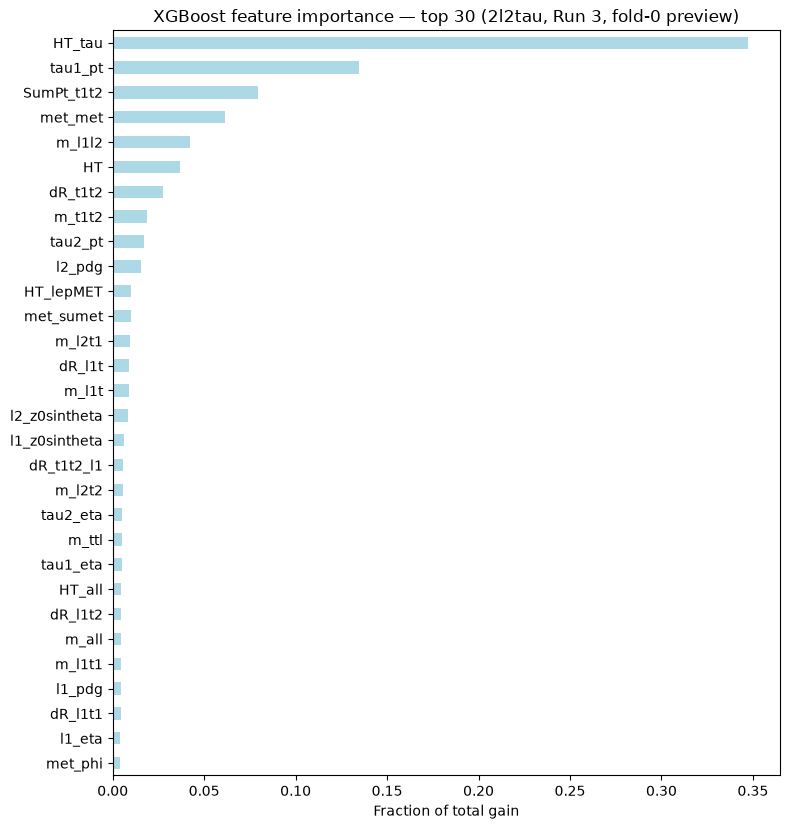

In [23]:
# ---- Baseline XGBoost + feature importance (Run 3, fold-0 preview) ---------
model_r3, auc_train_r3, auc_val_r3 = train_xgb_fold(
    fd0_r3["train_df"][features_r3], fd0_r3["train_df"]["label"], fd0_r3["w_train_fit"],
    fd0_r3["val_df"][features_r3], fd0_r3["val_df"]["label"], np.abs(fd0_r3["val_df"]["w_phys"].to_numpy()),
    label="Run3 baseline (fold-0 preview)",
)

imp_r3 = get_importance(model_r3, features_r3)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Run 3, fold-0 preview):")
print(imp_r3[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_r3['total_gain'] == 0).sum()} / {len(features_r3)}")

plot_importance_bar(imp_r3, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (2l2tau, Run 3, fold-0 preview)",
                     save_path=PLOTS_DIR_R3 / "Run3BeforeCorrelation.png")


Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3CorrelationTop30.png


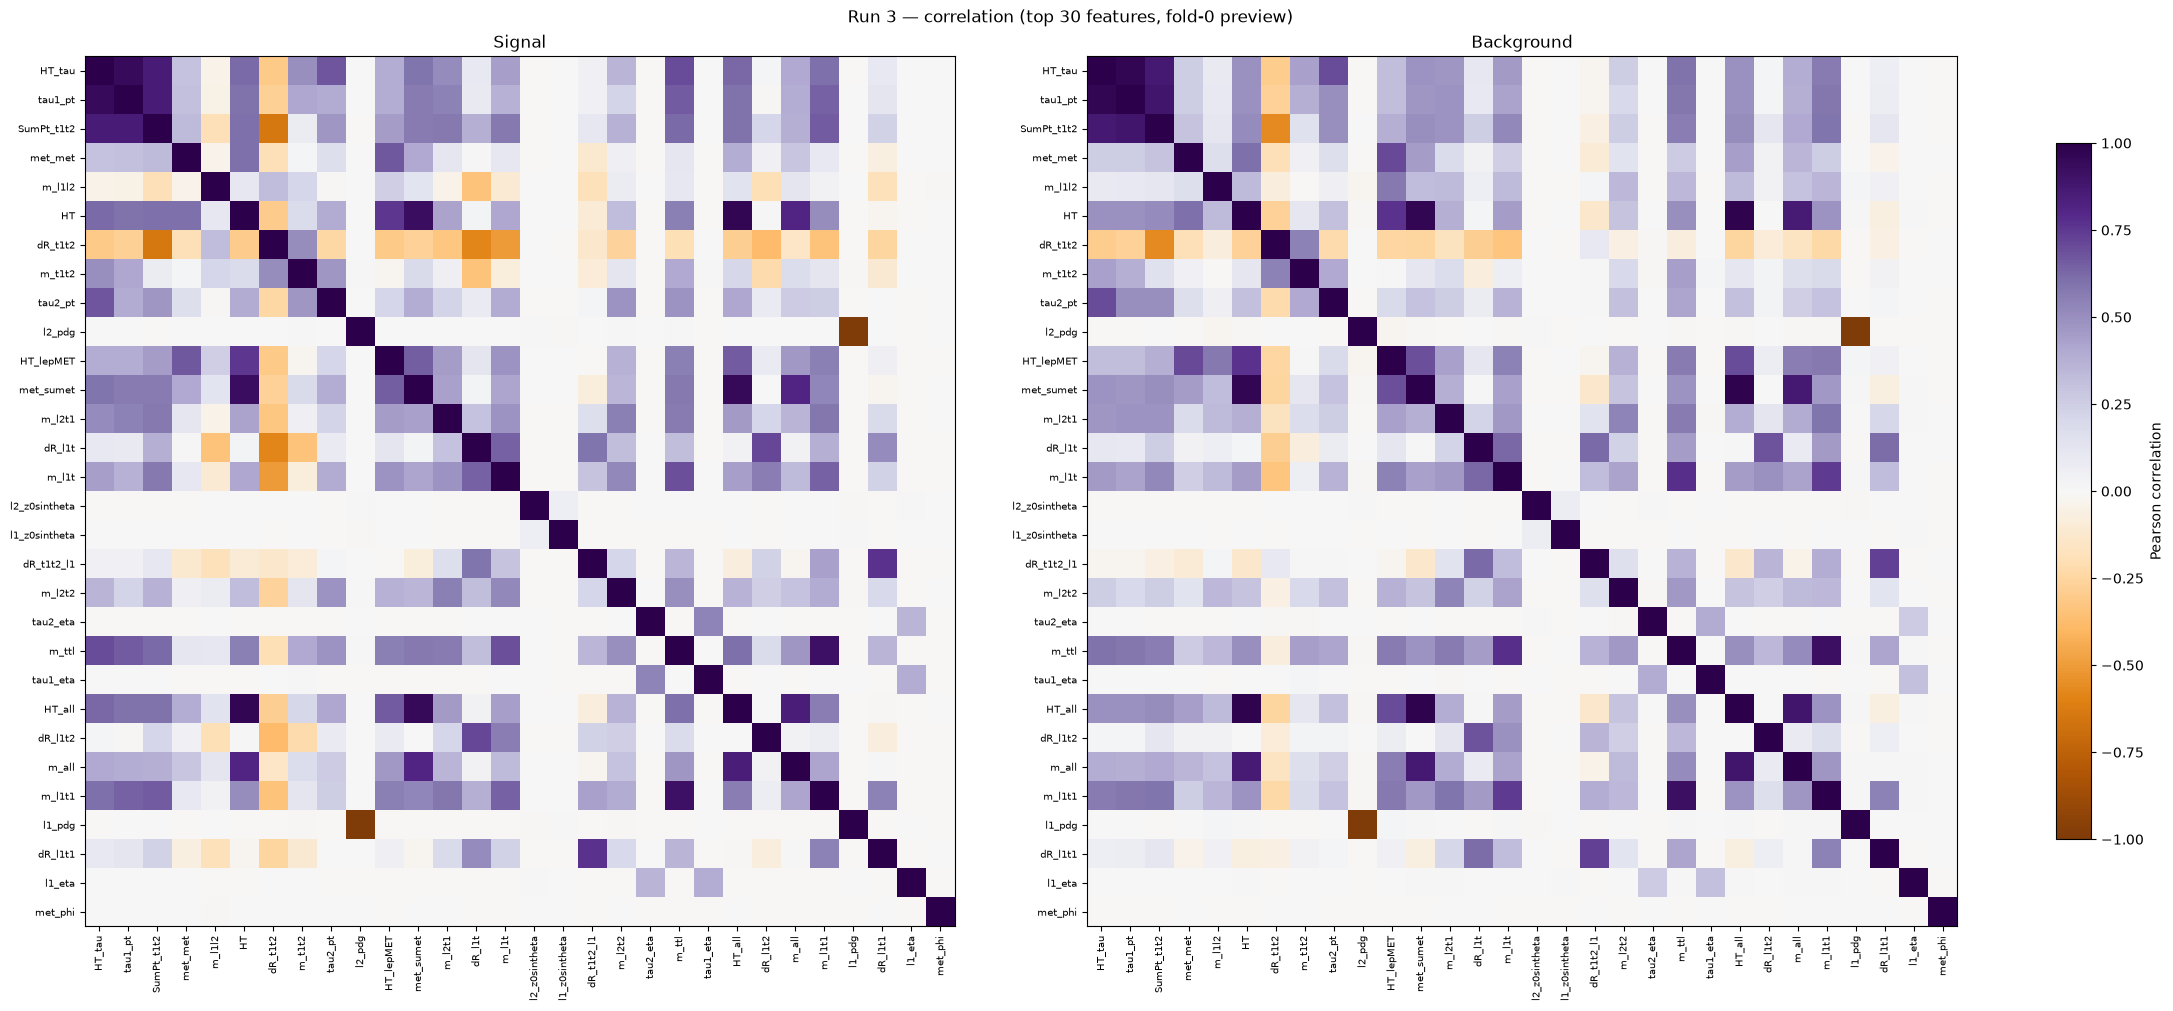

Pairs with |corr| > 0.50 (signal):
l2_pdg      l1_pdg       0.993
HT          HT_all       0.966
met_sumet   HT_all       0.949
HT_tau      tau1_pt      0.944
HT          met_sumet    0.927
m_ttl       m_l1t1       0.908
HT_tau      SumPt_t1t2   0.858
tau1_pt     SumPt_t1t2   0.857
HT_all      m_all        0.845
met_sumet   m_all        0.808
HT          m_all        0.805
dR_t1t2_l1  dR_l1t1      0.769
HT          HT_lepMET    0.756
dR_l1t      dR_l1t2      0.718
HT_tau      m_ttl        0.701
m_l1t       m_ttl        0.688
HT_tau      tau2_pt      0.672
met_met     HT_lepMET    0.668
HT_lepMET   HT_all       0.663
tau1_pt     m_ttl        0.658
SumPt_t1t2  m_l1t1       0.658
HT_lepMET   met_sumet    0.650
dR_l1t      m_l1t        0.645
tau1_pt     m_l1t1       0.645
m_l1t       m_l1t1       0.645
SumPt_t1t2  dR_t1t2      0.642
HT_tau      HT_all       0.628
            HT           0.624
SumPt_t1t2  m_ttl        0.623
HT_tau      m_l1t1       0.609
met_met     HT           0.609
SumP

In [24]:
# ---- Correlation of the top features (Run 3, fold-0 preview train set) -----
top_feats_r3 = imp_r3.index[:TOP_N_IMPORTANCE].tolist()
corrs_r3 = grouped_correlations(fd0_r3["train_df"], top_feats_r3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_r3[1], corrs_r3[0]], ["Signal", "Background"], top_feats_r3,
    suptitle=f"Run 3 — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_r3[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_r3[0]).to_string())


In [25]:
# ---- Correlation-based pruning to a decorrelated top-20 (Run 3) ------------
corr_max_r3 = corrs_r3[1].abs().combine(corrs_r3[0].abs(), np.maximum)
PRUNED_FEATURES_R3, dropped_r3 = prune_correlated(top_feats_r3, corr_max_r3, CORR_THRESH, N_KEEP)


Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. met_met
   3. m_l1l2
   4. HT
   5. dR_t1t2
   6. m_t1t2
   7. tau2_pt
   8. l2_pdg
   9. m_l2t1
  10. dR_l1t
  11. m_l1t
  12. l2_z0sintheta
  13. l1_z0sintheta
  14. dR_t1t2_l1
  15. m_l2t2
  16. tau2_eta
  17. tau1_eta
  18. dR_l1t2
  19. m_l1t1
  20. l1_eta

Dropped 9 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.966)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.872)
  HT_lepMET       -> redundant with HT              (|corr| = 0.771)
  met_sumet       -> redundant with HT              (|corr| = 0.964)
  m_ttl           -> redundant with m_l1t           (|corr| = 0.780)
  HT_all          -> redundant with HT              (|corr| = 0.981)
  m_all           -> redundant with HT              (|corr| = 0.864)
  l1_pdg          -> redundant with l2_pdg          (|corr| = 0.997)
  dR_l1t1         -> redundant wi

[Run3 pruned (fold-0 preview)] best_iteration=175 | weighted AUC: train=0.9919 val=0.9640

Comparison (fold-0 preview) — full 79 features: val AUC = 0.9705 | pruned 20 features: val AUC = 0.9640
Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3AfterCorrelation.png


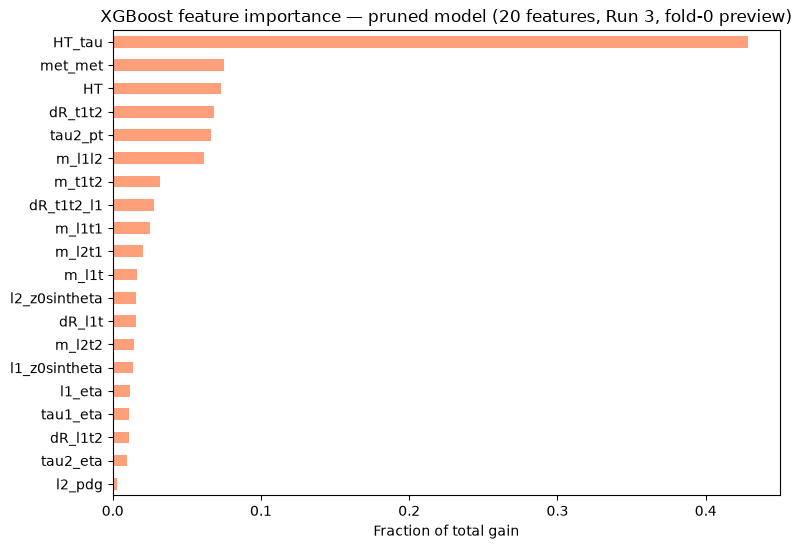

Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3CorrelationPruned.png


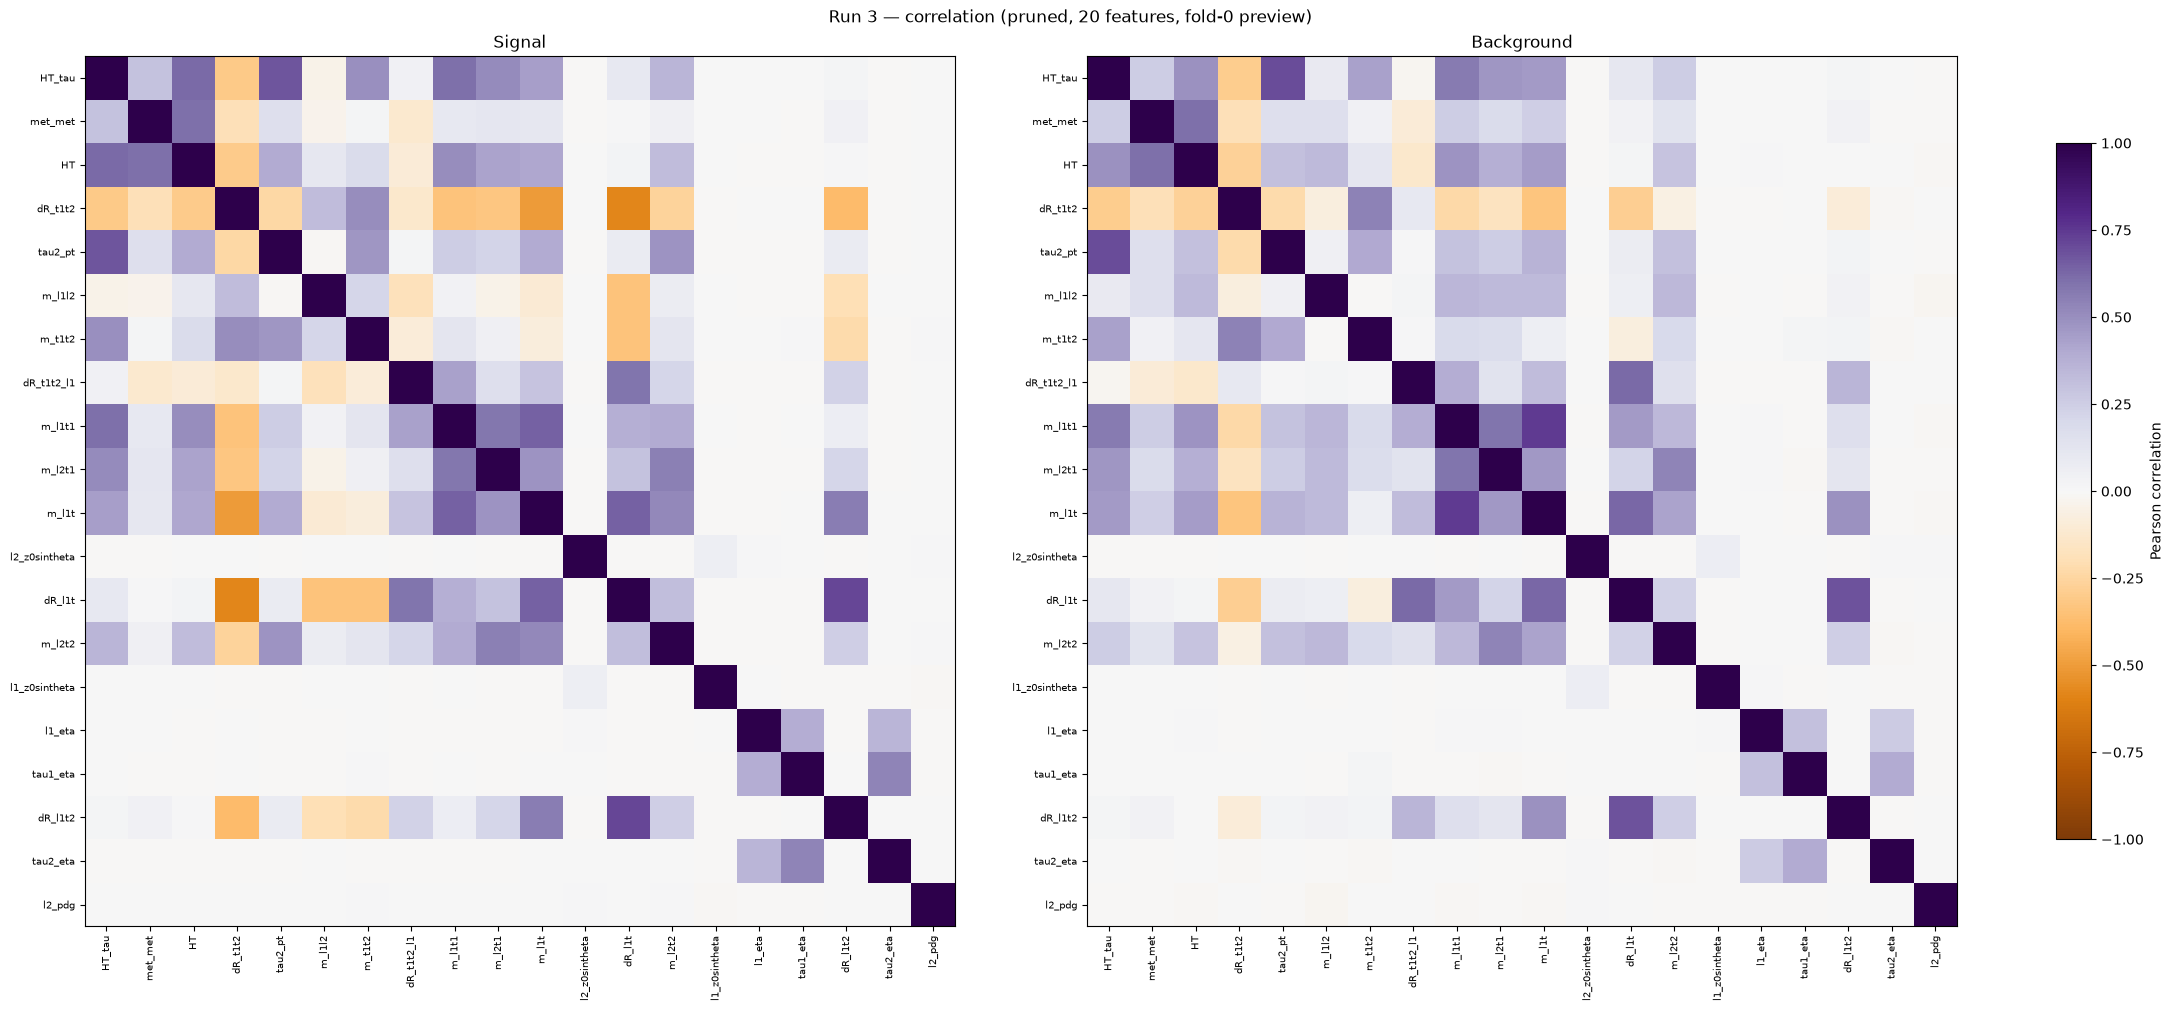

In [26]:
# ---- Retrain on the pruned feature set + re-check correlation (Run 3, fold-0 preview) ------
model_r3_pruned, auc_train_r3_pruned, auc_val_r3_pruned = train_xgb_fold(
    fd0_r3["train_df"][PRUNED_FEATURES_R3], fd0_r3["train_df"]["label"], fd0_r3["w_train_fit"],
    fd0_r3["val_df"][PRUNED_FEATURES_R3], fd0_r3["val_df"]["label"], np.abs(fd0_r3["val_df"]["w_phys"].to_numpy()),
    label="Run3 pruned (fold-0 preview)",
)

imp_r3_pruned = get_importance(model_r3_pruned, PRUNED_FEATURES_R3)
print(f"\nComparison (fold-0 preview) — full {len(features_r3)} features: val AUC = {auc_val_r3:.4f} | "
      f"pruned {len(PRUNED_FEATURES_R3)} features: val AUC = {auc_val_r3_pruned:.4f}")

plot_importance_bar(
    imp_r3_pruned, top_n=len(PRUNED_FEATURES_R3),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_R3)} features, Run 3, fold-0 preview)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R3 / "Run3AfterCorrelation.png",
)

pruned_top_feats_r3 = imp_r3_pruned.index.tolist()
pruned_corrs_r3 = grouped_correlations(fd0_r3["train_df"], pruned_top_feats_r3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_r3[1], pruned_corrs_r3[0]], ["Signal", "Background"], pruned_top_feats_r3,
    suptitle=f"Run 3 — correlation (pruned, {len(pruned_top_feats_r3)} features, fold-0 preview)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationPruned.png",
)


In [27]:
# ---- Optuna hyperparameter search (Run 3) -----------------------------------
OPTUNA_FEATURES_R3 = PRUNED_FEATURES_R3.copy()

study_r3 = run_optuna_search(
    data_r3, OPTUNA_FEATURES_R3, target_yields_r3, cell_cols=(),
    n_trials=N_OPTUNA_TRIALS, n_folds=N_FOLDS,
    base_n_estimators=800, study_name="xgb_2l2tau_run3",
)


/tmp/ipykernel_161419/4148764037.py:115: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/dege


[xgb_2l2tau_run3] completed trials: 15
[xgb_2l2tau_run3] best mean CV significance Z (5 eventNumber-folds): 0.04317
[xgb_2l2tau_run3] mean best iteration: 640
[xgb_2l2tau_run3] fold Z's: [0.04114320269954472, 0.04192093558950248, 0.04418142932005645, 0.04388650078284341, 0.04471472263771657]
[xgb_2l2tau_run3] best parameters:
    learning_rate: 0.023426000741059962
    max_depth: 8
    min_child_weight: 20.6127004614428
    subsample: 0.876775476091274
    colsample_bytree: 0.6736442148541117
    gamma: 1.2677559790183153
    reg_alpha: 0.007637559018459894
    reg_lambda: 27.76170949772299


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Run3 fold0] best_iteration=509 | weighted AUC: train=0.9897 val=0.9648
[Run3] fold 0: test_fold=0 val_fold=1 | train n=125801 (dropped 11394 neg) | test weighted AUC = 0.9743 | test significance Z = 0.041


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Run3 fold1] best_iteration=639 | weighted AUC: train=0.9908 val=0.9690
[Run3] fold 1: test_fold=1 val_fold=2 | train n=126468 (dropped 11534 neg) | test weighted AUC = 0.9630 | test significance Z = 0.041


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Run3 fold2] best_iteration=608 | weighted AUC: train=0.9898 val=0.9720
[Run3] fold 2: test_fold=2 val_fold=3 | train n=126468 (dropped 11445 neg) | test weighted AUC = 0.9686 | test significance Z = 0.041


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Run3 fold3] best_iteration=585 | weighted AUC: train=0.9896 val=0.9684
[Run3] fold 3: test_fold=3 val_fold=4 | train n=126534 (dropped 11352 neg) | test weighted AUC = 0.9743 | test significance Z = 0.043


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -15.1082 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Run3 fold4] best_iteration=461 | weighted AUC: train=0.9887 val=0.9700
[Run3] fold 4: test_fold=4 val_fold=0 | train n=126382 (dropped 11248 neg) | test weighted AUC = 0.9719 | test significance Z = 0.045
[Run3] OOF weighted AUC (pooled, every event scored by a model that never saw it) = 0.9707
[Run3] OOF max Asimov Z (pooled) = 0.113 at score cut = 0.9916


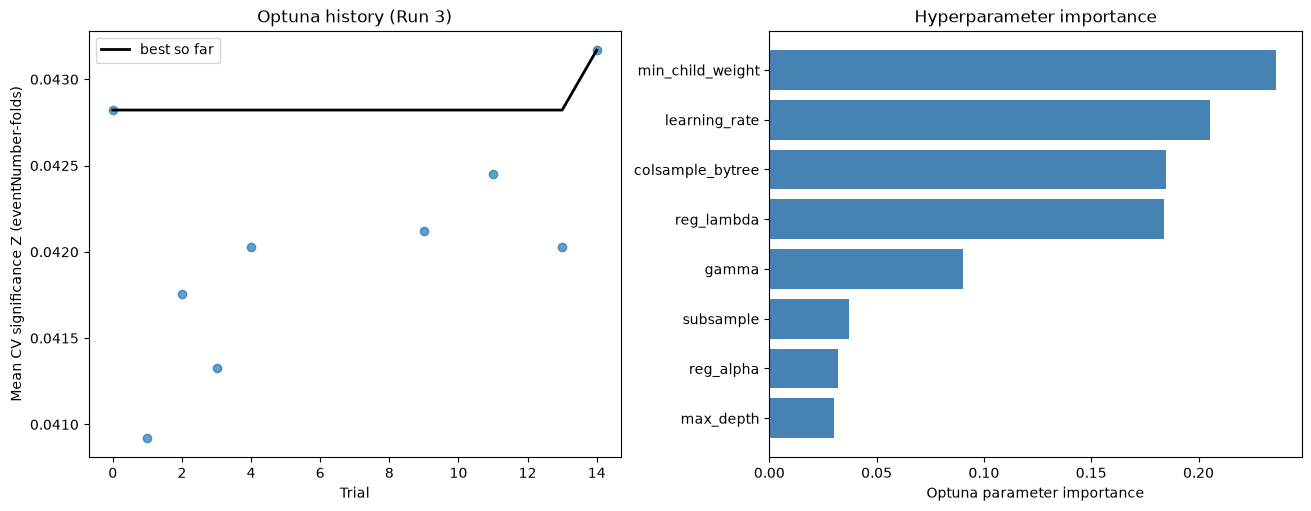

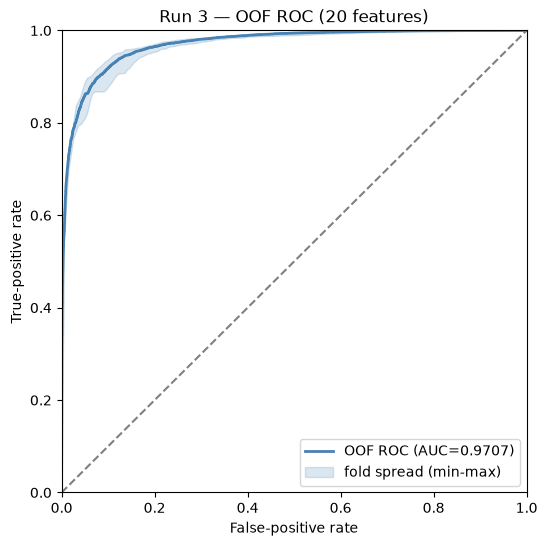

Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3AfterOptuna.png


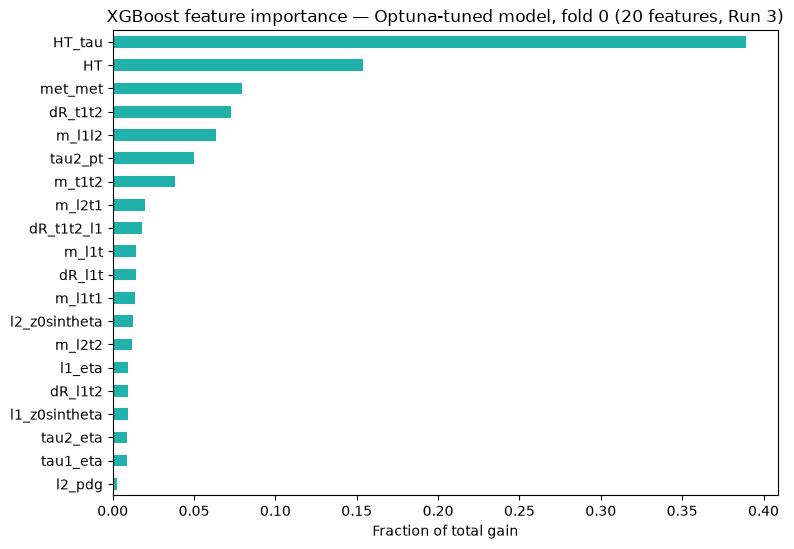

In [28]:
# ---- Final 5-fold OOF models + diagnostics (Run 3) --------------------------
best_params_r3 = params_from_study(study_r3)
oof_df_r3, models_r3 = run_kfold_xgb(
    data_r3, OPTUNA_FEATURES_R3, best_params_r3, target_yields_r3,
    cell_cols=(), n_folds=N_FOLDS, label="Run3",
)

plot_optuna_diagnostics(study_r3, title_suffix="(Run 3)")
oof_auc_r3 = plot_oof_roc(oof_df_r3, title=f"Run 3 — OOF ROC ({len(OPTUNA_FEATURES_R3)} features)")

final_imp_r3 = get_importance(models_r3[0], OPTUNA_FEATURES_R3)
plot_importance_bar(
    final_imp_r3, top_n=len(OPTUNA_FEATURES_R3),
    title=f"XGBoost feature importance — Optuna-tuned model, fold 0 ({len(OPTUNA_FEATURES_R3)} features, Run 3)",
    color="lightseagreen",
    save_path=PLOTS_DIR_R3 / "Run3AfterOptuna.png",
)


In [29]:
# ---- Persist the Run-3 fold models + feature list + hyperparams + OOF -------
save_track_artifacts(models_r3, OPTUNA_FEATURES_R3, best_params_r3, oof_df_r3, BASE_DIR_R3, "run3")


Saved 5 fold models + feature list + hyperparams + OOF scores -> PPSSP_2026/2l2tau/run3/ (track=run3)


### Held-Out Test Evaluation (Run 3)

`X_test_r3`/`y_test_r3`/`w_test_r3` have not participated in anything above -
not correlation pruning, not Optuna tuning, not early stopping. This is the
one place they are read, scoring the final Optuna-tuned model exactly once.


In [30]:
# ---- "Held-Out Test" under the k-fold refactor -----------------------------
# There is no separate held-out test set anymore - the OOF score array
# (oof_df_r3, computed by run_kfold_xgb above) already covers 100% of Run 3's
# events, each scored by a fold model that never trained on it.
print(f"[Run3] OOF weighted AUC (every event scored by a model that never saw it) = {oof_auc_r3:.5f}")


[Run3] OOF weighted AUC (every event scored by a model that never saw it) = 0.97072


## 5. Run 2 + Run 3 — Combined Track

Chain (concatenate) **all** backgrounds and **both** signals from **both**
campaigns into a single training sample, then run the same pipeline. This
checks whether the feature-importance ranking learned on the combined sample
differs from the rankings learned separately in Sections 3/4, and gives the
most statistically powerful (most events) version of the BDT.

The feature list here is rebuilt from branches common to **all 20 files**
(10 processes × 2 runs) - a feature dropped in only one run must be dropped
everywhere once the runs are concatenated. An extra `run` column (2 or 3) is
kept as bookkeeping (never a training feature) so the Run2/Run3 mix in
train/val can be checked, and so the split can be stratified on `label` AND
`run` jointly.


In [31]:
# ---- Combined-track output paths --------------------------------------------
BASE_DIR_COMB = Path("PPSSP_2026/2l2tau/combined")
PLOTS_DIR_COMB = BASE_DIR_COMB / "plots"
PLOTS_DIR_COMB.mkdir(parents=True, exist_ok=True)

# ---- Load & clean (Combined Run2 + Run3) ------------------------------------
features_comb = discover_common_features([BASE_DIR_R2, BASE_DIR_R3])
data_comb = pd.concat(
    [
        load_run_data(BASE_DIR_R2, run_label=2, features=features_comb),
        load_run_data(BASE_DIR_R3, run_label=3, features=features_comb),
    ],
    ignore_index=True,
)
data_comb, features_comb = clean_data(data_comb, features_comb)
data_comb = assign_folds(data_comb, n_folds=N_FOLDS)

# Per-run yield breakdown - confirms both runs contribute comparable
# statistics to the chained sample (no run silently dominating the training).
for run_label in (2, 3):
    sub = data_comb[data_comb.run == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data_comb["fold"].value_counts().sort_index())
data_comb.head()


85 candidate features (common to all 10 processes x 2 run(s) = 20 files, leakage-free)
Run 2 signal_ggF  :    31959 events after preselection
Run 2 signal_VBF  :     5598 events after preselection
Run 2 Diboson     :    36877 events after preselection
Run 2 Zjets       :     7746 events after preselection
Run 2 Wjets       :       67 events after preselection
Run 2 ttbar       :      331 events after preselection
Run 2 tops        :     3832 events after preselection
Run 2 SingleH     :     2946 events after preselection
Run 2 Vgamma      :     2019 events after preselection
Run 2 VVV         :     3593 events after preselection
Run 3 signal_ggF  :    96909 events after preselection
Run 3 signal_VBF  :     3439 events after preselection
Run 3 Diboson     :    82336 events after preselection
Run 3 Zjets       :    12919 events after preselection
Run 3 Wjets       :       51 events after preselection
Run 3 ttbar       :     3276 events after preselection
Run 3 tops        :    11065 even

,HT,HT_all,HT_jet,HT_lep,HT_lepMET,HT_tau,SumPt_l1j,SumPt_l1j1,SumPt_t1t2,dR_j1j2,...,tau2_phi,tau2_pt,weight,weights,eventNumber,w_phys,label,process,run,fold
0,"401,766.938","346,109.406","157,169.562","129,136.633","184,794.172","59,803.219","85,656.891","8,843.506","58,770.016",1.213,...,2.545,"27,495.463",0.001,0.025,428877,0.000,1,signal_ggF,2,2
1,"428,977.188","338,147.562","248,458.516","35,289.281","126,118.906","54,399.758","63,083.980","131,433.453","52,344.711",2.628,...,0.896,"25,522.369",0.001,0.033,3829318,0.000,1,signal_ggF,2,3
2,"315,016.281","205,395.172","104,338.836","60,435.344","170,056.469","40,620.992","51,673.379","96,008.062","13,889.353",1.668,...,-0.813,"20,106.373",0.001,0.029,28478587,0.000,1,signal_ggF,2,2
3,"213,809.875","194,648.031","103,448.945","39,590.828","58,752.672","51,608.262","73,043.195","73,043.195","10,999.922",3.288,...,2.107,"20,386.758",0.001,0.032,1277001,0.000,1,signal_ggF,2,1
4,"266,139.656","176,593.469",0.000,"119,507.734","209,053.922","57,085.727","99,571.945","99,571.945","28,874.680",NaN,...,-1.373,"22,728.211",0.001,0.031,13178478,0.000,1,signal_ggF,2,3


In [32]:
# ---- Yields / S over B (Combined) -------------------------------------------
# The combined sample is exactly Run2 + Run3 (same processes, same
# preselection), so its yields are simply the per-process sum of the two
# per-run tables already computed in Sections 3/4 - no need to re-read the
# ROOT files a third time.

yields_comb = (
    yields_r2.set_index("process")[["yield", "N_presel"]]
    .add(yields_r3.set_index("process")[["yield", "N_presel"]], fill_value=0)
    .reset_index()
)
is_signal_map = {proc: (label == 1) for proc, (_, label) in FILES.items()}
yields_comb["is_signal"] = yields_comb["process"].map(is_signal_map)

bkg_total_comb = yields_comb.loc[~yields_comb.is_signal, "yield"].sum()
sig_total_comb = yields_comb.loc[yields_comb.is_signal, "yield"].sum()
yields_comb["pct_of_bkg"] = np.where(~yields_comb.is_signal, 100 * yields_comb["yield"] / bkg_total_comb, np.nan)
yields_comb = yields_comb.sort_values(["is_signal", "yield"], ascending=[True, False])

print(yields_comb.to_string(index=False))
print(f"\nTotal background (presel, Run2+Run3): {bkg_total_comb:,.3f}")
print(f"Total signal     (presel, Run2+Run3): {sig_total_comb:,.3f}")
print(f"S/B       = {sig_total_comb/bkg_total_comb:.2e}")
print(f"S/sqrt(B) = {sig_total_comb/np.sqrt(bkg_total_comb):.4f}")


   process     yield  N_presel  is_signal  pct_of_bkg
     Zjets 2,457.785     20665      False      77.772
    Vgamma   336.917      4385      False      10.661
     ttbar   144.768      3607      False       4.581
   Diboson   139.336    119213      False       4.409
   SingleH    61.508      6186      False       1.946
      tops    15.602     14897      False       0.494
       VVV     4.373     17534      False       0.138
     Wjets    -0.038       118      False      -0.001
signal_ggF     0.871    128868       True         NaN
signal_VBF     0.037      9037       True         NaN

Total background (presel, Run2+Run3): 3,160.250
Total signal     (presel, Run2+Run3): 0.908
S/B       = 2.87e-04
S/sqrt(B) = 0.0162


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedWeightBalance.png


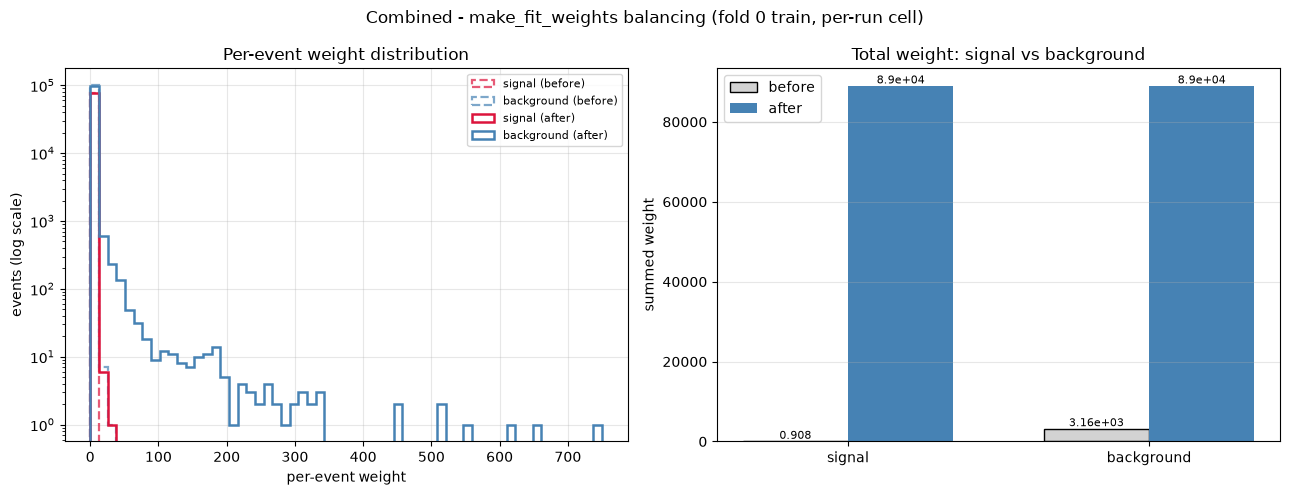

N_eff (training sample, positive-only, post yield-rescale) by run x label - fold 0:
run  label
2    0          344.630
     1       17,029.727
3    0          665.554
     1       32,043.469
Name: n_eff, dtype: float64

N_eff (eval sample, signed, FULL fold-0 test partition) by run x label:
run  label
2    0         110.957
     1       4,664.959
3    0          69.673
     1       8,675.249
Name: n_eff, dtype: float64

Dropped 16106 negative-w_phys training rows in this preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).


In [33]:
# ---- Weight-balance diagnostics (Combined, representative fold 0) ----------
# Stratifying by "run" here (cell_cols=("run",)) balances signal vs
# background WITHIN each run separately before the global mean-normalization.
target_yields_comb = compute_process_yield_targets(data_comb)
fd0_comb = prepare_fold_data(data_comb, features_comb, target_yields_comb, cell_cols=("run",), n_folds=N_FOLDS, k=0)

w_before_comb = fd0_comb["train_df"]["w_phys"].to_numpy()
w_after_comb = fd0_comb["w_train_fit"]
y_preview_comb = fd0_comb["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_comb, w_before_comb, w_after_comb,
    title="Combined - make_fit_weights balancing (fold 0 train, per-run cell)",
    save_path=PLOTS_DIR_COMB / "CombinedWeightBalance.png",
)

print("N_eff (training sample, positive-only, post yield-rescale) by run x label - fold 0:")
print(n_eff_table(fd0_comb["train_df"], ["run", "label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by run x label:")
print(n_eff_table(fd0_comb["test_df"], ["run", "label"]))
print(f"\nDropped {fd0_comb['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


[Combined baseline (fold-0 preview)] best_iteration=119 | weighted AUC: train=0.9891 val=0.9701

Top 30 features by total gain (Combined Run2+Run3, fold-0 preview):
               total_gain  gain_frac  weight
HT_tau        370,556.719      0.420 219.000
met_met        74,926.781      0.085 335.000
SumPt_t1t2     74,716.891      0.085 266.000
tau1_pt        68,259.664      0.077 164.000
m_l1l2         42,019.574      0.048 469.000
dR_t1t2        30,638.482      0.035 286.000
HT             29,485.602      0.033 131.000
m_t1t2         18,476.973      0.021 270.000
tau2_pt        15,016.373      0.017 184.000
l2_pdg         13,013.472      0.015  41.000
met_sumet       7,629.841      0.009 158.000
m_l2t1          7,427.722      0.008 209.000
dR_l1t          6,769.917      0.008 133.000
m_l1t           6,607.354      0.007 129.000
l2_z0sintheta   6,162.472      0.007 213.000
HT_lepMET       5,592.933      0.006 124.000
l1_z0sintheta   4,536.253      0.005 198.000
HT_all          4,373.828

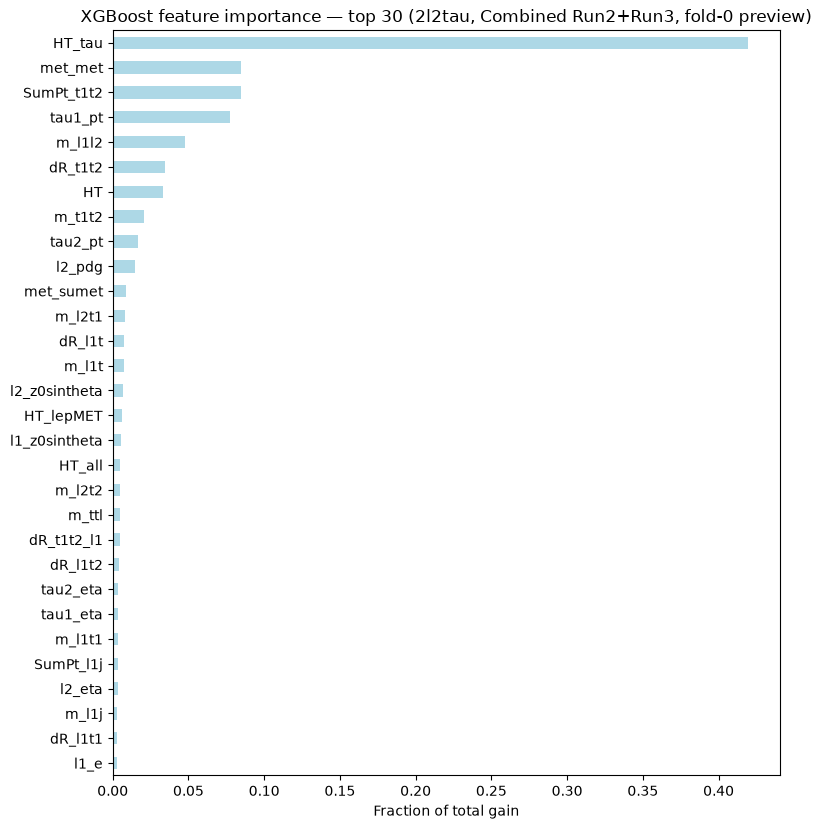

In [34]:
# ---- Baseline XGBoost + feature importance (Combined, fold-0 preview) ------
model_comb, auc_train_comb, auc_val_comb = train_xgb_fold(
    fd0_comb["train_df"][features_comb], fd0_comb["train_df"]["label"], fd0_comb["w_train_fit"],
    fd0_comb["val_df"][features_comb], fd0_comb["val_df"]["label"], np.abs(fd0_comb["val_df"]["w_phys"].to_numpy()),
    label="Combined baseline (fold-0 preview)",
)

imp_comb = get_importance(model_comb, features_comb)
print(f"\nTop {TOP_N_IMPORTANCE} features by total gain (Combined Run2+Run3, fold-0 preview):")
print(imp_comb[["total_gain", "gain_frac", "weight"]].head(TOP_N_IMPORTANCE).to_string())
print(f"Features never used in a split: {(imp_comb['total_gain'] == 0).sum()} / {len(features_comb)}")

plot_importance_bar(imp_comb, top_n=TOP_N_IMPORTANCE,
                     title=f"XGBoost feature importance — top {TOP_N_IMPORTANCE} (2l2tau, Combined Run2+Run3, fold-0 preview)",
                     save_path=PLOTS_DIR_COMB / "CombinedBeforeCorrelation.png")


Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedCorrelationTop30.png


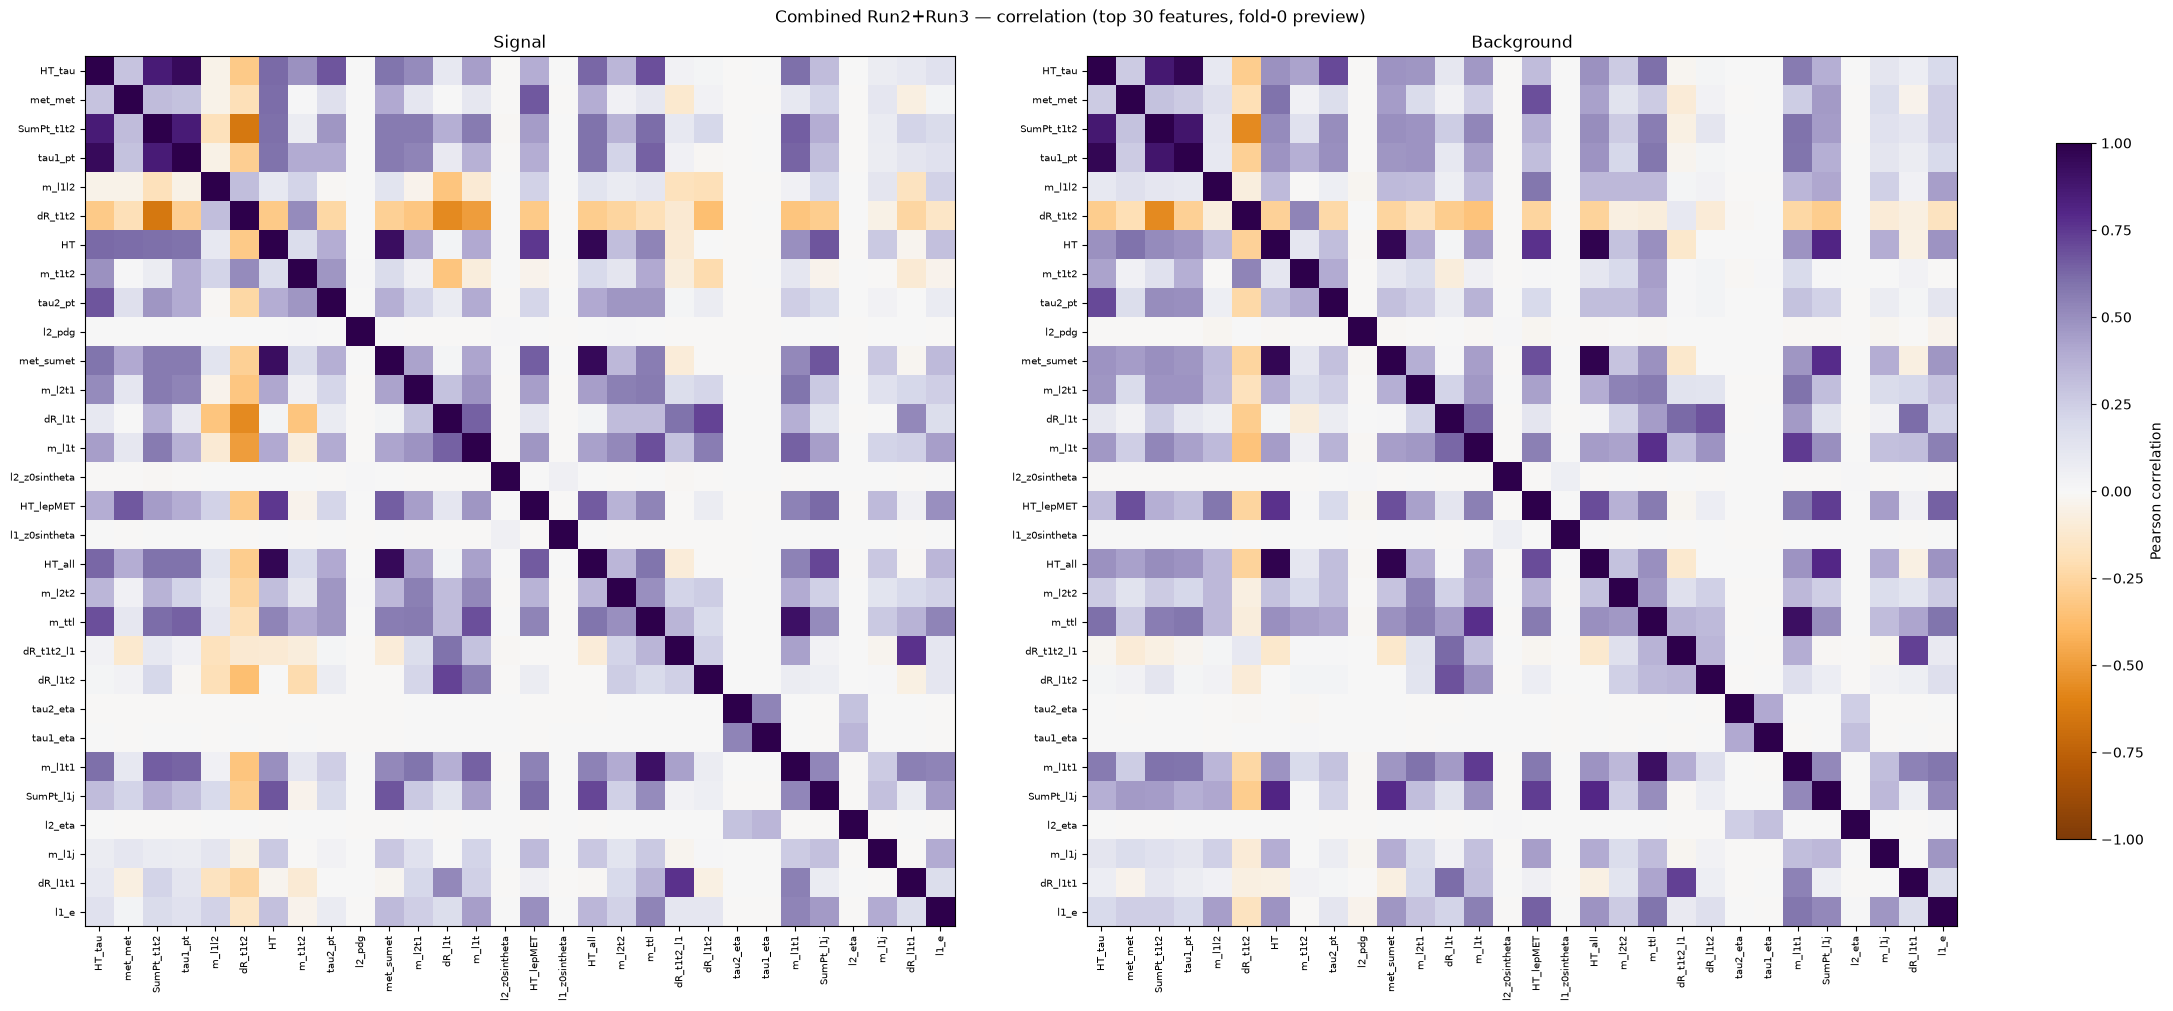

Pairs with |corr| > 0.50 (signal):
HT          HT_all       0.966
met_sumet   HT_all       0.947
HT_tau      tau1_pt      0.944
HT          met_sumet    0.925
m_ttl       m_l1t1       0.908
HT_tau      SumPt_t1t2   0.859
SumPt_t1t2  tau1_pt      0.858
dR_t1t2_l1  dR_l1t1      0.770
HT          HT_lepMET    0.756
dR_l1t      dR_l1t2      0.719
HT_all      SumPt_l1j    0.713
HT_tau      m_ttl        0.691
m_l1t       m_ttl        0.689
met_sumet   SumPt_l1j    0.678
HT          SumPt_l1j    0.675
HT_tau      tau2_pt      0.672
met_met     HT_lepMET    0.670
HT_lepMET   HT_all       0.662
SumPt_t1t2  m_l1t1       0.649
met_sumet   HT_lepMET    0.649
tau1_pt     m_ttl        0.648
m_l1t       m_l1t1       0.647
dR_l1t      m_l1t        0.646
SumPt_t1t2  dR_t1t2      0.646
tau1_pt     m_l1t1       0.638
HT_tau      HT_all       0.628
HT_lepMET   SumPt_l1j    0.624
HT_tau      HT           0.621
SumPt_t1t2  m_ttl        0.612
met_met     HT           0.610
SumPt_t1t2  HT           0.604
HT_t

In [35]:
# ---- Correlation of the top features + pruning (Combined, fold-0 preview) --
top_feats_comb = imp_comb.index[:TOP_N_IMPORTANCE].tolist()
corrs_comb = grouped_correlations(fd0_comb["train_df"], top_feats_comb, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [corrs_comb[1], corrs_comb[0]], ["Signal", "Background"], top_feats_comb,
    suptitle=f"Combined Run2+Run3 — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationTop30.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_comb[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_comb[0]).to_string())

corr_max_comb = corrs_comb[1].abs().combine(corrs_comb[0].abs(), np.maximum)
PRUNED_FEATURES_COMB, dropped_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, N_KEEP)


[Combined pruned (fold-0 preview)] best_iteration=211 | weighted AUC: train=0.9903 val=0.9656

Comparison (fold-0 preview) — full 79 features: val AUC = 0.9701 | pruned 20 features: val AUC = 0.9656
Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedAfterCorrelation.png


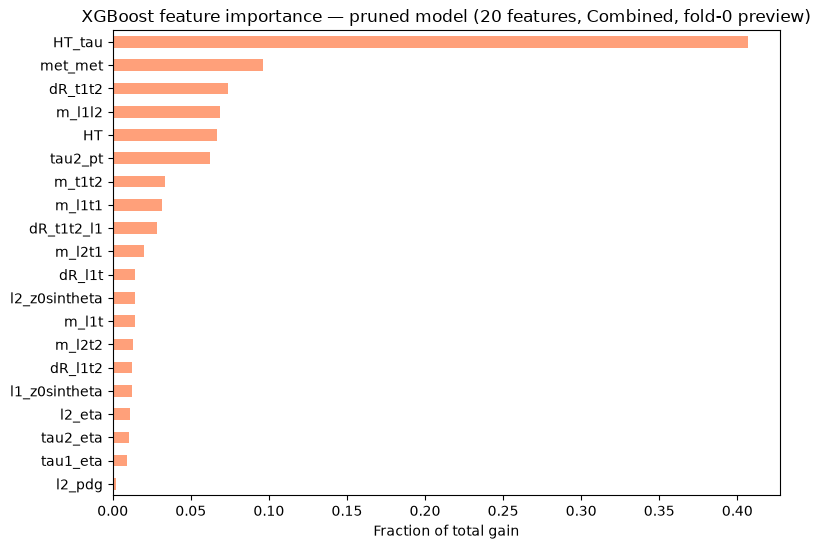

In [36]:
# ---- Retrain on the pruned feature set + re-check correlation (Combined, fold-0 preview) ---
model_comb_pruned, auc_train_comb_pruned, auc_val_comb_pruned = train_xgb_fold(
    fd0_comb["train_df"][PRUNED_FEATURES_COMB], fd0_comb["train_df"]["label"], fd0_comb["w_train_fit"],
    fd0_comb["val_df"][PRUNED_FEATURES_COMB], fd0_comb["val_df"]["label"], np.abs(fd0_comb["val_df"]["w_phys"].to_numpy()),
    label="Combined pruned (fold-0 preview)",
)

imp_comb_pruned = get_importance(model_comb_pruned, PRUNED_FEATURES_COMB)
print(f"\nComparison (fold-0 preview) — full {len(features_comb)} features: val AUC = {auc_val_comb:.4f} | "
      f"pruned {len(PRUNED_FEATURES_COMB)} features: val AUC = {auc_val_comb_pruned:.4f}")

plot_importance_bar(
    imp_comb_pruned, top_n=len(PRUNED_FEATURES_COMB),
    title=f"XGBoost feature importance — pruned model ({len(PRUNED_FEATURES_COMB)} features, Combined, fold-0 preview)",
    color="lightsalmon",
    save_path=PLOTS_DIR_COMB / "CombinedAfterCorrelation.png",
)


### Top-15 further cut

Take the top 15 features from the pruned model's own ranking and retrain once
more, to see how much validation AUC is lost going from 20 → 15 features.


In [37]:
# ---- Retrain using only the top 15 features (Combined, fold-0 preview) -----
TOP_15 = 15
TOP15_FEATURES_COMB = imp_comb_pruned.index[:TOP_15].tolist()
print(f"Top {TOP_15} features kept (from the 20-feature pruned model's own ranking):")
for i, feat in enumerate(TOP15_FEATURES_COMB, 1):
    print(f"  {i:2d}. {feat}")

model_comb_top15, auc_train_comb_top15, auc_val_comb_top15 = train_xgb_fold(
    fd0_comb["train_df"][TOP15_FEATURES_COMB], fd0_comb["train_df"]["label"], fd0_comb["w_train_fit"],
    fd0_comb["val_df"][TOP15_FEATURES_COMB], fd0_comb["val_df"]["label"], np.abs(fd0_comb["val_df"]["w_phys"].to_numpy()),
    label="Combined top-15 (fold-0 preview)",
)

print(f"\nWeighted AUC (top {TOP_15} features, fold-0 preview):  val = {auc_val_comb_top15:.4f}")
print(f"Weighted AUC (pruned {len(PRUNED_FEATURES_COMB)} features, fold-0 preview): val = {auc_val_comb_pruned:.4f}")
print(f"Weighted AUC (full {len(features_comb)} features, fold-0 preview):    val = {auc_val_comb:.4f}")


Top 15 features kept (from the 20-feature pruned model's own ranking):
   1. HT_tau
   2. met_met
   3. dR_t1t2
   4. m_l1l2
   5. HT
   6. tau2_pt
   7. m_t1t2
   8. m_l1t1
   9. dR_t1t2_l1
  10. m_l2t1
  11. dR_l1t
  12. l2_z0sintheta
  13. m_l1t
  14. m_l2t2
  15. dR_l1t2
[Combined top-15 (fold-0 preview)] best_iteration=144 | weighted AUC: train=0.9864 val=0.9660

Weighted AUC (top 15 features, fold-0 preview):  val = 0.9660
Weighted AUC (pruned 20 features, fold-0 preview): val = 0.9656
Weighted AUC (full 79 features, fold-0 preview):    val = 0.9701


Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedModelComparison.png


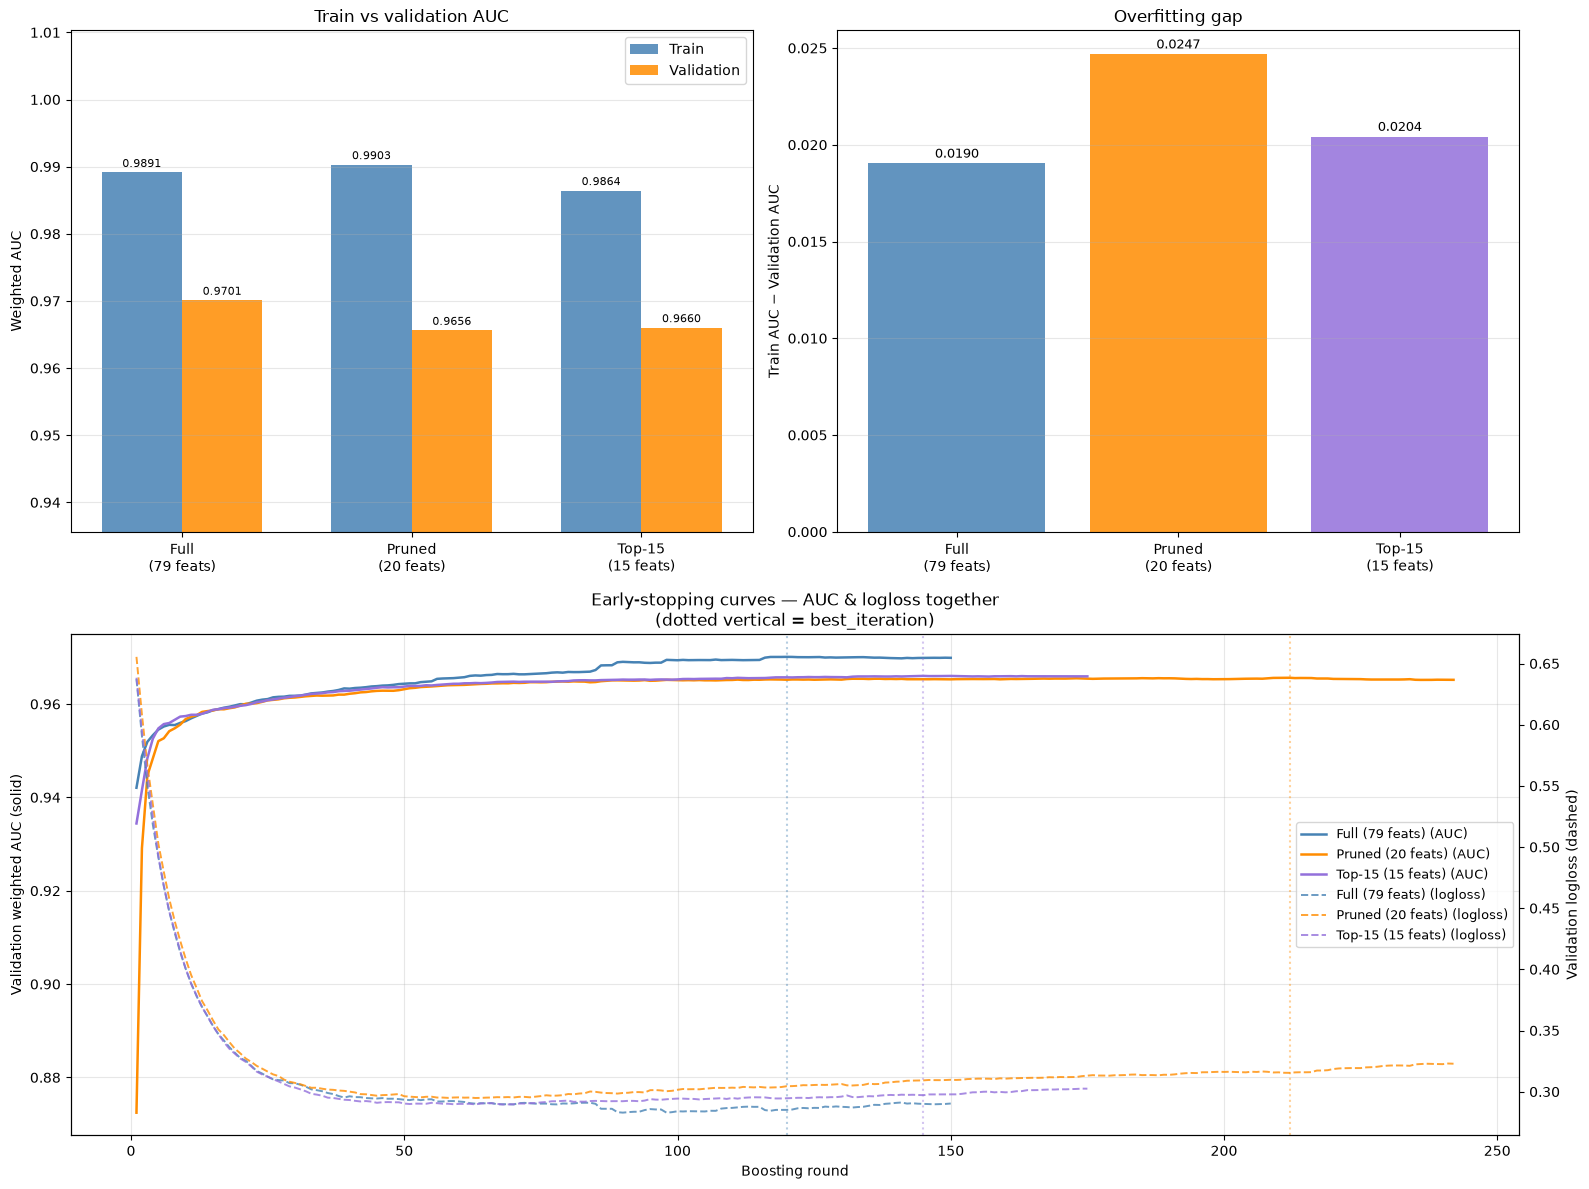

Model                #Features   Train AUC     Val AUC       Gap
Full                        79      0.9891      0.9701    0.0190
Pruned                      20      0.9903      0.9656    0.0247
Top-15                      15      0.9864      0.9660    0.0204


In [38]:
# ---- Model comparison — AUC & training curves (full vs pruned vs top-15) ---

model_names_comb = [f"Full\n({len(features_comb)} feats)", f"Pruned\n({len(PRUNED_FEATURES_COMB)} feats)",
                     f"Top-15\n({len(TOP15_FEATURES_COMB)} feats)"]
colors_comb = ["steelblue", "darkorange", "mediumpurple"]
train_aucs_comb = [auc_train_comb, auc_train_comb_pruned, auc_train_comb_top15]
val_aucs_comb = [auc_val_comb, auc_val_comb_pruned, auc_val_comb_top15]
models_fitted_comb = [model_comb, model_comb_pruned, model_comb_top15]

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)
ax_bars = fig.add_subplot(gs[0, 0])
ax_gap = fig.add_subplot(gs[0, 1])
ax_auc = fig.add_subplot(gs[1, :])   # wide combined panel, spans both columns

# --- Panel (0,0): train vs validation AUC, grouped bars --------------------
x = np.arange(len(model_names_comb))
width = 0.35
b1 = ax_bars.bar(x - width/2, train_aucs_comb, width, label="Train", color="steelblue", alpha=0.85)
b2 = ax_bars.bar(x + width/2, val_aucs_comb, width, label="Validation", color="darkorange", alpha=0.85)
for bars in (b1, b2):
    ax_bars.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
ax_bars.set_xticks(x)
ax_bars.set_xticklabels(model_names_comb)
ax_bars.set_ylabel("Weighted AUC")
ax_bars.set_ylim(min(val_aucs_comb) - 0.03, max(train_aucs_comb) + 0.02)
ax_bars.set_title("Train vs validation AUC")
ax_bars.legend()
ax_bars.grid(axis="y", alpha=0.3)

# --- Panel (0,1): overfitting gap (train - validation AUC) -----------------
gaps_comb = [t - v for t, v in zip(train_aucs_comb, val_aucs_comb)]
bars = ax_gap.bar(model_names_comb, gaps_comb, color=colors_comb, alpha=0.85)
ax_gap.bar_label(bars, fmt="%.4f", fontsize=9, padding=2)
ax_gap.set_ylabel("Train AUC − Validation AUC")
ax_gap.set_title("Overfitting gap")
ax_gap.grid(axis="y", alpha=0.3)

# --- Panel (1, :): validation AUC + logloss vs boosting round --------------
ax_loss = ax_auc.twinx()
for name, mdl, color in zip(model_names_comb, models_fitted_comb, colors_comb):
    label = name.replace("\n", " ")
    auc_curve = mdl.evals_result()["validation_0"]["auc"]
    loss_curve = mdl.evals_result()["validation_0"]["logloss"]
    rounds = np.arange(1, len(auc_curve) + 1)
    ax_auc.plot(rounds, auc_curve, color=color, linestyle="-", linewidth=1.8, label=f"{label} (AUC)")
    ax_loss.plot(rounds, loss_curve, color=color, linestyle="--", linewidth=1.4, alpha=0.8, label=f"{label} (logloss)")
    ax_auc.axvline(mdl.best_iteration + 1, color=color, linestyle=":", alpha=0.4)

ax_auc.set_xlabel("Boosting round")
ax_auc.set_ylabel("Validation weighted AUC (solid)")
ax_loss.set_ylabel("Validation logloss (dashed)")
ax_auc.set_title("Early-stopping curves — AUC & logloss together\n(dotted vertical = best_iteration)")
ax_auc.grid(alpha=0.3)

lines_auc, labels_auc = ax_auc.get_legend_handles_labels()
lines_loss, labels_loss = ax_loss.get_legend_handles_labels()
ax_auc.legend(lines_auc + lines_loss, labels_auc + labels_loss, fontsize=9, loc="center right")

plt.tight_layout()
fig.savefig(PLOTS_DIR_COMB / "CombinedModelComparison.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_COMB / 'CombinedModelComparison.png'}")
plt.show()

print(f"{'Model':<20s}{'#Features':>10s}{'Train AUC':>12s}{'Val AUC':>12s}{'Gap':>10s}")
for name, feats, tr, va in zip(["Full", "Pruned", "Top-15"],
                                [features_comb, PRUNED_FEATURES_COMB, TOP15_FEATURES_COMB],
                                train_aucs_comb, val_aucs_comb):
    print(f"{name:<20s}{len(feats):>10d}{tr:>12.4f}{va:>12.4f}{tr - va:>10.4f}")


### Optuna tuning (Combined)


In [39]:
# ---- Optuna hyperparameter search (Combined) --------------------------------
OPTUNA_FEATURES_COMB = PRUNED_FEATURES_COMB.copy()

study_comb = run_optuna_search(
    data_comb, OPTUNA_FEATURES_COMB, target_yields_comb, cell_cols=("run",),
    n_trials=N_OPTUNA_TRIALS, n_folds=N_FOLDS,
    base_n_estimators=800, study_name="xgb_2l2tau_combined",
)


/tmp/ipykernel_161419/4148764037.py:115: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negat


[xgb_2l2tau_combined] completed trials: 15
[xgb_2l2tau_combined] best mean CV significance Z (5 eventNumber-folds): 0.06811
[xgb_2l2tau_combined] mean best iteration: 403
[xgb_2l2tau_combined] fold Z's: [0.07568845189431679, 0.06320380023484688, 0.07027073325258626, 0.06583753045003822, 0.06554180292786703]
[xgb_2l2tau_combined] best parameters:
    learning_rate: 0.04029695576831731
    max_depth: 6
    min_child_weight: 5.4182823195332395
    subsample: 0.7164916560792167
    colsample_bytree: 0.8447411578889518
    gamma: 0.6974693032602092
    reg_alpha: 0.0028888383623653178
    reg_lambda: 0.9745399020374083


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Combined fold0] best_iteration=398 | weighted AUC: train=0.9878 val=0.9673
[Combined] fold 0: test_fold=0 val_fold=1 | train n=177902 (dropped 16106 neg) | test weighted AUC = 0.9743 | test significance Z = 0.076


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Combined fold1] best_iteration=397 | weighted AUC: train=0.9878 val=0.9702
[Combined] fold 1: test_fold=1 val_fold=2 | train n=178692 (dropped 16181 neg) | test weighted AUC = 0.9668 | test significance Z = 0.061


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Combined fold2] best_iteration=392 | weighted AUC: train=0.9871 val=0.9706
[Combined] fold 2: test_fold=2 val_fold=3 | train n=178689 (dropped 16142 neg) | test weighted AUC = 0.9704 | test significance Z = 0.068


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Combined fold3] best_iteration=323 | weighted AUC: train=0.9856 val=0.9701
[Combined] fold 3: test_fold=3 val_fold=4 | train n=179105 (dropped 16097 neg) | test weighted AUC = 0.9709 | test significance Z = 0.066


/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(
/tmp/ipykernel_161419/2617707609.py:52: UserWarning: rescale_weights_by_yield: process 'Wjets' has full-sample signed yield -0.0380651 <= 1e-06 (mostly-negative weights?) - clamping target to 1e-06 to avoid a negative/degenerate rescale factor.
  warnings.warn(


[Combined fold4] best_iteration=381 | weighted AUC: train=0.9872 val=0.9722
[Combined] fold 4: test_fold=4 val_fold=0 | train n=178613 (dropped 16003 neg) | test weighted AUC = 0.9733 | test significance Z = 0.066
[Combined] OOF weighted AUC (pooled, every event scored by a model that never saw it) = 0.9713
[Combined] OOF max Asimov Z (pooled) = 0.180 at score cut = 0.9943


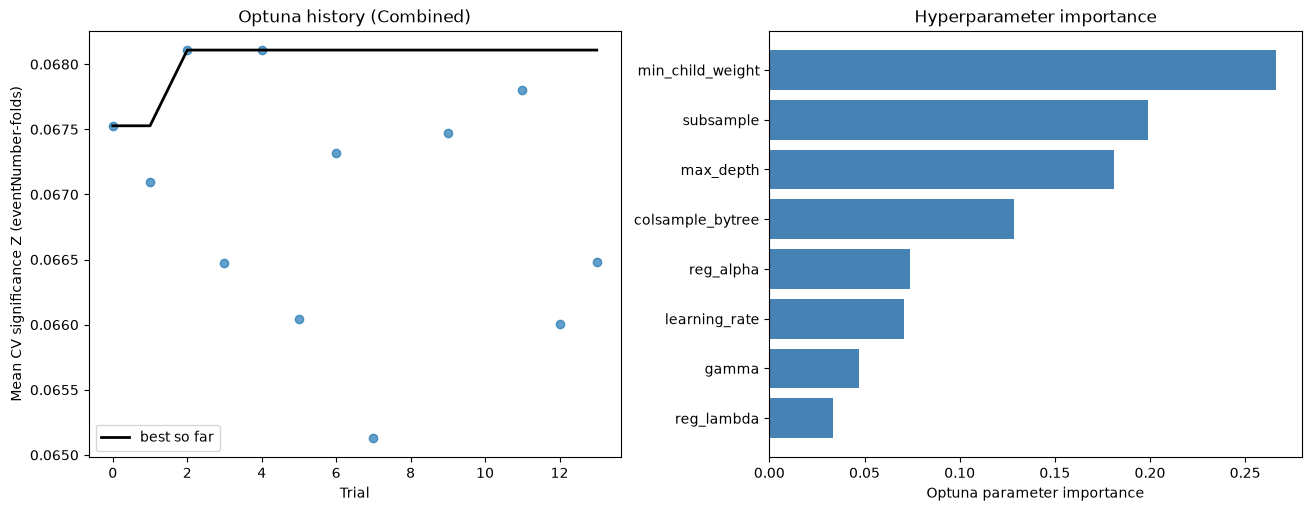

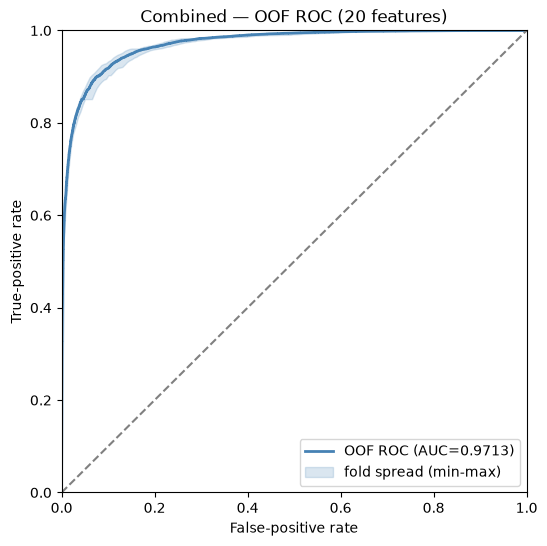

Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedAfterOptuna.png


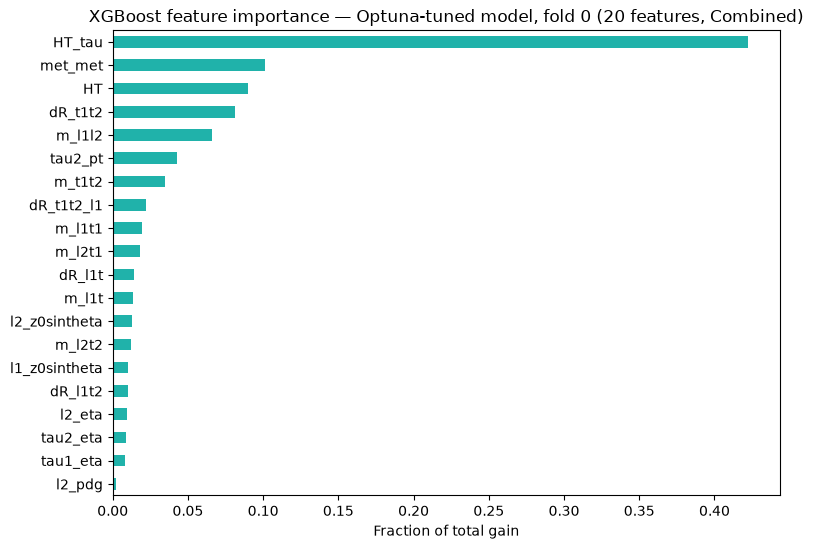

In [40]:
# ---- Final 5-fold OOF models + diagnostics (Combined) -----------------------
best_params_comb = params_from_study(study_comb)
oof_df_comb, models_comb = run_kfold_xgb(
    data_comb, OPTUNA_FEATURES_COMB, best_params_comb, target_yields_comb,
    cell_cols=("run",), n_folds=N_FOLDS, label="Combined",
)

plot_optuna_diagnostics(study_comb, title_suffix="(Combined)")
oof_auc_comb = plot_oof_roc(oof_df_comb, title=f"Combined — OOF ROC ({len(OPTUNA_FEATURES_COMB)} features)")

final_imp_comb = get_importance(models_comb[0], OPTUNA_FEATURES_COMB)
plot_importance_bar(
    final_imp_comb, top_n=len(OPTUNA_FEATURES_COMB),
    title=f"XGBoost feature importance — Optuna-tuned model, fold 0 ({len(OPTUNA_FEATURES_COMB)} features, Combined)",
    color="lightseagreen",
    save_path=PLOTS_DIR_COMB / "CombinedAfterOptuna.png",
)


In [41]:
# ---- Persist the Combined fold models + feature list + hyperparams + OOF ---
save_track_artifacts(models_comb, OPTUNA_FEATURES_COMB, best_params_comb, oof_df_comb, BASE_DIR_COMB, "combined")


Saved 5 fold models + feature list + hyperparams + OOF scores -> PPSSP_2026/2l2tau/combined/ (track=combined)


### Held-Out Test Evaluation (Combined)

`X_test_comb`/`y_test_comb`/`w_test_comb` have not participated in anything
above - not correlation pruning, not Optuna tuning, not early stopping. This
is the one place they are read, scoring the final Optuna-tuned model
exactly once.


In [42]:
# ---- "Held-Out Test" under the k-fold refactor -----------------------------
# There is no separate held-out test set anymore - oof_df_comb already
# covers 100% of the Combined track's events, each scored by a fold model
# that never trained on it.
print(f"[Combined] OOF weighted AUC (every event scored by a model that never saw it) = {oof_auc_comb:.5f}")


[Combined] OOF weighted AUC (every event scored by a model that never saw it) = 0.97131


### Did the ranking change? Run 2-only vs Run 3-only vs Combined

Compare where each of the Combined track's tuned features lands in the Run
2-only and Run 3-only tuned rankings (Sections 3/4) — a large rank shift for
a feature would be a warning sign that it behaves inconsistently between
campaigns.


In [43]:
# ---- Rank comparison across the three tuned tracks --------------------------
combined_rank = {feat: i + 1 for i, feat in enumerate(final_imp_comb.index)}
run2_rank = {feat: i + 1 for i, feat in enumerate(final_imp_r2.index)}
run3_rank = {feat: i + 1 for i, feat in enumerate(final_imp_r3.index)}

rows = []
for feat in OPTUNA_FEATURES_COMB:
    rows.append({
        "feature": feat,
        "combined_rank": combined_rank.get(feat),
        "run2_only_rank": run2_rank.get(feat, "not kept"),
        "run3_only_rank": run3_rank.get(feat, "not kept"),
    })
rank_compare = pd.DataFrame(rows).set_index("feature")


print(f"Combined-track top-{len(OPTUNA_FEATURES_COMB)} features vs. their rank in the "
      f"Run2-only / Run3-only tuned models:")
print(rank_compare.to_string())

# Simple rank-shift summary (only where the feature survived pruning in both
# single-run tracks too)

comparable = rank_compare[
    pd.to_numeric(rank_compare["run2_only_rank"], errors="coerce").notna()
    & pd.to_numeric(rank_compare["run3_only_rank"], errors="coerce").notna()
].astype({"run2_only_rank": float, "run3_only_rank": float})


rank_shift = ((comparable["combined_rank"] - comparable["run2_only_rank"]).abs()
              + (comparable["combined_rank"] - comparable["run3_only_rank"]).abs()) / 2


if len(rank_shift):
    print(f"\nMean |rank shift| vs combined (averaged over Run2/Run3): {rank_shift.mean():.1f} positions")
    print(f"Max |rank shift|: {rank_shift.max():.0f} positions ({rank_shift.idxmax()})")


Combined-track top-20 features vs. their rank in the Run2-only / Run3-only tuned models:
               combined_rank run2_only_rank run3_only_rank
feature                                                   
HT_tau                     1              1              1
met_met                    2              2              3
m_l1l2                     5              5              5
dR_t1t2                    4              3              4
HT                         3              4              2
m_t1t2                     7              6              7
tau2_pt                    6              7              6
l2_pdg                    20             20             20
m_l2t1                    10              8              8
dR_l1t                    11             10             11
m_l1t                     12              9             10
l2_z0sintheta             13             16             13
l1_z0sintheta             15             14             17
m_l2t2                    

## 6. Run 2 vs Run 3 — Domain-Shift Check

A separate, lightweight XGBoost model whose only job is telling **Run 2**
signal events (ggF + VBF) apart from **Run 3** signal events. This is
completely independent from the signal-vs-background classifiers trained in
Sections 3-5 - nothing there is touched or reused as a model, only their
*feature list* is reused (the Combined track's tuned, decorrelated features,
persisted to disk in Section 5), so the test reflects exactly the variables
that would feed the final analysis.

**Label convention:** Run 2 = 0, Run 3 = 1. **Weights:** the raw `weights`
branch is used AS-IS (not `weight * weights`, unlike `w_phys` elsewhere) -
this test cares about the shape of the per-event generator weight, not the
physical yield.

**How to read the resulting AUC:** AUC ≈ 0.5 → the classifier can't tell the
runs apart → the feature distributions are effectively the same between Run 2
and Run 3. AUC well above 0.5 → a genuine distribution shift, and `AUC - 0.5`
is roughly its effect size.


In [44]:
# ---- Feature set to test for a Run2/Run3 shift ------------------------------
# Uses the Combined track's tuned, decorrelated feature set (persisted to
# disk in Section 5 by save_track_artifacts) - these are the features that
# would actually go into the final analysis, so this checks exactly the
# variables that matter. Loaded from disk (rather than reusing the in-memory
# variable) so this section can also be run on its own after a kernel restart.
PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots_2l2tau")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)

FEATURES_PATH_DOMAIN = BASE_DIR_COMB / "features_combined.json"
with open(FEATURES_PATH_DOMAIN) as f:
    domain_features = json.load(f)

print(f"Loaded {len(domain_features)} features from {FEATURES_PATH_DOMAIN}:")
print(domain_features)

SIGNAL_FILES = {"signal_ggF": "signal_ggF.root", "signal_VBF": "signal_VBF.root"}
WEIGHT_BRANCH = "weights"   # raw per-event branch, used AS-IS as sample_weight

# Sanity check: confirm every feature exists in all four signal files
# (ggF + VBF, Run2 + Run3) before we try to read them.
common_domain = None
for base_dir in (BASE_DIR_R2, BASE_DIR_R3):
    for fname in SIGNAL_FILES.values():
        keys = set(uproot.open({str(base_dir / fname): TREE_NAME}).keys())
        common_domain = keys if common_domain is None else common_domain & keys
missing = [f for f in domain_features if f not in common_domain]
if missing:
    raise ValueError(f"Features missing from one or more signal files: {missing}")


Loaded 20 features from PPSSP_2026/2l2tau/combined/features_combined.json:
['HT_tau', 'met_met', 'm_l1l2', 'dR_t1t2', 'HT', 'm_t1t2', 'tau2_pt', 'l2_pdg', 'm_l2t1', 'dR_l1t', 'm_l1t', 'l2_z0sintheta', 'l1_z0sintheta', 'm_l2t2', 'dR_t1t2_l1', 'dR_l1t2', 'tau2_eta', 'tau1_eta', 'm_l1t1', 'l2_eta']


In [45]:
# ---- Load Run2 + Run3 signal events (label: Run2=0, Run3=1) -----------------
frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_R2), (1, "Run 3", BASE_DIR_R3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        df["process"] = proc
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(domain_data)} events "
      f"(Run 2 = {(domain_data.run_label == 0).sum()}, Run 3 = {(domain_data.run_label == 1).sum()})")

# ---- Post-concat cleaning: constant features + sentinel -> NaN -------------
domain_data, domain_features = clean_data(domain_data, domain_features)

# ---- Sanity check: weight sums & negative-weight fractions ------------------
# Comparable total weight -> comparable effective normalization between runs.
# Negative weights are reported but NOT dropped (Sherpa NLO interference
# effects are physical, not a data-quality issue).
for run_label, run_name in [(0, "Run 2"), (1, "Run 3")]:
    subset = domain_data.loc[domain_data.run_label == run_label, WEIGHT_BRANCH]
    total_w = subset.sum()
    neg_frac = (subset < 0).mean()
    print(f"{run_name}: sum({WEIGHT_BRANCH}) = {total_w:12.4f} | "
          f"negative-weight fraction = {neg_frac:6.2%} | n_events = {len(subset)}")


Run 2 signal_ggF  :    31959 events after preselection
Run 2 signal_VBF  :     5598 events after preselection
Run 3 signal_ggF  :    96909 events after preselection
Run 3 signal_VBF  :     3439 events after preselection

Total: 137905 events (Run 2 = 37557, Run 3 = 100348)
Dropped 0 constant/empty features:
  []

20 final features
Run 2: sum(weights) =     871.9282 | negative-weight fraction =  5.24% | n_events = 37557
Run 3: sum(weights) =    2634.0020 | negative-weight fraction =  5.94% | n_events = 100348


In [46]:
# ---- Build training arrays ---------------------------------------------------

X = domain_data[domain_features]
y = domain_data["run_label"].to_numpy()
w_raw = domain_data[WEIGHT_BRANCH].to_numpy()   # raw branch, AS-IS
w_abs = np.abs(w_raw)

# --- Class balance ------------------------------------------------------------
# Run 2 and Run 3 can have different total weight (see sanity check above);
# rescale per-event weights so both runs contribute equal total weight,
# otherwise the AUC would partly reflect a normalization difference rather
# than a genuine shape difference (mirrors make_fit_weights, but keyed on
# run_label instead of label).

w_fit = w_abs.copy()
sum_r2, sum_r3 = w_fit[y == 0].sum(), w_fit[y == 1].sum()
w_fit[y == 1] *= sum_r2 / sum_r3
w_fit *= len(w_fit) / w_fit.sum()

print(f"Run2/Run3 total-weight ratio before balancing: {sum_r2 / sum_r3:.3f}")
print(f"Run2/Run3 total-weight ratio after balancing:  {w_fit[y == 0].sum() / w_fit[y == 1].sum():.3f}")


Run2/Run3 total-weight ratio before balancing: 0.330
Run2/Run3 total-weight ratio after balancing:  1.000


In [47]:
def bootstrap_weighted_auc_ci(y, pred, w_abs, n_boot=1000, ci=0.95, random_state=RANDOM_STATE):
    """Percentile bootstrap CI for a *weighted* AUC, resampling events (with
    replacement) and recomputing the weighted AUC each time - used as the
    "honest" error bar for the Section 7 domain-shift forest plot.

    Preferred over the analytic no-shift noise floor sigma ~= 1/sqrt(6*N)
    because that formula assumes balanced, unweighted classes; the physical
    event weights used here (partly from negative Sherpa weights, see Section
    1) reduce the effective statistics below what raw event counts would
    suggest, so this bootstrap reflects the true uncertainty instead of
    understating it.

    `pred` should be an out-of-fold prediction (one held-out prediction per
    event) so every resample is scored on genuine holdout predictions, not
    predictions the model was fit on.

    PERFORMANCE: a bootstrap resample only changes how many times each
    ORIGINAL event is drawn, not the value of its score, so the sort-by-score
    is done ONCE up front here; each draw then only needs an O(n)
    cumulative-sum pass (via `np.bincount` on the per-event draw counts) to
    rebuild the weighted ROC curve, instead of an O(n log n) resort + a full
    sklearn call per draw - see 1L2Tau_Master_Pipeline.ipynb for the
    from-scratch derivation/verification of this trick.
    """
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    pred = np.asarray(pred)
    w_abs = np.asarray(w_abs)
    n = len(y)
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    order = np.argsort(pred, kind="stable")
    y_s, w_s = y[order], w_abs[order]

    # Walk thresholds from the highest score down (standard ROC-curve sweep).
    y_desc = y_s[::-1]
    pred_desc = pred[order][::-1]
    is_pos_desc = y_desc == 1
    # Mark the LAST position of each run of tied scores in this descending
    # walk - ties must be collapsed to one ROC point, exactly like
    # sklearn.metrics.roc_curve does.
    distinct_desc = np.empty(n, dtype=bool)
    distinct_desc[:-1] = pred_desc[:-1] != pred_desc[1:]
    distinct_desc[-1] = True

    boot_aucs = []
    attempts = 0
    while len(boot_aucs) < n_boot and attempts < n_boot * 20:
        attempts += 1
        idx = rng.integers(0, n, n)
        counts = np.bincount(idx, minlength=n)
        eff_w_desc = (w_s * counts[order])[::-1]  # per-event weight x bootstrap draw count
        tp_weight = np.where(is_pos_desc, eff_w_desc, 0.0)
        fp_weight = np.where(~is_pos_desc, eff_w_desc, 0.0)
        cum_tp = np.cumsum(tp_weight)
        cum_fp = np.cumsum(fp_weight)
        total_tp, total_fp = cum_tp[-1], cum_fp[-1]
        if total_tp == 0 or total_fp == 0:
            continue  # degenerate resample (all one class) - redraw

        tpr = np.concatenate(([0.0], cum_tp[distinct_desc] / total_tp))
        fpr = np.concatenate(([0.0], cum_fp[distinct_desc] / total_fp))
        boot_aucs.append(trapz(tpr, fpr))

    boot_aucs = np.array(boot_aucs)
    lo, hi = np.percentile(boot_aucs, [100 * (1 - ci) / 2, 100 * (1 + ci) / 2])
    return lo, hi, boot_aucs


In [48]:
# ---- Stratified K-Fold cross-validation --------------------------------------
# AUC is computed ONLY on each held-out fold. IMPORTANT: no early stopping /
# eval_set here - that would let XGBoost pick best_iteration to maximize AUC
# on the exact fold being scored, an upward-biasing leak that matters a lot
# when the whole point is testing "is AUC ~ 0.5".

N_FOLDS_DOMAIN = 5
cv = StratifiedKFold(n_splits=N_FOLDS_DOMAIN, shuffle=True, random_state=RANDOM_STATE)

# Moved to the device ONCE here and reused below in the "final model" cell too.
Xd = to_device(X, USE_GPU)
yd = to_device(y, USE_GPU)

fold_aucs = []
oof_pred_signal = np.full(len(y), np.nan)  # out-of-fold prediction per event - used below for the bootstrap CI
for fold, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    domain_cv_params = dict(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
    )
    if USE_GPU:
        domain_cv_params["device"] = "cuda"
    fold_model = xgb.XGBClassifier(**domain_cv_params)
    fold_model.fit(Xd[idx_tr], yd[idx_tr], sample_weight=to_device(w_fit[idx_tr], USE_GPU), verbose=False)
    pred = fold_model.predict_proba(Xd[idx_te])[:, 1]
    oof_pred_signal[idx_te] = pred
    fold_auc = roc_auc_score(y[idx_te], pred, sample_weight=w_abs[idx_te])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS_DOMAIN}: weighted AUC = {fold_auc:.4f}")

fold_aucs = np.array(fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS_DOMAIN} folds: {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)")

# ---- Bootstrap CI on the OOF weighted AUC (honest error bar for Section 7) --
# Every event above got exactly one out-of-fold prediction, so oof_pred_signal
# is a clean holdout prediction for the WHOLE sample - resampling it directly
# is more trustworthy than treating the 5 fold AUCs above as independent draws
# for a standard error.

ci_lo_signal, ci_hi_signal, _ = bootstrap_weighted_auc_ci(y, oof_pred_signal, w_abs, n_boot=2000)
print(f"Bootstrap 95% CI on OOF weighted AUC: [{ci_lo_signal:.4f}, {ci_hi_signal:.4f}]")


Fold 1/5: weighted AUC = 0.5222
Fold 2/5: weighted AUC = 0.5086
Fold 3/5: weighted AUC = 0.5215
Fold 4/5: weighted AUC = 0.5134
Fold 5/5: weighted AUC = 0.5197

Mean weighted AUC across 5 folds: 0.5171 ± 0.0052
(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)
Bootstrap 95% CI on OOF weighted AUC: [0.5131, 0.5208]


Held-out AUC of this single interpretation model: 0.5222 (compare to the 5-fold mean above)
Saved plot -> run2_vs_run3_plots_2l2tau/DomainShiftSignalImportance.png


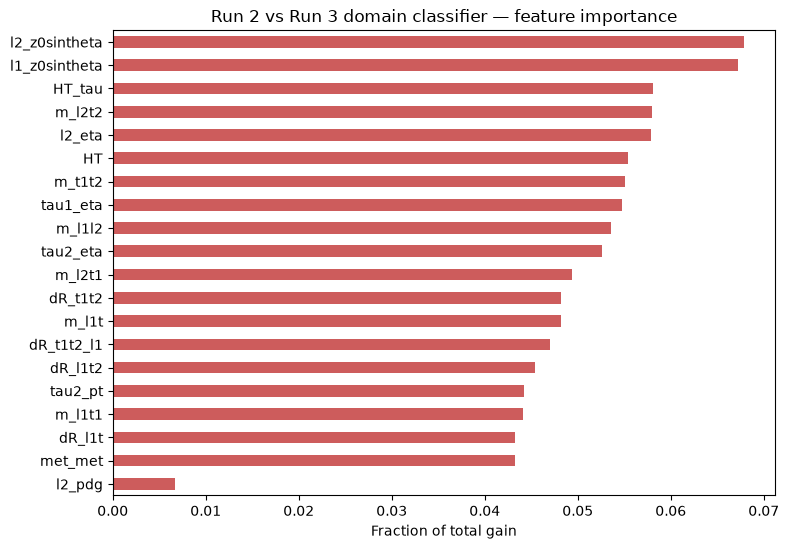

In [49]:
# ---- Final model (single split) + feature importance -------------------------
# The k-fold result above is the AUC estimate to quote - this single model is
# only to get one clean feature-importance / SHAP picture.
train_idx, test_idx = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y))

domain_final_params = dict(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)

if USE_GPU:
    domain_final_params["device"] = "cuda"

final_domain_model = xgb.XGBClassifier(**domain_final_params)
final_domain_model.fit(Xd[train_idx], yd[train_idx], sample_weight=to_device(w_fit[train_idx], USE_GPU), verbose=False)
final_domain_model.get_booster().feature_names = domain_features  # restore names lost by fitting on raw arrays

pred_test = final_domain_model.predict_proba(Xd[test_idx])[:, 1]
auc_test_domain = roc_auc_score(y[test_idx], pred_test, sample_weight=w_abs[test_idx])

print(f"Held-out AUC of this single interpretation model: {auc_test_domain:.4f} "
      f"(compare to the {N_FOLDS_DOMAIN}-fold mean above)")

imp_domain = get_importance(final_domain_model, domain_features)
plot_importance_bar(imp_domain, top_n=len(domain_features),
                     title="Run 2 vs Run 3 domain classifier — feature importance", color="indianred",
                     save_path=PLOTS_DIR_DOMAIN / "DomainShiftSignalImportance.png")


Saved plot -> run2_vs_run3_plots_2l2tau/DomainShiftSHAPSummary.png


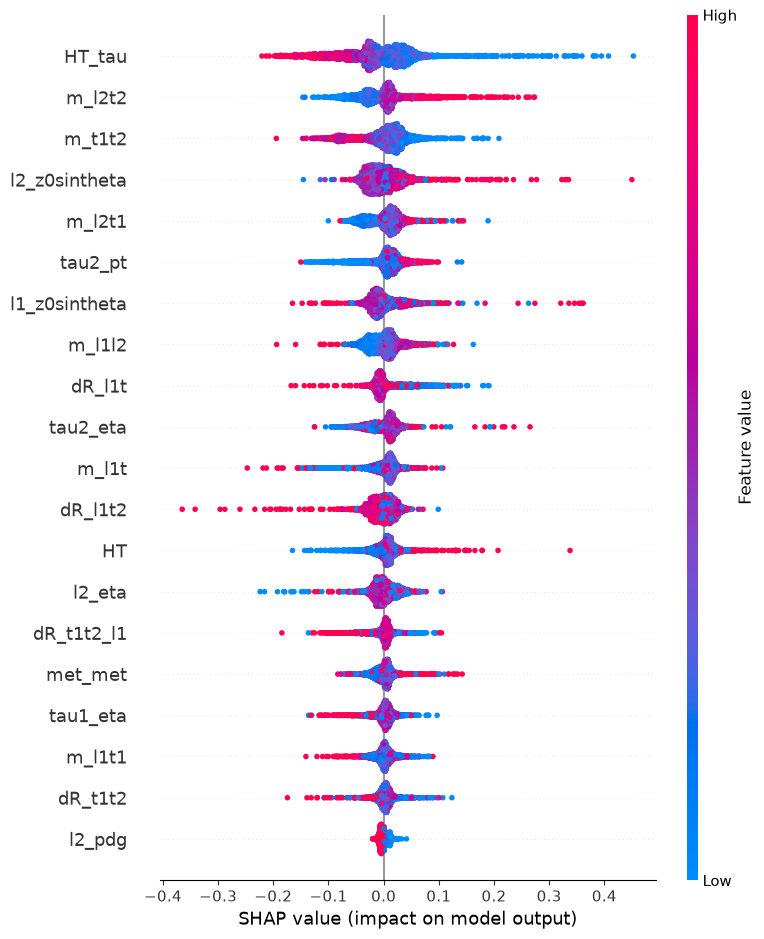

In [50]:
# ---- SHAP values --------------------
# Subsample for speed; TreeExplainer is exact for tree models, so a moderate
# sample is enough to see the global pattern.

try:
    import shap

    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
    X_shap = X.iloc[sample_idx]

    explainer = shap.TreeExplainer(final_domain_model)
    shap_values = explainer.shap_values(X_shap)
    shap.summary_plot(shap_values, X_shap, max_display=20, show=False)

    shap_save_path = PLOTS_DIR_DOMAIN / "DomainShiftSHAPSummary.png"
    shap_save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.gcf().savefig(shap_save_path, dpi=150, bbox_inches="tight")
    print(f"Saved plot -> {shap_save_path}")
    plt.show()
except ImportError:
    print("`shap` is not installed - skip this cell or `pip install shap` to see per-feature SHAP values.")


### All-processes scan

Repeat the same two-sample test independently for **every** simulated process
(not just the combined signal), to see whether Run2/Run3 differences are
localized to specific backgrounds or general across the production. Same
features, preselection and weight handling as above - just looped over every
ROOT file in `FILES` (Section 1).

Outputs: `run2_vs_run3_auc_summary_2l2tau.csv` (one row per process) and one
`run2_vs_run3_plots_2l2tau/<process>_importance.png` per process.


In [51]:
PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots_2l2tau")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)
RESULTS_CSV_DOMAIN = Path("run2_vs_run3_auc_summary_2l2tau.csv")


def run_two_sample_test(process_name, fname, features=domain_features, n_folds=3,
                         n_estimators=200, plots_dir=PLOTS_DIR_DOMAIN, use_gpu=USE_GPU):
    """Run2-vs-Run3 domain classifier for a single process (one ROOT file per
    run). Saves a feature-importance PNG and returns a summary dict. Lighter
    hyperparameters than the signal-only test above since this runs once per
    process - it's a scan, not the final result. No early stopping here
    either, for the same leakage reasons as the k-fold loop above.
    """
    frames = []
    for run_label, base_dir in [(0, BASE_DIR_R2), (1, BASE_DIR_R3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)

    # Sentinel -> NaN only (no constant-feature dropping - every process must
    # keep the exact same feature set so results stay comparable).
    for feat in features:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())

    X_proc = data[features]
    y_proc = data["run_label"].to_numpy()
    w_raw_proc = data[WEIGHT_BRANCH].to_numpy()
    w_abs_proc = np.abs(w_raw_proc)

    sum_w_r2 = w_raw_proc[y_proc == 0].sum()
    sum_w_r3 = w_raw_proc[y_proc == 1].sum()
    neg_frac_r2 = (w_raw_proc[y_proc == 0] < 0).mean() if n_r2 else np.nan
    neg_frac_r3 = (w_raw_proc[y_proc == 1] < 0).mean() if n_r3 else np.nan

    w_fit_proc = w_abs_proc.copy()
    sum_abs_r2, sum_abs_r3 = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()
    if sum_abs_r2 > 0 and sum_abs_r3 > 0:
        w_fit_proc[y_proc == 1] *= sum_abs_r2 / sum_abs_r3
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    Xd_proc = to_device(X_proc, use_gpu)
    yd_proc = to_device(y_proc, use_gpu)

    def make_params():
        params = dict(
            n_estimators=n_estimators, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
        )
        if use_gpu:
            params["device"] = "cuda"
        return params

    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    oof_pred_proc = np.full(len(y_proc), np.nan)

    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fold_model = xgb.XGBClassifier(**make_params())
            fold_model.fit(Xd_proc[idx_tr], yd_proc[idx_tr],
                            sample_weight=to_device(w_fit_proc[idx_tr], use_gpu), verbose=False)
            pred = fold_model.predict_proba(Xd_proc[idx_te])[:, 1]
            oof_pred_proc[idx_te] = pred
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc = float(fold_aucs.std()) if len(fold_aucs) else np.nan

    # Bootstrap CI on the OOF predictions (see Section 6's signal-only test) -
    # every event above got exactly one out-of-fold prediction when n_splits
    # >= 2, so this is a clean, per-process honest error bar for the Section 7
    # forest plot, instead of treating the 2-3 fold AUCs as a standard error.
    if n_splits >= 2:
        ci_lo, ci_hi, _ = bootstrap_weighted_auc_ci(y_proc, oof_pred_proc, w_abs_proc, n_boot=1000)
    else:
        ci_lo = ci_hi = np.nan

    final = xgb.XGBClassifier(**make_params())
    final.fit(Xd_proc, yd_proc, sample_weight=to_device(w_fit_proc, use_gpu), verbose=False)
    final.get_booster().feature_names = features
    imp_proc = get_importance(final, features)

    fig, ax = plt.subplots(figsize=(8, 8))
    imp_proc["gain_frac"][::-1].plot.barh(ax=ax, color="teal")
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(f"Run 2 vs Run 3 — {process_name} — feature importance")
    plt.tight_layout()
    fig.savefig(plots_dir / f"{process_name}_importance.png", dpi=150)
    plt.close(fig)

    # A suspiciously high AUC dominated by one variable can be an artifact of
    # that variable's NaN *fraction* differing between runs (not its value) -
    # track that here so it can be sanity-checked before trusting the result.

    top_feature = imp_proc.index[0] if len(imp_proc) else None
    if top_feature is not None:
        nan_frac_r2 = data.loc[data.run_label == 0, top_feature].isna().mean()
        nan_frac_r3 = data.loc[data.run_label == 1, top_feature].isna().mean()
    else:
        nan_frac_r2 = nan_frac_r3 = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds) | "
          f"top feature = {top_feature} (NaN frac Run2={nan_frac_r2:.1%}, Run3={nan_frac_r3:.1%})")

    return {
        "process": process_name, "n_run2": n_r2, "n_run3": n_r3,
        "sum_weights_run2": sum_w_r2, "sum_weights_run3": sum_w_r3,
        "neg_weight_frac_run2": neg_frac_r2, "neg_weight_frac_run3": neg_frac_r3,
        "n_folds": n_splits, "mean_auc": mean_auc, "std_auc": std_auc,
        "ci_lo": ci_lo, "ci_hi": ci_hi,
        "top_feature": top_feature,
        "top_feature_gain_frac": imp_proc["gain_frac"].iloc[0] if len(imp_proc) else np.nan,
        "top_feature_nan_frac_run2": nan_frac_r2, "top_feature_nan_frac_run3": nan_frac_r3,
    }


In [52]:
# ---- Run the scan over every process and export the summary ----------------
results = [run_two_sample_test(proc, fname) for proc, (fname, _label) in FILES.items()]

results_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_CSV_DOMAIN, index=False)

print(f"\nSaved AUC summary ({len(results_df)} processes) -> {RESULTS_CSV_DOMAIN}")
print(f"Saved {len(FILES)} feature-importance PNGs -> {PLOTS_DIR_DOMAIN}/")
results_df


signal_ggF  : Run2 =   31959 | Run3 =   96909 | weighted AUC = 0.5174 ± 0.0010 (3 folds) | top feature = HT_tau (NaN frac Run2=0.0%, Run3=0.0%)
signal_VBF  : Run2 =    5598 | Run3 =    3439 | weighted AUC = 0.4865 ± 0.0047 (3 folds) | top feature = l1_z0sintheta (NaN frac Run2=0.0%, Run3=0.0%)
Diboson     : Run2 =   36877 | Run3 =   82336 | weighted AUC = 0.5463 ± 0.0024 (3 folds) | top feature = HT (NaN frac Run2=0.0%, Run3=0.0%)
Zjets       : Run2 =    7746 | Run3 =   12919 | weighted AUC = 0.5303 ± 0.0195 (3 folds) | top feature = HT (NaN frac Run2=0.0%, Run3=0.0%)
Wjets       : Run2 =      67 | Run3 =      51 | weighted AUC = 0.3503 ± 0.0943 (3 folds) | top feature = dR_l1t2 (NaN frac Run2=0.0%, Run3=0.0%)
ttbar       : Run2 =     331 | Run3 =    3276 | weighted AUC = 0.5047 ± 0.0116 (3 folds) | top feature = l1_z0sintheta (NaN frac Run2=0.0%, Run3=0.0%)
tops        : Run2 =    3832 | Run3 =   11065 | weighted AUC = 0.4732 ± 0.0622 (3 folds) | top feature = m_t1t2 (NaN frac Run2=0.

,process,n_run2,n_run3,sum_weights_run2,sum_weights_run3,neg_weight_frac_run2,neg_weight_frac_run3,n_folds,mean_auc,std_auc,ci_lo,ci_hi,top_feature,top_feature_gain_frac,top_feature_nan_frac_run2,top_feature_nan_frac_run3
0,SingleH,2946,3240,"3,287.662","20,399.010",0.004,0.005,3,0.653,0.014,0.605,0.702,m_l1l2,0.142,0.000,0.000
1,VVV,3593,13941,56.099,"28,662.676",0.003,0.010,3,0.615,0.017,0.592,0.636,HT_tau,0.147,0.000,0.000
2,Vgamma,2019,2366,"3,085,372,928.000","4,357,021,184.000",0.078,0.081,3,0.582,0.028,0.538,0.620,l1_z0sintheta,0.066,0.000,0.000
3,Diboson,36877,82336,"1,200,979,328.000","2,756,951,552.000",0.089,0.091,3,0.546,0.002,0.538,0.554,HT,0.089,0.000,0.000
4,Zjets,7746,12919,"23,516,846,080.000","56,472,010,752.000",0.158,0.155,3,0.530,0.019,0.507,0.554,HT,0.099,0.000,0.000
5,signal_ggF,31959,96909,864.790,"2,629.576",0.061,0.061,3,0.517,0.001,0.514,0.521,HT_tau,0.068,0.000,0.000
6,ttbar,331,3276,"244,279.250","312,398.281",0.003,0.003,3,0.505,0.012,0.467,0.540,l1_z0sintheta,0.069,0.000,0.000
7,signal_VBF,5598,3439,7.138,4.426,0.001,0.002,3,0.487,0.005,0.473,0.499,l1_z0sintheta,0.078,0.000,0.000
8,tops,3832,11065,"150,095.094","633,628.188",0.311,0.287,3,0.473,0.062,0.408,0.554,m_t1t2,0.074,0.000,0.000
9,Wjets,67,51,"1,189,386,240.000","174,232,768.000",0.104,0.157,3,0.350,0.094,0.127,0.514,dR_l1t2,0.163,0.000,0.000


## 7. Summary


Weighted AUC by track and feature-selection stage (baseline/pruned = fold-0 preview only; tuned (OOF) = every event scored by a fold model that never trained on it, pooled across all 5 folds):
          baseline (fold-0 preview)  pruned (fold-0 preview)  tuned (OOF)
track                                                                    
Run 2                        0.9709                   0.9675       0.9666
Run 3                        0.9705                   0.9640       0.9707
Combined                     0.9701                   0.9656       0.9713
Saved plot -> PPSSP_2026/2l2tau/summary_plots/AUCSummaryByTrack.png


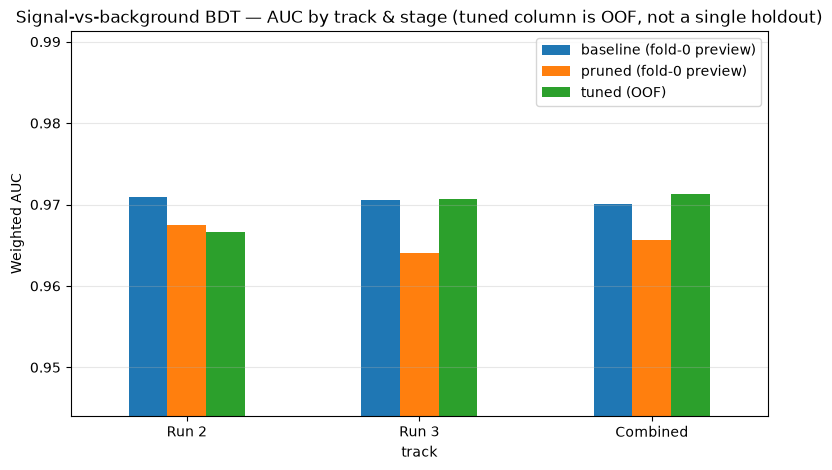


Run2 vs Run3 domain-shift check (signal, combined-track features): mean weighted AUC = 0.5171 ± 0.0052
(closer to 0.5 = the two campaigns agree better on the features that matter)

Per-process domain-shift AUCs (highest first):
   process  mean_auc  std_auc   top_feature
   SingleH     0.653    0.014        m_l1l2
       VVV     0.615    0.017        HT_tau
    Vgamma     0.582    0.028 l1_z0sintheta
   Diboson     0.546    0.002            HT
     Zjets     0.530    0.019            HT
signal_ggF     0.517    0.001        HT_tau
     ttbar     0.505    0.012 l1_z0sintheta
signal_VBF     0.487    0.005 l1_z0sintheta
      tops     0.473    0.062        m_t1t2
     Wjets     0.350    0.094       dR_l1t2


In [53]:
# ---- Consolidated AUC comparison across all three tracks --------------------
PLOTS_DIR_SUMMARY = Path("PPSSP_2026/2l2tau/summary_plots")
PLOTS_DIR_SUMMARY.mkdir(parents=True, exist_ok=True)

summary_rows = [
    {"track": "Run 2",    "baseline (fold-0 preview)": auc_val_r2,   "pruned (fold-0 preview)": auc_val_r2_pruned,   "tuned (OOF)": oof_auc_r2},
    {"track": "Run 3",    "baseline (fold-0 preview)": auc_val_r3,   "pruned (fold-0 preview)": auc_val_r3_pruned,   "tuned (OOF)": oof_auc_r3},
    {"track": "Combined", "baseline (fold-0 preview)": auc_val_comb, "pruned (fold-0 preview)": auc_val_comb_pruned, "tuned (OOF)": oof_auc_comb},
]
summary_df = pd.DataFrame(summary_rows).set_index("track")
print("Weighted AUC by track and feature-selection stage (baseline/pruned = fold-0 preview only; "
      "tuned (OOF) = every event scored by a fold model that never trained on it, pooled across all 5 folds):")
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(figsize=(9, 5))
summary_df.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Weighted AUC")
ax.set_title("Signal-vs-background BDT — AUC by track & stage (tuned column is OOF, not a single holdout)")
ax.set_ylim(summary_df.values.min() - 0.02, summary_df.values.max() + 0.02)
ax.grid(axis="y", alpha=0.3)

summary_plot_path = PLOTS_DIR_SUMMARY / "AUCSummaryByTrack.png"

fig.savefig(summary_plot_path, dpi=150)
print(f"Saved plot -> {summary_plot_path}")
plt.show()

print(f"\nRun2 vs Run3 domain-shift check (signal, combined-track features): "
      f"mean weighted AUC = {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(closer to 0.5 = the two campaigns agree better on the features that matter)")
print("\nPer-process domain-shift AUCs (highest first):")
print(results_df[["process", "mean_auc", "std_auc", "top_feature"]].to_string(index=False))


### Domain-shift check — forest plot (0.5 is the *good* result, not 0)

Unlike everywhere else in this notebook where AUC = 1 is "good", here **AUC =
0.5 is the good result** (Run 2 and Run 3 are indistinguishable in the
features that matter) and 1.0 is the bad one. A bar chart from 0 hides
exactly the thing that matters: near 0.5 every bar looks identical, and the
real signal is a sliver at the tip. Below is a **forest / caterpillar plot**
instead — one row per process, a lollipop stem from the 0.5 null out to the
observed AUC, a bootstrap 95% CI, sorted by AUC, x-axis zoomed to ~[0.49, 0.56]
instead of [0, 1].

**The noise floor differs across processes because N varies substantially**
across the ten processes, so a single flat reference band would under-warn
for the large samples and over-warn for the small ones. Each point is
instead colored by its own significance
$z = (\text{AUC} - 0.5) / \text{SE}$, where SE comes from a **bootstrap CI
over out-of-fold predictions** (resample events, recompute the *weighted*
AUC) rather than the raw-count analytic formula $\sigma \approx 1/\sqrt{6N}$
— the physical event weights (partly from negative Sherpa weights, see
Section 1) reduce the effective statistics below what raw counts would
suggest, so the bootstrap is the honest error bar here, not the analytic one.
With ~10 processes tested at once, roughly one >2.6σ hit is expected by
chance alone, so the flag threshold below is raised to 3.5σ.

**Signal handling:** `signal_ggF` and `signal_VBF` also each got their own
individual Run2-vs-Run3 test in the Section 6 scan (same as every
background), but those two rows are deliberately **excluded** from this plot
- Section 6 already ran a dedicated, higher-statistics test that pools both
signal files together (more events -> a tighter, more trustworthy CI), and
that single **signal (ggF+VBF)** point is what's shown here, as its own
diamond marker. A shift in this combined signal point is the one that
actually threatens a model trained on the Run2+Run3 combined sample, so it
matters more than any single background process. Any background flagged
amber should be followed up with its
`run2_vs_run3_plots_2l2tau/<process>_importance.png` (Section 6) to see
*which* variable is driving the shift.


Saved plot -> PPSSP_2026/2l2tau/summary_plots/DomainShiftPoolingCheck.png


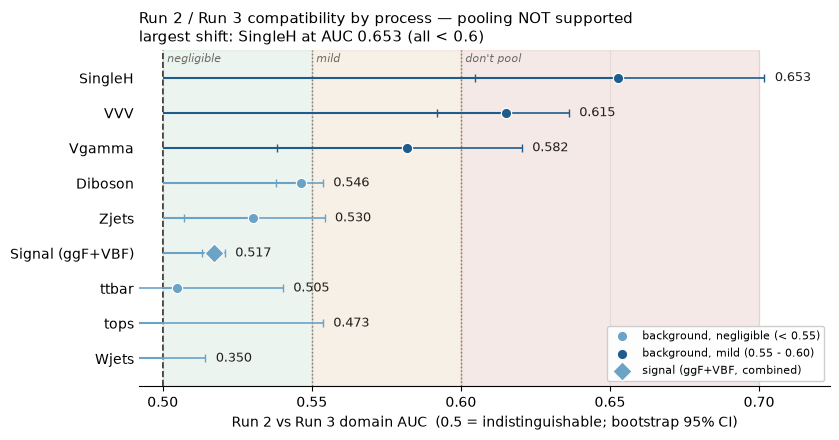


Max domain AUC = 0.653  (tolerance 0.6)
Verdict: pooling NOT supported

Mild shift, worth monitoring (AUC >= 0.55):
process  mean_auc
 Vgamma     0.582
    VVV     0.615
SingleH     0.653


In [54]:
# ---- Domain-shift plot: can Run 2 and Run 3 be pooled? ----------------------
# Reframed around the decision actually being made. The question is not "is
# there a detectable shift" - at these sample sizes there always is, and the
# z-scores just measure how much simulation we generated. The question is
# whether the shift is SMALL ENOUGH to train on the combined sample, which is
# a question about the size of the AUC. So AUC is what the plot encodes:
# position against labelled tolerance bands, value printed on every row.

AUC_NEGLIGIBLE = 0.55   # below: periods effectively interchangeable
AUC_TOLERABLE  = 0.60   # above: don't pool without reweighting / domain adaptation

is_signal_process = results_df["process"].map(lambda p: FILES.get(p, (None, 0))[1] == 1)
bkg_df = results_df.loc[~is_signal_process].dropna(subset=["ci_lo", "ci_hi"]).copy()

signal_row = pd.DataFrame([{
    "process": "Signal (ggF+VBF)", "mean_auc": fold_aucs.mean(),
    "ci_lo": ci_lo_signal, "ci_hi": ci_hi_signal,
}])

# Ascending sort + upward y-axis puts the largest shift at the top, where the
# eye lands first - those are the rows that decide the answer.
plot_df = pd.concat(
    [bkg_df[["process", "mean_auc", "ci_lo", "ci_hi"]], signal_row], ignore_index=True
).sort_values("mean_auc").reset_index(drop=True)

y_pos = np.arange(len(plot_df))
mean_auc = plot_df["mean_auc"].to_numpy()
ci_lo = plot_df["ci_lo"].to_numpy()
ci_hi = plot_df["ci_hi"].to_numpy()
is_signal = (plot_df["process"] == "Signal (ggF+VBF)").to_numpy()
is_watch = mean_auc >= AUC_NEGLIGIBLE

INK, MUTED = "#22201d", "#6b6862"
C_LOW, C_WATCH = "#6BA3C7", "#1F5C8B"   # one hue, two steps - redundant with position

fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.46 * len(plot_df))))

# Tolerance bands carry the verdict; alpha kept low so the marks stay dominant.
ax.axvspan(0.50, AUC_NEGLIGIBLE, color="#4C9A6A", alpha=0.10, zorder=0)
ax.axvspan(AUC_NEGLIGIBLE, AUC_TOLERABLE, color="#BA7517", alpha=0.10, zorder=0)
ax.axvspan(AUC_TOLERABLE, 0.70, color="#A62B1F", alpha=0.10, zorder=0)
for x, lab in [(AUC_NEGLIGIBLE, f"{AUC_NEGLIGIBLE:g}"), (AUC_TOLERABLE, f"{AUC_TOLERABLE:g}")]:
    ax.axvline(x, color=MUTED, lw=1, ls=":", zorder=1)
ax.axvline(0.5, color=INK, lw=1.2, ls="--", zorder=1)

for label, colour, mask, marker, size in [
    ("background, negligible (< 0.55)", C_LOW,   ~is_watch & ~is_signal, "o", 55),
    ("background, mild (0.55 - 0.60)",  C_WATCH,  is_watch & ~is_signal, "o", 55),
    ("signal (ggF+VBF, combined)",      C_WATCH if is_watch[is_signal][0] else C_LOW,
                                                              is_signal, "D", 95),
]:
    if not mask.any():
        continue
    ax.hlines(y_pos[mask], 0.5, mean_auc[mask], color=colour, lw=1.5, zorder=2)
    ax.errorbar(mean_auc[mask], y_pos[mask],
                xerr=[mean_auc[mask] - ci_lo[mask], ci_hi[mask] - mean_auc[mask]],
                fmt="none", ecolor=colour, capsize=3, lw=1.2, zorder=2)
    ax.scatter(mean_auc[mask], y_pos[mask], color=colour, s=size, marker=marker,
               zorder=3, label=label, edgecolor="white", linewidth=0.8)

# Direct-label every row with the number being read - no legend lookup needed.
for yi in y_pos:
    ax.text(ci_hi[yi] + 0.0035, yi, f"{mean_auc[yi]:.3f}", va="center",
            fontsize=9, color=INK)

x_max = max(AUC_TOLERABLE + 0.012, ci_hi.max() + 0.022)
ax.set(yticks=y_pos, yticklabels=plot_df["process"], xlim=(0.492, x_max),
    ylim=(-0.8, len(plot_df) - 0.2),
    xlabel="Run 2 vs Run 3 domain AUC  (0.5 = indistinguishable; bootstrap 95% CI)")

ax.text(0.5015, len(plot_df) - 0.55, "negligible", fontsize=8, color=MUTED, style="italic")
ax.text(AUC_NEGLIGIBLE + 0.0015, len(plot_df) - 0.55, "mild", fontsize=8, color=MUTED, style="italic")
if x_max > AUC_TOLERABLE:
    ax.text(AUC_TOLERABLE + 0.0015, len(plot_df) - 0.55, "don't pool", fontsize=8,
            color=MUTED, style="italic")

worst = plot_df.iloc[-1]
verdict = ("supports pooling" if mean_auc.max() < AUC_TOLERABLE else "pooling NOT supported")
ax.set_title(f"Run 2 / Run 3 compatibility by process — {verdict}\n"
            f"largest shift: {worst['process']} at AUC {worst['mean_auc']:.3f} "
            f"(all < {AUC_TOLERABLE:g})", fontsize=11, loc="left")

ax.grid(axis="x", alpha=0.25, zorder=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", fontsize=8, frameon=True, framealpha=0.95)
plt.tight_layout()

plot_path = PLOTS_DIR_SUMMARY / "DomainShiftPoolingCheck.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot -> {plot_path}")
plt.show()

watch = plot_df.loc[plot_df["mean_auc"] >= AUC_NEGLIGIBLE, ["process", "mean_auc"]]
print(f"\nMax domain AUC = {mean_auc.max():.3f}  (tolerance {AUC_TOLERABLE:g})")
print(f"Verdict: {verdict}")
print(f"\nMild shift, worth monitoring (AUC >= {AUC_NEGLIGIBLE:g}):")
print(watch.to_string(index=False) if len(watch) else "  none")


### Files written to disk

| Path | Contents |
| --- | --- |
| `PPSSP_2026/2l2tau/run2/final_model_run2.json` | Run-2 tuned XGBoost model |
| `PPSSP_2026/2l2tau/run2/optuna_features_run2.json` | Run-2 tuned feature list |
| `PPSSP_2026/2l2tau/run2/splits/{train,val,test}.root` | Run-2 80/10/10 train/val/test split |
| `PPSSP_2026/2l2tau/run2/plots/*.png` | Run-2 diagnostic plots (importance, correlation, Optuna) |
| `PPSSP_2026/2l2tau/run3/final_model_run3.json` | Run-3 tuned XGBoost model |
| `PPSSP_2026/2l2tau/run3/optuna_features_run3.json` | Run-3 tuned feature list |
| `PPSSP_2026/2l2tau/run3/splits/{train,val,test}.root` | Run-3 80/10/10 train/val/test split |
| `PPSSP_2026/2l2tau/run3/plots/*.png` | Run-3 diagnostic plots (importance, correlation, Optuna) |
| `PPSSP_2026/2l2tau/combined/final_model_combined.json` | Combined tuned XGBoost model |
| `PPSSP_2026/2l2tau/combined/optuna_features_combined.json` | Combined tuned feature list |
| `PPSSP_2026/2l2tau/combined/splits/{train,val,test}.root` | Combined 80/10/10 train/val/test split |
| `PPSSP_2026/2l2tau/combined/plots/*.png` | Combined diagnostic plots (importance, correlation, Optuna, model comparison) |
| `run2_vs_run3_auc_summary_2l2tau.csv` | Per-process Run2/Run3 domain-shift AUC + bootstrap CI |
| `run2_vs_run3_plots_2l2tau/*.png` | Signal domain-shift importance/SHAP plots + per-process feature-importance plots |
| `PPSSP_2026/2l2tau/summary_plots/AUCSummaryByTrack.png` | Consolidated AUC comparison across tracks, including the once-only held-out test AUC per track |
| `PPSSP_2026/2l2tau/summary_plots/DomainShiftForestPlot.png` | Domain-shift forest plot (0.5 = no shift, all processes + signal) |
| `PPSSP_2026/2l2tau/summary_plots/DomainShiftPoolingCheck.png` | Domain-shift pooling-decision plot (AUC vs tolerance bands) |

**Held-out test policy:** each track's `X_test_*`/`y_test_*`/`w_test_*` partition
(10% of the sample) is set aside by `make_3way_split` before any correlation
pruning, Optuna tuning or early stopping, and is read exactly once - in the
"Held-Out Test Evaluation" cell right after each track's final model is
persisted - to report a genuinely blind AUC alongside the validation number
used for all model/feature selection.


In [55]:
# ---- Export standardized AUC summary for cross-notebook comparison ---------
# Written for ModelComparison.ipynb to load - one row per track, channel and
# model, so it can be combined with the MLP/DNN notebooks' own exports
# without needing to re-run anything. "val_auc"/"test_auc" both now hold the
# OOF weighted AUC (every event scored by a fold model that never trained on
# it) - there is no separate val/test distinction anymore under the k-fold
# refactor, but the column names are kept for ModelComparison.ipynb's
# existing loading code until it is updated to the new OOF-based schema.
model_summary_rows = [
    {"channel": "2l2tau", "model": "xgboost", "track": "Run 2",
      "val_auc": oof_auc_r2, "test_auc": oof_auc_r2},
    {"channel": "2l2tau", "model": "xgboost", "track": "Run 3",
      "val_auc": oof_auc_r3, "test_auc": oof_auc_r3},
    {"channel": "2l2tau", "model": "xgboost", "track": "Combined",
      "val_auc": oof_auc_comb, "test_auc": oof_auc_comb},
]
model_summary_df = pd.DataFrame(model_summary_rows)
model_summary_path = PLOTS_DIR_SUMMARY / "model_summary_xgboost.csv"
model_summary_df.to_csv(model_summary_path, index=False)
print(f"Saved model comparison summary -> {model_summary_path}")
model_summary_df


Saved model comparison summary -> PPSSP_2026/2l2tau/summary_plots/model_summary_xgboost.csv


,channel,model,track,val_auc,test_auc
0,2l2tau,xgboost,Run 2,0.967,0.967
1,2l2tau,xgboost,Run 3,0.971,0.971
2,2l2tau,xgboost,Combined,0.971,0.971
